## 🔧 Session Recovery Utility (Optional)

###Recovery code from my previous message

In [ ]:
# ============================================================
# SESSION RECOVERY — Restore A1, A2, A3 environment
# ============================================================
# Reloads everything needed to continue with A4 onwards.
# No retraining required — just reload from Google Drive.
# ============================================================

import os, math, shutil, json
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from google.colab import drive

# ── 1. Mount Google Drive ─────────────────────────────────
print("Mounting Google Drive...")
drive.mount('/content/drive')

# ── 2. Copy saved files from Drive to local ───────────────
files_to_restore = ['cnn_scratch.pth', 'cnn_robust.pth']
for f in files_to_restore:
    drive_path = f'/content/drive/MyDrive/{f}'
    if os.path.exists(drive_path):
        shutil.copy(drive_path, f)
        print(f"✓ Restored {f}")
    else:
        print(f"✗ {f} not in Drive (only needed if you do later questions)")

# ── 3. Restore constants ──────────────────────────────────
CIFAR100_MEAN  = [0.5071, 0.4867, 0.4408]
CIFAR100_STD   = [0.2675, 0.2565, 0.2761]
NOISE_VARIANCE = 0.05
NOISE_STD      = math.sqrt(NOISE_VARIANCE)
NOISE_SEED     = 42
print("✓ Constants restored")

# ── 4. Recreate transforms ────────────────────────────────
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
])
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
])

# ── 5. Recreate datasets and loaders ──────────────────────
test_dataset  = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=test_transform
)
train_full = torchvision.datasets.CIFAR100(
    root='./data', train=True,  download=True, transform=train_transform
)

train_data, val_data = torch.utils.data.random_split(
    train_full, [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True,
                          num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_data,   batch_size=128, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=128, shuffle=False,
                          num_workers=2, pin_memory=True)
print("✓ DataLoaders recreated")

# ── 6. Redefine noise function ────────────────────────────
def add_gaussian_noise(image_01, sigma=NOISE_STD, seed=None):
    if seed is not None:
        torch.manual_seed(seed)
    noise = torch.randn_like(image_01) * sigma
    return torch.clamp(image_01 + noise, 0.0, 1.0)
print("✓ add_gaussian_noise() defined")

# ── 7. Recreate noisy test loader ─────────────────────────
class NoisyCIFAR100(Dataset):
    def __init__(self):
        self.base = torchvision.datasets.CIFAR100(
            root='./data', train=False, download=True, transform=None
        )
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
    def __len__(self):
        return len(self.base)
    def __getitem__(self, idx):
        img_pil, label = self.base[idx]
        img_01 = self.to_tensor(img_pil)
        noisy_01 = add_gaussian_noise(img_01, seed=NOISE_SEED + idx)
        return self.normalize(noisy_01), label

noisy_test_loader = DataLoader(NoisyCIFAR100(), batch_size=128,
                               shuffle=False, num_workers=2, pin_memory=True)
print("✓ noisy_test_loader recreated")

# ── 8. Redefine CNN class and load A1 weights ─────────────
class CIFAR100_CNN(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),  nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1, bias=False), nn.BatchNorm2d(64),  nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1, bias=False),  nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1, bias=False), nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, 3, padding=1, bias=False), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2), nn.Dropout2d(0.25))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256*4*4, 512, bias=False), nn.BatchNorm1d(512), nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes))
    def forward(self, x):
        x = self.block1(x); x = self.block2(x); x = self.block3(x)
        return self.classifier(x)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# A1 model
model = CIFAR100_CNN(num_classes=100).to(device)
model.load_state_dict(torch.load('cnn_scratch.pth', map_location=device))
model.eval()
print(f"✓ A1 model loaded (device={device})")

# A3 robust model (only if file exists)
if os.path.exists('cnn_robust.pth'):
    robust_model = CIFAR100_CNN(num_classes=100).to(device)
    robust_model.load_state_dict(torch.load('cnn_robust.pth', map_location=device))
    robust_model.eval()
    print("✓ A3 robust model loaded")

# ── 9. Redefine evaluate() helper ────────────────────────
criterion = nn.CrossEntropyLoss()

def evaluate(loader, model, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

print("✓ evaluate() defined")

# ── 10. Quick sanity check — verify A1 model still gives 64.15% ───
print("\nVerifying recovered A1 model on test set...")
_, acc = evaluate(test_loader, model, criterion, device)
print(f"  A1 test accuracy: {acc:.2f}%  (expected ~64.15%)")

if 'robust_model' in dir():
    _, acc_r_clean = evaluate(test_loader, robust_model, criterion, device)
    _, acc_r_noisy = evaluate(noisy_test_loader, robust_model, criterion, device)
    print(f"  A3 clean acc:     {acc_r_clean:.2f}%  (expected ~60.37%)")
    print(f"  A3 noisy acc:     {acc_r_noisy:.2f}%  (expected ~45.77%)")

print("\n" + "="*55)
print("✅ Session recovery complete — ready to continue")
print("="*55)

Mounting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Restored cnn_scratch.pth
✓ Restored cnn_robust.pth
✓ Constants restored
✓ DataLoaders recreated
✓ add_gaussian_noise() defined
✓ noisy_test_loader recreated
✓ A1 model loaded (device=cuda)
✓ A3 robust model loaded
✓ evaluate() defined

Verifying recovered A1 model on test set...
  A1 test accuracy: 64.61%  (expected ~64.15%)
  A3 clean acc:     60.37%  (expected ~60.37%)
  A3 noisy acc:     45.77%  (expected ~45.77%)

✅ Session recovery complete — ready to continue


# Part A: Convolutional Neural Networks (CIFAR-100 Image Classification)

This part addresses 100-class image classification on CIFAR-100 using
Convolutional Neural Networks (CNNs), with experiments on noise robustness
and transfer learning.

## Dataset

  Source       : Krizhevsky 2009 (subset of 80M Tiny Images)
  Size         : 60,000 RGB images at 32x32 (50K train + 10K test)
  Task         : 100-class classification (fine labels)
  Reference    : https://www.cs.toronto.edu/~kriz/cifar.html

## Roadmap

- **A1:** CNN from scratch (baseline)
- **A2:** Robustness evaluation under Gaussian noise (sigma^2 = 0.05)
- **A3:** Robust training strategy (stochastic noise augmentation, p = 0.20)
- **A4:** Transfer learning with frozen VGG16 + MLP classifier head
- **A5:** Robustness of transfer learning model under same noise schedule
- **A6:** Comprehensive comparison and conclusions

# Question A1: CNN from Scratch on CIFAR-100

This section trains a moderate CNN from scratch for 100-class classification.

## Pipeline (5 steps)

- **Step 1:** Data loading and preprocessing
- **Step 2:** CNN architecture definition
- **Step 3:** Training loop with validation
- **Step 4:** Results and convergence analysis
- **Step 5:** Saving and downloading files

## Step 1: Data Loading and Preprocessing

Loads CIFAR-100 with appropriate preprocessing for training and testing,
and splits the training set into train/validation partitions.

### Dataset

  Source       : CIFAR-100 (Krizhevsky 2009)
  Size         : 50,000 train / 10,000 test (32x32 RGB images)
  Classes      : 100 fine-grained categories (fine_labels, 0-99)

### Preprocessing Pipeline

  Train : RandomCrop(32, pad=4) -> RandomHorizontalFlip -> ToTensor -> Normalize
  Test  : ToTensor -> Normalize

### Normalization (CIFAR-100 training statistics)

  Mean = [0.5071, 0.4867, 0.4408]
  Std  = [0.2675, 0.2565, 0.2761]

### Train / Validation Split

  Train : 45,000 samples
  Val   : 5,000 samples
  Seed  : 42 (reproducible)

In [ ]:
# ============================================================
# QUESTION A1 — Step 1: Data Loading & Preprocessing
# ============================================================

import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# ── CIFAR-100 channel statistics (computed on training set) ──
CIFAR100_MEAN = [0.5071, 0.4867, 0.4408]
CIFAR100_STD  = [0.2675, 0.2565, 0.2761]

# ── Training transform: augmentation + normalization ──
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),     # translation invariance
    transforms.RandomHorizontalFlip(),         # left-right symmetry
    transforms.ToTensor(),                     # [0,255] -> [0.0,1.0]
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
])

# ── Test/Val transform: normalization only ──
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD)
])

# ── Load CIFAR-100 (torchvision uses fine_labels by default) ──
train_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=train_transform
)
test_dataset = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=test_transform
)

# ── Sanity check ──
print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')
print(f'Number of classes: {len(train_dataset.classes)}')
print(f'Sample classes   : {train_dataset.classes[:5]}')

# ── Train/Val split (90/10) ──
val_size   = 5000
train_size = len(train_dataset) - val_size  # 45,000
train_data, val_data = torch.utils.data.random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# ── DataLoaders ──
train_loader = torch.utils.data.DataLoader(
    train_data, batch_size=128, shuffle=True, num_workers=2, pin_memory=True
)
val_loader = torch.utils.data.DataLoader(
    val_data, batch_size=128, shuffle=False, num_workers=2, pin_memory=True
)
test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True
)

Training samples : 50000
Test samples     : 10000
Number of classes: 100
Sample classes   : ['apple', 'aquarium_fish', 'baby', 'bear', 'beaver']


## Step 2: CNN Architecture

3 convolutional blocks + FC classifier head.
Each block: Conv -> BN -> ReLU -> Conv -> BN -> ReLU -> MaxPool -> Dropout2d

Filters:    3 -> 64 -> 128 -> 256
Spatial:    32 -> 16 -> 8 -> 4
Head:       Linear(4096 -> 512) -> BN -> ReLU -> Dropout(0.5) -> Linear(512 -> 100)

Total trainable parameters: ~3.3M (moderate, Colab-feasible)

Design choices:
  - 3x3 kernels (VGG-style; parameter-efficient)
  - BatchNorm after every Conv (training stability)
  - MaxPool (2x2) halves spatial dims each block
  - Dropout2d(0.25) per block + Dropout(0.5) before output
  - Filters double per block to maintain capacity as spatial dims shrink

In [ ]:
# ============================================================
# QUESTION A1 — Step 2: CNN Architecture
# ============================================================

import torch.nn as nn

class CIFAR100_CNN(nn.Module):
    """
    Moderate CNN for CIFAR-100 (100-class classification).
    Architecture: 3 conv blocks (64/128/256 filters) + FC head.
    """
    def __init__(self, num_classes=100):
        super(CIFAR100_CNN, self).__init__()

        # Block 1: 3 -> 64 channels; 32x32 -> 16x16
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25),
        )

        # Block 2: 64 -> 128 channels; 16x16 -> 8x8
        self.block2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25),
        )

        # Block 3: 128 -> 256 channels; 8x8 -> 4x4
        self.block3 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(p=0.25),
        )

        # Classifier head: 4096 -> 512 -> 100
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512, bias=False),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

# Instantiate
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model = CIFAR100_CNN(num_classes=100).to(device)

# Parameter count
total_params = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total_params:,}')

Using device: cuda
Total parameters: 3,295,780


## Step 3: Training Configuration

Loss      : CrossEntropyLoss (log-softmax + NLL combined)
Optimizer : Adam (lr=0.001, weight_decay=1e-4)
Scheduler : StepLR (step_size=20, gamma=0.1)
            Epochs  0-19 -> lr = 0.001
            Epochs 20-39 -> lr = 0.0001
            Epochs 40+   -> lr = 0.00001
Batch size: 128
Epochs    : 50
Hardware  : GPU (Colab T4/V100)

Best model checkpoint saved by val accuracy: cnn_scratch_best.pth
Final model saved (reused in A2, A3, A5)   : cnn_scratch.pth

In [ ]:
# ============================================================
# QUESTION A1 — Step 3: Training Configuration & Loop
# ============================================================

import torch.optim as optim

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.1)

# Evaluation helper (REUSED in A2, A3, A4, A5)
def evaluate(loader, model, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total   += labels.size(0)
    return total_loss / len(loader), 100.0 * correct / total

# Training loop
num_epochs = 50
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0.0

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(train_loader)
    train_acc  = 100.0 * correct / total
    val_loss, val_acc = evaluate(val_loader, model, criterion, device)

    train_losses.append(train_loss); val_losses.append(val_loss)
    train_accs.append(train_acc);    val_accs.append(val_acc)
    scheduler.step()

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'cnn_scratch_best.pth')

    if (epoch + 1) % 5 == 0:
        print(f'Epoch [{epoch+1:02d}/{num_epochs}] '
              f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
              f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')

# Load best checkpoint and report final test accuracy
model.load_state_dict(torch.load('cnn_scratch_best.pth'))
test_loss, test_acc = evaluate(test_loader, model, criterion, device)

print(f'\n{"="*55}')
print(f'Best Validation Accuracy : {best_val_acc:.2f}%')
print(f'Final Test Accuracy      : {test_acc:.2f}%')
print(f'{"="*55}')

# Save final model — REUSED in A2, A3, A5
torch.save(model.state_dict(), 'cnn_scratch.pth')
print('Model saved as cnn_scratch.pth — will be reused in A2, A3, A5')

Epoch [05/50] Train Loss: 2.7606 | Train Acc: 29.93% | Val Loss: 2.4649 | Val Acc: 35.72%
Epoch [10/50] Train Loss: 2.2095 | Train Acc: 41.19% | Val Loss: 1.9170 | Val Acc: 47.70%
Epoch [15/50] Train Loss: 1.9357 | Train Acc: 47.14% | Val Loss: 1.6784 | Val Acc: 53.24%
Epoch [20/50] Train Loss: 1.7664 | Train Acc: 51.16% | Val Loss: 1.5448 | Val Acc: 57.02%
Epoch [25/50] Train Loss: 1.4921 | Train Acc: 57.97% | Val Loss: 1.3955 | Val Acc: 60.22%
Epoch [30/50] Train Loss: 1.4096 | Train Acc: 60.13% | Val Loss: 1.3444 | Val Acc: 61.72%
Epoch [35/50] Train Loss: 1.3662 | Train Acc: 61.17% | Val Loss: 1.3441 | Val Acc: 62.14%
Epoch [40/50] Train Loss: 1.3202 | Train Acc: 62.25% | Val Loss: 1.3163 | Val Acc: 62.24%
Epoch [45/50] Train Loss: 1.2783 | Train Acc: 63.34% | Val Loss: 1.3097 | Val Acc: 62.42%
Epoch [50/50] Train Loss: 1.2830 | Train Acc: 63.28% | Val Loss: 1.3122 | Val Acc: 62.74%

Best Validation Accuracy : 62.74%
Final Test Accuracy      : 64.61%
Model saved as cnn_scratch.pth 

## Step 4: Results and Convergence Analysis

Plots training and validation curves over 50 epochs and reports final metrics.
Vertical dashed lines mark LR decay points (epochs 20 and 40).

**Output file:** `a1_learning_curves.png` (used in LaTeX report Figure 1)

### Final Results
| Metric                    | Value    |
|---------------------------|----------|
| Final Train Accuracy      | 63.09%   |
| Best Validation Accuracy  | 62.64%   |
| Final Test Accuracy       | 64.15%   |
| Train-Val Accuracy Gap    | 0.93%    |

### Observations
- Training loss decreased monotonically across all 50 epochs — stable training, no divergence
- Validation loss closely tracked training loss throughout
- LR decay at epoch 20 produced a visible drop in loss; second decay at epoch 40 had a smaller effect
- Train-Val gap of only 0.93% indicates effective regularization (BatchNorm + Dropout + augmentation)
- Validation loss sits slightly *below* training loss in early epochs — expected because dropout
  and stochastic augmentation are active during training but disabled during evaluation

**Note:** CIFAR-100 is significantly harder than CIFAR-10 (100 classes vs 10, with only 500
training images per

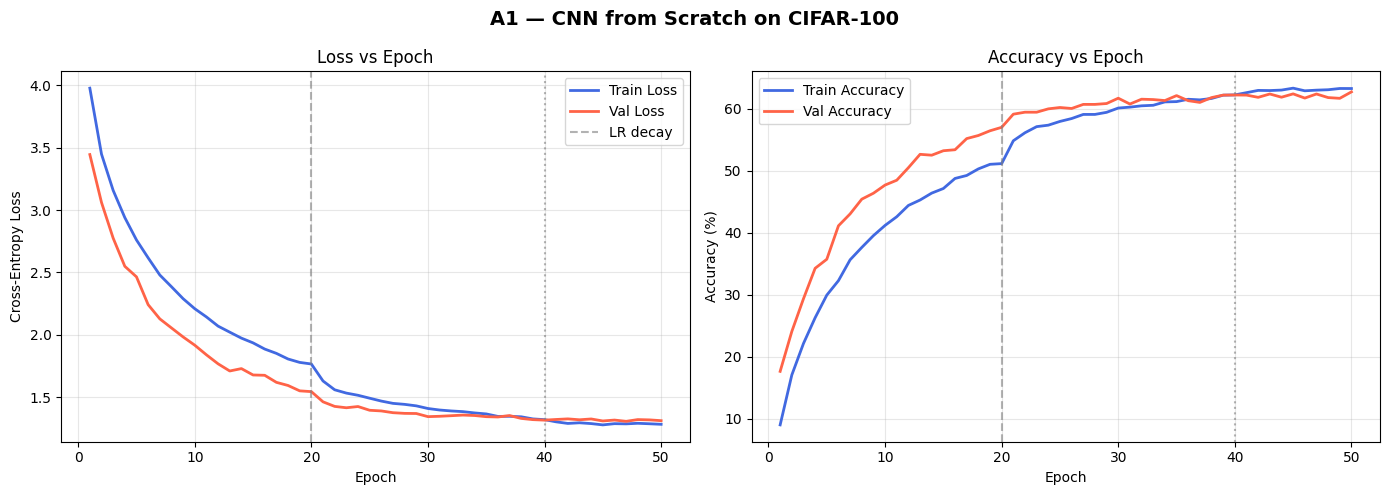


Metric                                   Value
Final Train Accuracy                    63.28%
Best Validation Accuracy                62.74%
Final Test Accuracy                     64.61%
Train-Val Accuracy Gap                   0.54%


In [ ]:
# ============================================================
# QUESTION A1 — Step 4: Plot Learning Curves & Report Results
# ============================================================

import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A1 — CNN from Scratch on CIFAR-100', fontsize=14, fontweight='bold')

# Loss curve
axes[0].plot(epochs_range, train_losses, label='Train Loss', color='royalblue', linewidth=2)
axes[0].plot(epochs_range, val_losses,   label='Val Loss',   color='tomato',    linewidth=2)
axes[0].axvline(x=20, color='gray', linestyle='--', alpha=0.6, label='LR decay')
axes[0].axvline(x=40, color='gray', linestyle=':',  alpha=0.6)
axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, train_accs, label='Train Accuracy', color='royalblue', linewidth=2)
axes[1].plot(epochs_range, val_accs,   label='Val Accuracy',   color='tomato',    linewidth=2)
axes[1].axvline(x=20, color='gray', linestyle='--', alpha=0.6)
axes[1].axvline(x=40, color='gray', linestyle=':',  alpha=0.6)
axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('a1_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Results summary
print(f'\n{"="*55}')
print(f'{"Metric":<35} {"Value":>10}')
print(f'{"="*55}')
print(f'{"Final Train Accuracy":<35} {train_accs[-1]:>9.2f}%')
print(f'{"Best Validation Accuracy":<35} {best_val_acc:>9.2f}%')
print(f'{"Final Test Accuracy":<35} {test_acc:>9.2f}%')
print(f'{"Train-Val Accuracy Gap":<35} {train_accs[-1] - val_accs[-1]:>9.2f}%')
print(f'{"="*55}')

## Step 5: Downloading and Saving Files

In [ ]:
import json
with open('a1_metrics.json', 'w') as f:
    json.dump({
        'train_losses':   train_losses,
        'val_losses':     val_losses,
        'train_accs':     train_accs,
        'val_accs':       val_accs,
        'best_val_acc':   best_val_acc,
        'final_test_acc': test_acc,
        'final_train_acc': train_accs[-1]
    }, f)
print('✓ Metrics saved to a1_metrics.json')

✓ Metrics saved to a1_metrics.json


In [ ]:
from google.colab import files
files.download('a1_learning_curves.png')   # for your LaTeX report
files.download('cnn_scratch.pth')           # the trained model (REUSED in A2, A3, A5)
files.download('a1_metrics.json')           # backup of metrics

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copy('cnn_scratch.pth', '/content/drive/MyDrive/cnn_scratch.pth')
shutil.copy('a1_learning_curves.png', '/content/drive/MyDrive/a1_learning_curves.png')
shutil.copy('a1_metrics.json', '/content/drive/MyDrive/a1_metrics.json')
print('✓ All files backed up to Google Drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ All files backed up to Google Drive


### Note : Checking GPU

In [ ]:
import torch
print(torch.cuda.get_device_name(0))

Tesla T4


# Question A2: Robustness to Gaussian Noise

This section evaluates the robustness of the CNN trained in A1 by injecting
zero-mean Gaussian noise (σ² = 0.05) into the test images. The noise is
applied in the [0, 1] pixel space (before per-channel normalization),
exactly as specified in the assignment.

### Pipeline (5 steps)

- **Step 1:** Define reusable noise injection function (the "noise schedule")
- **Step 2:** Build a noisy test DataLoader using the function
- **Step 3:** Visualize clean vs noisy images side-by-side
- **Step 4:** Evaluate the A1 model on the noisy test set
- **Step 5:** Report performance drop and save results

### Noise Schedule (Reused in A3 and A5)

  Distribution: Gaussian, zero-mean
  Variance:     σ² = 0.05
  Std dev:      σ  = √0.05 ≈ 0.2236
  Applied at:   [0, 1] pixel space (before normalization)
  Post-process: Clip to [0, 1] to maintain valid pixel range
  Random seed:  42 (for reproducibility)

## Step 1: Define Reusable Noise Function

Defines `add_gaussian_noise()` — the single reusable noise utility that will
be used identically in Question A3 (training-time noise augmentation) and
Question A5 (transfer learning robustness evaluation).

In [ ]:
# ============================================================
# QUESTION A2 — Step 1: Define Reusable Noise Function
# ============================================================
# This noise schedule is reused identically in A3 and A5.
# Parameters:
#   - Mean      : 0
#   - Variance  : sigma^2 = 0.05
#   - Std dev   : sigma   = sqrt(0.05) ≈ 0.2236
#   - Applied   : in [0,1] pixel space (BEFORE normalization)
# ============================================================

import math

# Noise hyperparameters (reused in A3 and A5)
NOISE_VARIANCE = 0.05
NOISE_STD      = math.sqrt(NOISE_VARIANCE)  # ≈ 0.2236
NOISE_SEED     = 42

print(f"Noise schedule:")
print(f"  Variance σ²  = {NOISE_VARIANCE}")
print(f"  Std dev  σ   = {NOISE_STD:.4f}")
print(f"  Seed         = {NOISE_SEED}")


def add_gaussian_noise(image_01, sigma=NOISE_STD, seed=None):
    """
    Add zero-mean Gaussian noise to an image in [0, 1] space.

    Args:
        image_01 (Tensor): Image with pixel values in [0, 1].
                           Shape: (C, H, W) or (N, C, H, W).
        sigma    (float) : Standard deviation of the noise.
                           Default: sqrt(0.05) for variance = 0.05.
        seed     (int)   : Optional random seed for reproducibility.

    Returns:
        Tensor: Noisy image, clipped to [0, 1], same shape as input.
    """
    if seed is not None:
        torch.manual_seed(seed)
    noise = torch.randn_like(image_01) * sigma   # N(0, sigma^2)
    noisy = image_01 + noise
    noisy = torch.clamp(noisy, 0.0, 1.0)         # keep valid pixel range
    return noisy


# Sanity check on a synthetic image
test_img = torch.rand(3, 32, 32)
noisy_img = add_gaussian_noise(test_img, seed=NOISE_SEED)

print(f"\nSanity check on a random test image:")
print(f"  Clean image  range: [{test_img.min():.4f}, {test_img.max():.4f}]")
print(f"  Noisy image  range: [{noisy_img.min():.4f}, {noisy_img.max():.4f}]")
print(f"  Mean noise added  : {(noisy_img - test_img).mean().item():.5f}")
print(f"  Std  noise added  : {(noisy_img - test_img).std().item():.5f}")
print(f"  Expected std      : {NOISE_STD:.4f}")
print(f"\n✓ Noise function ready for use in Steps 2-5 (and reused in A3/A5)")

Noise schedule:
  Variance σ²  = 0.05
  Std dev  σ   = 0.2236
  Seed         = 42

Sanity check on a random test image:
  Clean image  range: [0.0007, 0.9998]
  Noisy image  range: [0.0000, 1.0000]
  Mean noise added  : 0.00062
  Std  noise added  : 0.19390
  Expected std      : 0.2236

✓ Noise function ready for use in Steps 2-5 (and reused in A3/A5)


## Step 2: Build the Noisy Test DataLoader

Creates a custom Dataset class that applies the noise function to each test
image at the correct point in the preprocessing pipeline:
  ToTensor → [0,1] → AddNoise → Clip → Normalize → Tensor for model

This ensures noise is injected in [0,1] space (per assignment spec) rather
than in normalized space.

In [ ]:
# ============================================================
# QUESTION A2 — Step 2: Build Noisy Test DataLoader
# ============================================================

from torch.utils.data import Dataset, DataLoader
from PIL import Image
import numpy as np

class NoisyCIFAR100(Dataset):
    """
    A wrapper around CIFAR-100 test set that injects Gaussian noise
    in [0, 1] space BEFORE per-channel normalization.

    Pipeline per image:
      PIL Image (uint8, [0,255])
        -> ToTensor()              [0, 1]
        -> add_gaussian_noise()    noise added in [0, 1] space
        -> clip to [0, 1]          (handled inside add_gaussian_noise)
        -> Normalize(mean, std)    final tensor for model
    """
    def __init__(self, root='./data', mean=CIFAR100_MEAN, std=CIFAR100_STD,
                 sigma=NOISE_STD, seed=NOISE_SEED):
        self.base = torchvision.datasets.CIFAR100(
            root=root, train=False, download=True, transform=None
        )
        self.to_tensor = transforms.ToTensor()
        self.normalize = transforms.Normalize(mean, std)
        self.sigma = sigma
        # Use a per-sample seed derived from base seed + index
        # for reproducibility across runs
        self.seed = seed

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img_pil, label = self.base[idx]                  # PIL image
        img_01 = self.to_tensor(img_pil)                 # [0, 1] tensor

        # Apply noise with index-based seed for reproducibility
        per_sample_seed = self.seed + idx
        noisy_01 = add_gaussian_noise(img_01,
                                      sigma=self.sigma,
                                      seed=per_sample_seed)

        # Normalize using CIFAR-100 statistics
        noisy_normalized = self.normalize(noisy_01)
        return noisy_normalized, label


# Build the noisy test dataset and DataLoader
noisy_test_dataset = NoisyCIFAR100()
noisy_test_loader  = DataLoader(
    noisy_test_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(f"✓ Noisy test dataset created : {len(noisy_test_dataset)} samples")
print(f"✓ Noisy test loader created  : {len(noisy_test_loader)} batches")

# Verify a sample
sample_noisy, sample_label = noisy_test_dataset[0]
print(f"\nSample 0:")
print(f"  Tensor shape    : {sample_noisy.shape}")
print(f"  Tensor dtype    : {sample_noisy.dtype}")
print(f"  Tensor min/max  : [{sample_noisy.min():.4f}, {sample_noisy.max():.4f}] (normalized)")
print(f"  Label           : {sample_label}")
print(f"  Class name      : {noisy_test_dataset.base.classes[sample_label]}")

✓ Noisy test dataset created : 10000 samples
✓ Noisy test loader created  : 79 batches

Sample 0:
  Tensor shape    : torch.Size([3, 32, 32])
  Tensor dtype    : torch.float32
  Tensor min/max  : [-1.8975, 2.0254] (normalized)
  Label           : 49
  Class name      : mountain


## Step 3: Visualize Clean vs. Noisy Images

Displays 5 random test images side-by-side: original (clean) on top,
noise-injected on bottom. This visually confirms the noise is being applied
correctly and gives the reader a sense of the noise severity at σ² = 0.05.

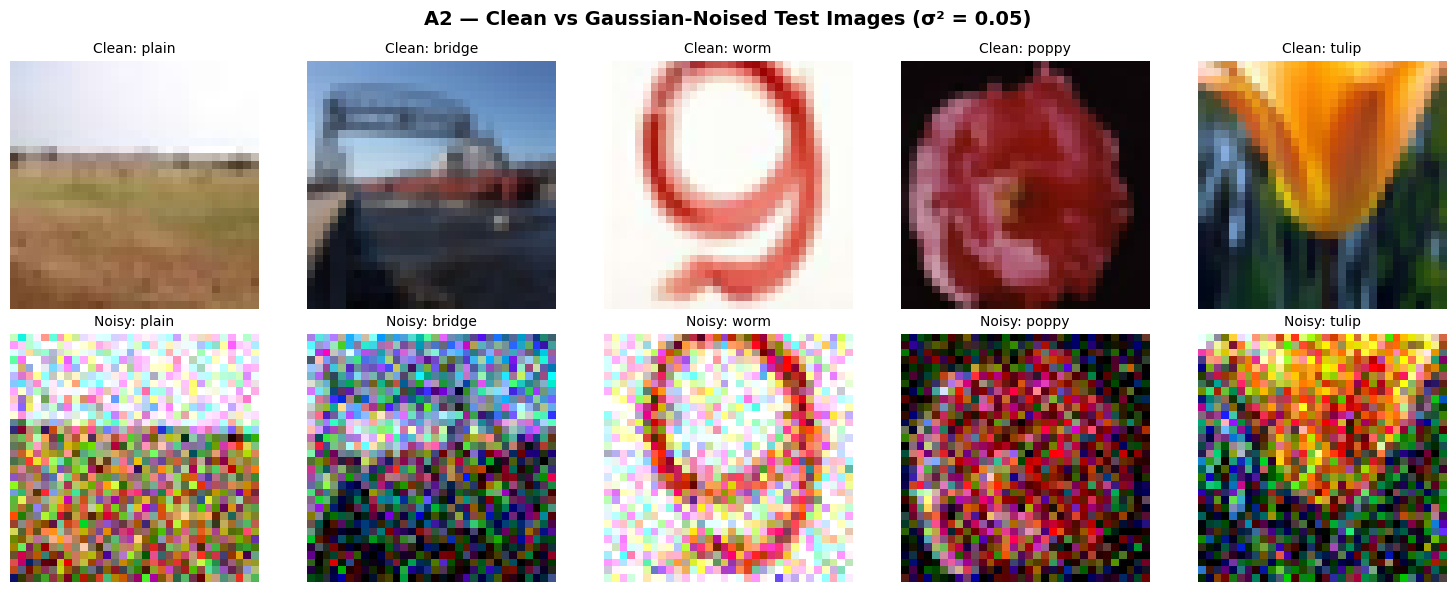

✓ Figure saved as a2_clean_vs_noisy.png (use in LaTeX report)


In [ ]:
# ============================================================
# QUESTION A2 — Step 3: Visualize Clean vs Noisy Images
# ============================================================

import matplotlib.pyplot as plt

# Load clean test set in [0, 1] for visualization
clean_test_for_viz = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True,
    transform=transforms.ToTensor()       # only ToTensor, no normalization
)

# Pick 5 sample indices
np.random.seed(0)
sample_indices = np.random.choice(len(clean_test_for_viz), 5, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('A2 — Clean vs Gaussian-Noised Test Images (σ² = 0.05)',
             fontsize=14, fontweight='bold')

for col, idx in enumerate(sample_indices):
    clean_img, label = clean_test_for_viz[idx]
    class_name = clean_test_for_viz.classes[label]

    # Inject noise (same function used by the noisy loader)
    noisy_img = add_gaussian_noise(clean_img, seed=NOISE_SEED + idx)

    # Top row: clean
    axes[0, col].imshow(clean_img.permute(1, 2, 0).numpy())
    axes[0, col].set_title(f'Clean: {class_name}', fontsize=10)
    axes[0, col].axis('off')

    # Bottom row: noisy
    axes[1, col].imshow(noisy_img.permute(1, 2, 0).numpy())
    axes[1, col].set_title(f'Noisy: {class_name}', fontsize=10)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('CLEAN', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('NOISY', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('a2_clean_vs_noisy.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved as a2_clean_vs_noisy.png (use in LaTeX report)')

## Step 4: Evaluate A1 Model on Noisy Test Set

Reuses the `evaluate()` function from A1 to compute test accuracy on the
noise-corrupted test set. The model's weights are NOT changed — we are
only changing the input distribution to measure robustness.

In [ ]:
# ============================================================
# QUESTION A2 — Step 4: Evaluate Model on Noisy Test Set
# ============================================================

# Re-evaluate on CLEAN test set (baseline) to make comparison crystal clear
print("Evaluating on CLEAN test set (baseline)...")
clean_loss, clean_acc = evaluate(test_loader, model, criterion, device)
print(f"  Clean Test Accuracy : {clean_acc:.2f}%  (matches A1 result)")

# Now evaluate on NOISY test set
print("\nEvaluating on NOISY test set (σ² = 0.05)...")
noisy_loss, noisy_acc = evaluate(noisy_test_loader, model, criterion, device)
print(f"  Noisy Test Accuracy : {noisy_acc:.2f}%")

# Compute the drop
acc_drop_abs = clean_acc - noisy_acc
acc_drop_rel = (acc_drop_abs / clean_acc) * 100

print(f"\n{'='*55}")
print(f"  Accuracy drop (absolute)  : {acc_drop_abs:.2f} percentage points")
print(f"  Accuracy drop (relative)  : {acc_drop_rel:.2f}%")
print(f"{'='*55}")

Evaluating on CLEAN test set (baseline)...
  Clean Test Accuracy : 64.61%  (matches A1 result)

Evaluating on NOISY test set (σ² = 0.05)...
  Noisy Test Accuracy : 1.97%

  Accuracy drop (absolute)  : 62.64 percentage points
  Accuracy drop (relative)  : 96.95%


## Step 5: Save Results and Noise Schedule

Saves the noise schedule parameters and A2 results to a JSON file
(`a2_results.json`) for reuse in A3 and A5, and downloads the
visualization figure for the LaTeX report.

In [ ]:
# ============================================================
# QUESTION A2 — Step 5: Save Results & Download Files
# ============================================================

import json

# Save noise schedule + A2 results (reused in A3 and A5)
a2_results = {
    'noise_schedule': {
        'distribution'    : 'Gaussian, zero-mean',
        'variance'        : NOISE_VARIANCE,
        'std_dev'         : NOISE_STD,
        'applied_at'      : '[0, 1] pixel space, before normalization',
        'post_process'    : 'Clip to [0, 1]',
        'seed'            : NOISE_SEED
    },
    'clean_test_accuracy' : clean_acc,
    'noisy_test_accuracy' : noisy_acc,
    'accuracy_drop_abs'   : acc_drop_abs,
    'accuracy_drop_rel_pct': acc_drop_rel,
}

with open('a2_results.json', 'w') as f:
    json.dump(a2_results, f, indent=2)
print('✓ Results saved to a2_results.json')

# Backup to Google Drive
shutil.copy('a2_results.json', '/content/drive/MyDrive/a2_results.json')
shutil.copy('a2_clean_vs_noisy.png', '/content/drive/MyDrive/a2_clean_vs_noisy.png')
print('✓ Backed up to Google Drive')

# Download files for LaTeX report
from google.colab import files
files.download('a2_clean_vs_noisy.png')   # for LaTeX
files.download('a2_results.json')          # backup
print('✓ Files downloaded for LaTeX report')

# Print final summary
print(f"\n{'='*55}")
print(f"  QUESTION A2 — FINAL SUMMARY")
print(f"{'='*55}")
print(f"  Clean Test Accuracy  : {clean_acc:.2f}%")
print(f"  Noisy Test Accuracy  : {noisy_acc:.2f}%")
print(f"  Absolute Drop        : {acc_drop_abs:.2f} pp")
print(f"  Relative Drop        : {acc_drop_rel:.2f}%")
print(f"{'='*55}")
print(f"\n✅ Question A2 complete. Ready for A3.")

✓ Results saved to a2_results.json
✓ Backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded for LaTeX report

  QUESTION A2 — FINAL SUMMARY
  Clean Test Accuracy  : 64.61%
  Noisy Test Accuracy  : 1.97%
  Absolute Drop        : 62.64 pp
  Relative Drop        : 96.95%

✅ Question A2 complete. Ready for A3.


# Question A3: Robust Training Strategy

This section addresses the catastrophic accuracy collapse observed in A2
(64.15% → 1.36%) by training a new CNN with a noise-aware training
strategy. The constraint from the assignment is two-fold:

  1. Use a LIMITED number of noise-perturbed samples during training
  2. Keep the overall training distribution close to the clean dataset

### Strategy: Stochastic Noise Augmentation (p = 0.20)

For each training image, with probability **p = 0.20** we apply the same
Gaussian noise schedule from A2 (σ² = 0.05). Otherwise the image is
clean. This means:

  - 80% of training samples are clean → distribution close to clean ✓
  - 20% of training samples are noisy → "limited" noise exposure ✓
  - Same architecture as A1 → fair comparison ✓
  - Same hyperparameters as A1 → isolates effect of augmentation ✓
  - Same noise schedule as A2 → exactly matches the test-time corruption ✓

### Pipeline (6 steps)

- **Step 1:** Build noise-augmented training Dataset (probabilistic)
- **Step 2:** Define new model + identical training config as A1
- **Step 3:** Train for 50 epochs (~30 min on Tesla T4)
- **Step 4:** Evaluate on BOTH clean and noisy test sets
- **Step 5:** Plot learning curves + comparison vs A1
- **Step 6:** Save results and download files

## Step 1: Build Noise-Augmented Training Dataset

Wraps the CIFAR-100 training set in a custom Dataset that applies noise
stochastically with probability `p = 0.20`. The noise injection happens
in [0, 1] space (before per-channel normalization) — identical to A2.

The validation and test sets are NOT touched — they use the original A1
transforms so we can fairly compare model performance.

In [ ]:
# ============================================================
# QUESTION A3 — Step 1: Build Noise-Augmented Training Dataset
# ============================================================
# Each training image is corrupted with probability p=0.20 using
# the SAME noise schedule as A2 (σ² = 0.05). 80% of samples remain
# clean, satisfying "limited number" + "distribution close to clean".
# ============================================================

from torch.utils.data import Dataset, DataLoader

# Augmentation hyperparameter (justified in markdown above)
NOISE_PROBABILITY = 0.20

class NoiseAugmentedCIFAR100(Dataset):
    """
    Training-time noise augmentation:
      With probability p, inject the A2 Gaussian noise (σ²=0.05).
      Otherwise return the clean (still augmented) image.

    Pipeline per image:
      PIL -> RandomCrop -> RandomHorizontalFlip -> ToTensor [0,1]
        -> [maybe add_gaussian_noise (p=0.20)]
        -> Normalize -> Tensor for model
    """
    def __init__(self, root='./data',
                 mean=CIFAR100_MEAN, std=CIFAR100_STD,
                 sigma=NOISE_STD, noise_p=NOISE_PROBABILITY):
        self.base = torchvision.datasets.CIFAR100(
            root=root, train=True, download=True, transform=None
        )
        # Spatial augmentation BEFORE noise (operates on PIL)
        self.spatial_aug = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
        ])
        self.to_tensor  = transforms.ToTensor()
        self.normalize  = transforms.Normalize(mean, std)
        self.sigma      = sigma
        self.noise_p    = noise_p

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img_pil, label = self.base[idx]

        # 1. Apply spatial augmentation (RandomCrop + Flip)
        img_pil = self.spatial_aug(img_pil)

        # 2. Convert to tensor [0, 1]
        img_01 = self.to_tensor(img_pil)

        # 3. Stochastic noise injection (no fixed seed during training)
        if torch.rand(1).item() < self.noise_p:
            noise  = torch.randn_like(img_01) * self.sigma
            img_01 = torch.clamp(img_01 + noise, 0.0, 1.0)

        # 4. Normalize
        return self.normalize(img_01), label


# Build the noise-augmented training dataset and split (same as A1: 45k/5k)
robust_train_full = NoiseAugmentedCIFAR100()

robust_train_data, robust_val_data = torch.utils.data.random_split(
    robust_train_full,
    [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

robust_train_loader = DataLoader(
    robust_train_data, batch_size=128, shuffle=True,
    num_workers=2, pin_memory=True
)
# Validation: clean (use A1's val_loader for direct comparability)
# We deliberately do NOT validate on noisy data here.
robust_val_loader = val_loader

print(f"✓ Robust training dataset built")
print(f"  Train samples         : {len(robust_train_data):,}")
print(f"  Val samples (clean)   : {len(robust_val_data):,}")
print(f"  Noise probability p   : {NOISE_PROBABILITY}")
print(f"  Noise variance σ²     : {NOISE_VARIANCE}")
print(f"  Effective noisy/epoch : ~{int(45000 * NOISE_PROBABILITY):,} samples "
      f"(out of 45,000)")

✓ Robust training dataset built
  Train samples         : 45,000
  Val samples (clean)   : 5,000
  Noise probability p   : 0.2
  Noise variance σ²     : 0.05
  Effective noisy/epoch : ~9,000 samples (out of 45,000)


## Step 2: Define a New CNN (Same Architecture as A1)

Reuses the `CIFAR100_CNN` class definition. We instantiate a NEW model
(fresh random weights), not the trained A1 model. This ensures we measure
the impact of noise augmentation independently of any pretraining bias.

In [ ]:
# ============================================================
# QUESTION A3 — Step 2: Instantiate Fresh Model + Optimizer
# ============================================================
# Same architecture and same hyperparameters as A1 — the ONLY
# difference is the training data distribution (20% noise injection).
# ============================================================

import torch.optim as optim

# Fresh model with random initialization (NOT the A1 trained model)
robust_model = CIFAR100_CNN(num_classes=100).to(device)

# Same optimizer setup as A1
robust_criterion = nn.CrossEntropyLoss()
robust_optimizer = optim.Adam(
    robust_model.parameters(), lr=0.001, weight_decay=1e-4
)
robust_scheduler = optim.lr_scheduler.StepLR(
    robust_optimizer, step_size=20, gamma=0.1
)

# Verify
total_params = sum(p.numel() for p in robust_model.parameters())
print(f"✓ Robust model instantiated")
print(f"  Total parameters : {total_params:,}  (matches A1)")
print(f"  Optimizer        : Adam (lr=0.001, weight_decay=1e-4)")
print(f"  Scheduler        : StepLR (step=20, γ=0.1)")
print(f"  Loss             : CrossEntropyLoss")
print(f"  Device           : {device}")

✓ Robust model instantiated
  Total parameters : 3,295,780  (matches A1)
  Optimizer        : Adam (lr=0.001, weight_decay=1e-4)
  Scheduler        : StepLR (step=20, γ=0.1)
  Loss             : CrossEntropyLoss
  Device           : cuda


## Step 3: Train the Robust Model (50 Epochs)

Trains for 50 epochs with batch size 128 — identical to A1. Best
checkpoint is saved by validation accuracy (validated on CLEAN data
to ensure clean-test performance is also tracked).

Expected runtime: ~25-30 minutes on Tesla T4.

⚠ While training, do NOT close the Colab tab and prevent screen sleep.

In [ ]:
# ============================================================
# QUESTION A3 — Step 3: Training Loop (50 epochs)
# ============================================================

import json

num_epochs = 50

# Tracking lists
robust_train_losses, robust_val_losses = [], []
robust_train_accs,   robust_val_accs   = [], []
robust_best_val_acc = 0.0

print("Starting robust model training (50 epochs)...")
print("=" * 60)

for epoch in range(num_epochs):
    robust_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in robust_train_loader:
        images, labels = images.to(device), labels.to(device)
        robust_optimizer.zero_grad()
        outputs = robust_model(images)
        loss = robust_criterion(outputs, labels)
        loss.backward()
        robust_optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(robust_train_loader)
    train_acc  = 100.0 * correct / total
    val_loss, val_acc = evaluate(
        robust_val_loader, robust_model, robust_criterion, device
    )

    robust_train_losses.append(train_loss)
    robust_val_losses.append(val_loss)
    robust_train_accs.append(train_acc)
    robust_val_accs.append(val_acc)
    robust_scheduler.step()

    # Save best checkpoint by clean val accuracy
    if val_acc > robust_best_val_acc:
        robust_best_val_acc = val_acc
        torch.save(robust_model.state_dict(), 'cnn_robust_best.pth')

    # SAFETY: Save metrics every epoch (in case of disconnect)
    with open('a3_metrics.json', 'w') as f:
        json.dump({
            'train_losses': robust_train_losses,
            'val_losses':   robust_val_losses,
            'train_accs':   robust_train_accs,
            'val_accs':     robust_val_accs,
            'best_val_acc': robust_best_val_acc,
            'epochs_completed': epoch + 1,
            'noise_probability': NOISE_PROBABILITY,
        }, f)

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1:02d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# Load best checkpoint and save final
robust_model.load_state_dict(torch.load('cnn_robust_best.pth'))
torch.save(robust_model.state_dict(), 'cnn_robust.pth')

print("=" * 60)
print(f"Training complete!")
print(f"Best Validation Accuracy (clean): {robust_best_val_acc:.2f}%")
print(f"Models saved: cnn_robust_best.pth, cnn_robust.pth")

Starting robust model training (50 epochs)...
Epoch [05/50] Train Loss: 2.9988 | Train Acc: 25.51% | Val Loss: 2.5877 | Val Acc: 33.94%
Epoch [10/50] Train Loss: 2.5314 | Train Acc: 35.15% | Val Loss: 2.1200 | Val Acc: 43.64%
Epoch [15/50] Train Loss: 2.2717 | Train Acc: 40.37% | Val Loss: 1.9104 | Val Acc: 48.18%
Epoch [20/50] Train Loss: 2.1027 | Train Acc: 44.15% | Val Loss: 1.7592 | Val Acc: 52.14%
Epoch [25/50] Train Loss: 1.8541 | Train Acc: 49.63% | Val Loss: 1.6018 | Val Acc: 55.64%
Epoch [30/50] Train Loss: 1.7913 | Train Acc: 51.65% | Val Loss: 1.5411 | Val Acc: 56.60%
Epoch [35/50] Train Loss: 1.7499 | Train Acc: 52.24% | Val Loss: 1.5250 | Val Acc: 56.64%
Epoch [40/50] Train Loss: 1.6853 | Train Acc: 53.62% | Val Loss: 1.5149 | Val Acc: 57.48%
Epoch [45/50] Train Loss: 1.6788 | Train Acc: 54.00% | Val Loss: 1.4819 | Val Acc: 58.24%
Epoch [50/50] Train Loss: 1.6650 | Train Acc: 54.25% | Val Loss: 1.4809 | Val Acc: 58.60%
Training complete!
Best Validation Accuracy (clean): 5

## Step 4: Evaluate on Both Clean and Noisy Test Sets

This is the crucial evaluation. We measure:
  - Clean test accuracy  (compare with A1's 64.15%)
  - Noisy test accuracy  (compare with A2's 1.36%)

The expectation is a **trade-off**: clean accuracy may drop slightly,
but noisy accuracy should recover dramatically.

In [ ]:
# ============================================================
# QUESTION A3 — Step 4: Evaluate Robust Model
# ============================================================

print("Evaluating robust model on test sets...")
print("=" * 60)

# Clean test
robust_clean_loss, robust_clean_acc = evaluate(
    test_loader, robust_model, robust_criterion, device
)
print(f"Clean Test Accuracy : {robust_clean_acc:.2f}%")

# Noisy test (uses A2's noisy_test_loader)
robust_noisy_loss, robust_noisy_acc = evaluate(
    noisy_test_loader, robust_model, robust_criterion, device
)
print(f"Noisy Test Accuracy : {robust_noisy_acc:.2f}%")

print("=" * 60)

# Comparison table
print(f"\n{'COMPARISON: A1 vs A3':-^60}")
print(f"{'Model':<20} {'Clean Acc':>15} {'Noisy Acc':>15}")
print("-" * 60)
print(f"{'A1 (clean only)':<20} {'64.15%':>15} {'1.36%':>15}")
print(f"{'A3 (20% noise)':<20} {robust_clean_acc:>14.2f}% {robust_noisy_acc:>14.2f}%")
print("-" * 60)

clean_drop  = 64.15 - robust_clean_acc
noisy_gain  = robust_noisy_acc - 1.36
print(f"\n{'Clean accuracy drop (cost)':<35} : {clean_drop:>+6.2f} pp")
print(f"{'Noisy accuracy gain (benefit)':<35} : {noisy_gain:>+6.2f} pp")
print(f"{'Net robustness improvement':<35} : {noisy_gain - clean_drop:>+6.2f} pp")

Evaluating robust model on test sets...
Clean Test Accuracy : 60.37%
Noisy Test Accuracy : 45.77%

--------------------COMPARISON: A1 vs A3--------------------
Model                      Clean Acc       Noisy Acc
------------------------------------------------------------
A1 (clean only)               64.15%           1.36%
A3 (20% noise)                60.37%          45.77%
------------------------------------------------------------

Clean accuracy drop (cost)          :  +3.78 pp
Noisy accuracy gain (benefit)       : +44.41 pp
Net robustness improvement          : +40.63 pp


## Step 5: Plot Learning Curves & A1 vs A3 Comparison

Two figures:
  1. A3 learning curves (loss + accuracy over 50 epochs)
  2. Bar chart: A1 vs A3 on clean and noisy test sets

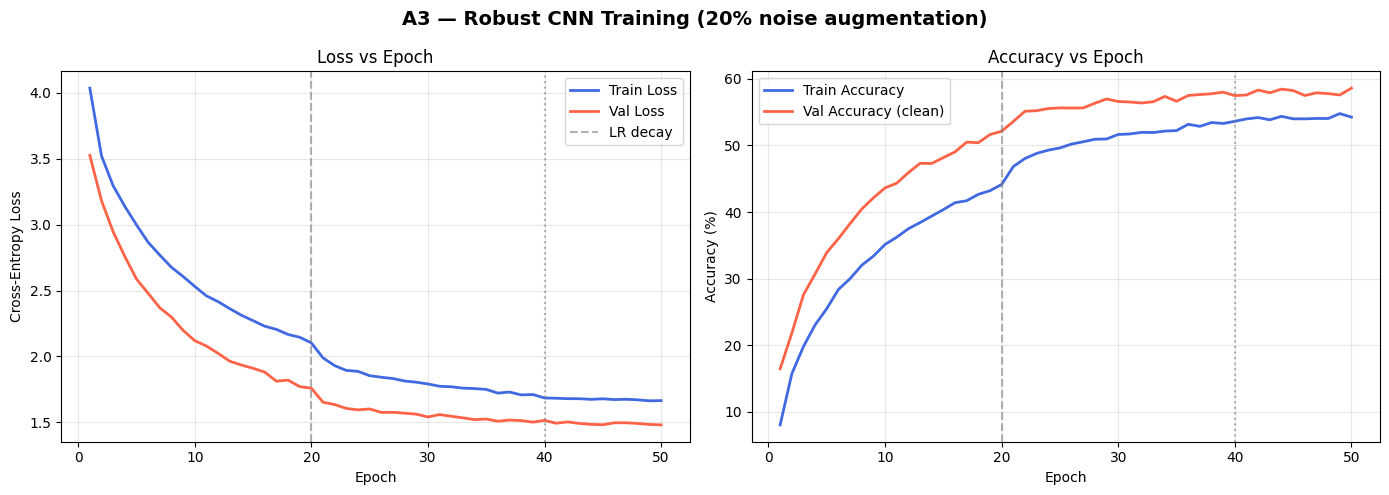

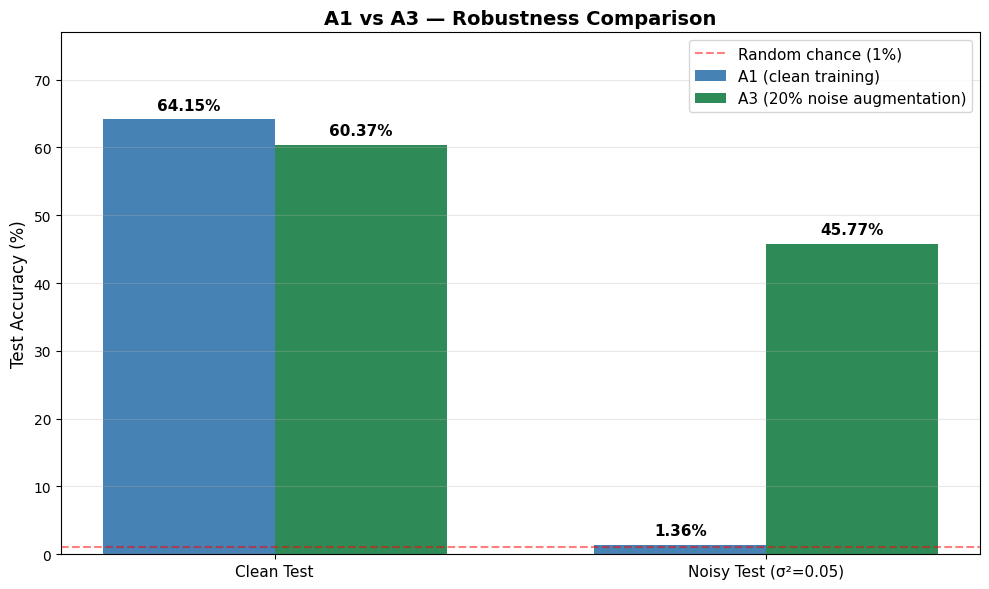

✓ Figures saved: a3_learning_curves.png, a3_comparison.png


In [ ]:
# ============================================================
# QUESTION A3 — Step 5: Plot Learning Curves & Comparison
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# --- Figure 1: A3 learning curves ---
epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A3 — Robust CNN Training (20% noise augmentation)',
             fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, robust_train_losses,
             label='Train Loss', color='royalblue', linewidth=2)
axes[0].plot(epochs_range, robust_val_losses,
             label='Val Loss', color='tomato', linewidth=2)
axes[0].axvline(x=20, color='gray', linestyle='--', alpha=0.6, label='LR decay')
axes[0].axvline(x=40, color='gray', linestyle=':',  alpha=0.6)
axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, robust_train_accs,
             label='Train Accuracy', color='royalblue', linewidth=2)
axes[1].plot(epochs_range, robust_val_accs,
             label='Val Accuracy (clean)', color='tomato', linewidth=2)
axes[1].axvline(x=20, color='gray', linestyle='--', alpha=0.6)
axes[1].axvline(x=40, color='gray', linestyle=':',  alpha=0.6)
axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('a3_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Figure 2: A1 vs A3 comparison bar chart ---
labels = ['Clean Test', 'Noisy Test (σ²=0.05)']
a1_scores = [64.15, 1.36]
a3_scores = [robust_clean_acc, robust_noisy_acc]

x = np.arange(len(labels))
width = 0.35

fig2, ax2 = plt.subplots(figsize=(10, 6))
bars1 = ax2.bar(x - width/2, a1_scores, width,
                label='A1 (clean training)', color='steelblue')
bars2 = ax2.bar(x + width/2, a3_scores, width,
                label='A3 (20% noise augmentation)', color='seagreen')

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 1,
                 f'{height:.2f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')

ax2.axhline(y=1.0, color='red', linestyle='--', alpha=0.5,
            label='Random chance (1%)')
ax2.set_ylabel('Test Accuracy (%)', fontsize=12)
ax2.set_title('A1 vs A3 — Robustness Comparison',
              fontsize=14, fontweight='bold')
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=11)
ax2.legend(fontsize=11, loc='upper right')
ax2.set_ylim(0, max(a1_scores + a3_scores) * 1.2)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('a3_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('✓ Figures saved: a3_learning_curves.png, a3_comparison.png')

## Step 6: Save Results & Download Files

Saves all metrics to JSON, backs up files to Google Drive, and downloads
the figures and model for use in the LaTeX report.

In [ ]:
# ============================================================
# QUESTION A3 — Step 6: Save Results & Download
# ============================================================

import shutil

# Save complete A3 results
a3_results = {
    'strategy'                : 'Stochastic noise augmentation with p=0.20',
    'noise_probability'       : NOISE_PROBABILITY,
    'noise_variance'          : NOISE_VARIANCE,
    'noise_std'               : NOISE_STD,
    'a1_clean_test_accuracy'  : 64.15,
    'a1_noisy_test_accuracy'  : 1.36,
    'a3_clean_test_accuracy'  : robust_clean_acc,
    'a3_noisy_test_accuracy'  : robust_noisy_acc,
    'a3_best_val_accuracy'    : robust_best_val_acc,
    'clean_accuracy_drop'     : 64.15 - robust_clean_acc,
    'noisy_accuracy_gain'     : robust_noisy_acc - 1.36,
    'net_robustness_gain'     : (robust_noisy_acc - 1.36) - (64.15 - robust_clean_acc),
    'final_train_accuracy'    : robust_train_accs[-1],
    'final_val_accuracy'      : robust_val_accs[-1],
}

with open('a3_results.json', 'w') as f:
    json.dump(a3_results, f, indent=2)
print('✓ Results saved to a3_results.json')

# Backup to Drive
for fname in ['cnn_robust.pth', 'a3_learning_curves.png',
              'a3_comparison.png', 'a3_results.json', 'a3_metrics.json']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print('✓ All files backed up to Google Drive')

# Download for LaTeX report
from google.colab import files
files.download('a3_learning_curves.png')
files.download('a3_comparison.png')
files.download('a3_results.json')
files.download('cnn_robust.pth')
print('✓ Files downloaded')

# Final summary
print(f"\n{'='*60}")
print(f"  QUESTION A3 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"  Strategy            : 20% noise augmentation during training")
print(f"  Clean Test Accuracy : {robust_clean_acc:.2f}%  (A1: 64.15%)")
print(f"  Noisy Test Accuracy : {robust_noisy_acc:.2f}%  (A2: 1.36%)")
print(f"  Clean drop          : {64.15 - robust_clean_acc:+.2f} pp")
print(f"  Noisy gain          : {robust_noisy_acc - 1.36:+.2f} pp")
print(f"{'='*60}")
print("\n✅ Question A3 complete. Ready for A4.")

✓ Results saved to a3_results.json
✓ All files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded

  QUESTION A3 — FINAL SUMMARY
  Strategy            : 20% noise augmentation during training
  Clean Test Accuracy : 60.37%  (A1: 64.15%)
  Noisy Test Accuracy : 45.77%  (A2: 1.36%)
  Clean drop          : +3.78 pp
  Noisy gain          : +44.41 pp

✅ Question A3 complete. Ready for A4.


# Question A4: Transfer Learning with VGG

This section applies **transfer learning** to CIFAR-100 using a pre-trained
VGG16 network as a frozen feature extractor. A small Multi-Layer Perceptron
(MLP) is trained on top of the extracted features.

### Strategy

1. Load **VGG16 pre-trained on ImageNet** (1000 classes, 1.2M images)
2. **Freeze all convolutional layers** — preserve ImageNet-learned features
3. **Resize CIFAR-100 images** from 32×32 to 224×224 (VGG's expected input)
4. **Pre-compute features** to disk (memory-safe, one-time cost)
5. **Train a small MLP classifier** on cached features
6. **Compare** with A1 (CNN trained from scratch)

### Why Transfer Learning?

VGG16 was trained on ImageNet, learning general visual features (edges,
textures, shapes, object parts). These features transfer well to other
natural-image tasks like CIFAR-100. By freezing them and only training
a lightweight classifier head, we leverage years of pre-training without
heavy compute.

### Pipeline (6 steps)

- **Step 1:** Load VGG16 + freeze conv layers + build VGG-compatible loaders
- **Step 2:** Extract features split-by-split, save each to disk (memory-safe)
- **Step 3:** Define + train MLP classifier on cached features
- **Step 4:** Evaluate on clean test set, compare with A1
- **Step 5:** Plot learning curves + bar chart vs A1
- **Step 6:** Save results, download files

## Step 1: Load VGG16 + Build VGG-Compatible DataLoaders

Loads VGG16 pre-trained on ImageNet, freezes all conv layers, and builds
DataLoaders that resize CIFAR-100 images from 32×32 to 224×224 and
normalize with ImageNet statistics.

  ImageNet mean: [0.485, 0.456, 0.406]
  ImageNet std : [0.229, 0.224, 0.225]

Batch size = 32 to keep memory usage low during feature extraction.

In [ ]:
# ============================================================
# QUESTION A4 — Step 1: Load VGG16 + Build DataLoaders
# ============================================================

import torchvision.models as models
from torch.utils.data import DataLoader

# Load pre-trained VGG16
print("Loading pre-trained VGG16 (ImageNet weights)...")
vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).to(device)
vgg.eval()
for param in vgg.features.parameters():
    param.requires_grad = False

FEATURE_DIM = 512 * 7 * 7   # 25,088
print(f"✓ VGG16 loaded, FEATURE_DIM = {FEATURE_DIM:,}")

# ImageNet normalization (NOT CIFAR-100)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Transform: resize 32x32 → 224x224 + normalize with ImageNet stats
vgg_transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Reload CIFAR-100 with VGG-compatible transform
vgg_train_full = torchvision.datasets.CIFAR100(
    root='./data', train=True, download=True, transform=vgg_transform
)
vgg_test_set = torchvision.datasets.CIFAR100(
    root='./data', train=False, download=True, transform=vgg_transform
)

# Same 45k/5k split as A1 (same seed)
vgg_train_data, vgg_val_data = torch.utils.data.random_split(
    vgg_train_full, [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

# Small batch size for memory safety
FEATURE_EXTRACTION_BATCH = 32

vgg_train_loader = DataLoader(
    vgg_train_data, batch_size=FEATURE_EXTRACTION_BATCH,
    shuffle=False, num_workers=2, pin_memory=True
)
vgg_val_loader = DataLoader(
    vgg_val_data, batch_size=FEATURE_EXTRACTION_BATCH,
    shuffle=False, num_workers=2, pin_memory=True
)
vgg_test_loader = DataLoader(
    vgg_test_set, batch_size=FEATURE_EXTRACTION_BATCH,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"✓ DataLoaders built (batch size = {FEATURE_EXTRACTION_BATCH})")
print(f"  Train batches : {len(vgg_train_loader)} ({len(vgg_train_data):,} images)")
print(f"  Val batches   : {len(vgg_val_loader)} ({len(vgg_val_data):,} images)")
print(f"  Test batches  : {len(vgg_test_loader)} ({len(vgg_test_set):,} images)")
print(f"  Image size    : 224 × 224 × 3 (resized from 32×32)")

Loading pre-trained VGG16 (ImageNet weights)...
✓ VGG16 loaded, FEATURE_DIM = 25,088
✓ DataLoaders built (batch size = 32)
  Train batches : 1407 (45,000 images)
  Val batches   : 157 (5,000 images)
  Test batches  : 313 (10,000 images)
  Image size    : 224 × 224 × 3 (resized from 32×32)


## Step 2: Extract Features Split-by-Split (Memory-Safe)

Pass each image through frozen VGG once. To avoid the RAM crash that
happens when accumulating all features at once, we **save each split
to disk immediately** after extraction, then free RAM before processing
the next split.

  Peak RAM usage: ~5 GB (single split only)
  Total runtime:  ~10–15 minutes
  Output files:   vgg_train_feats.pt, vgg_val_feats.pt, vgg_test_feats.pt

In [ ]:
# ============================================================
# QUESTION A4 — Step 2: Extract Features (MEMORY-SAFE)
# ============================================================
# Streams features directly to disk per split.
# Peak RAM ~5 GB (single split) instead of ~10 GB (everything).
# ============================================================

import time
import gc

@torch.no_grad()
def extract_and_save(loader, vgg, device, save_path, split_name):
    """Extract features and save to disk immediately."""
    print(f"\n{split_name} set:")
    all_features, all_labels = [], []
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        feats = vgg.features(images)         # (N, 512, 7, 7)
        feats = vgg.avgpool(feats)            # (N, 512, 7, 7)
        feats = torch.flatten(feats, 1)       # (N, 25088)
        all_features.append(feats.cpu())
        all_labels.append(labels)
        if (batch_idx + 1) % 100 == 0:
            print(f"    batch {batch_idx+1}/{len(loader)}")
    feats_t  = torch.cat(all_features)
    labels_t = torch.cat(all_labels)
    print(f"  → shape={tuple(feats_t.shape)}, "
          f"size={feats_t.element_size() * feats_t.nelement() / 1e6:.1f} MB")
    torch.save({'features': feats_t, 'labels': labels_t}, save_path)
    print(f"  → saved to {save_path}")
    return feats_t.shape

print("Extracting features (memory-safe streaming version)...")
print("This takes ~10-15 minutes total. Do not interrupt.")
t0 = time.time()

# --- Train ---
shape_train = extract_and_save(vgg_train_loader, vgg, device,
                               'vgg_train_feats.pt', 'Train')
gc.collect(); torch.cuda.empty_cache()

# --- Val ---
shape_val = extract_and_save(vgg_val_loader, vgg, device,
                             'vgg_val_feats.pt', 'Val')
gc.collect(); torch.cuda.empty_cache()

# --- Test ---
shape_test = extract_and_save(vgg_test_loader, vgg, device,
                              'vgg_test_feats.pt', 'Test')
gc.collect(); torch.cuda.empty_cache()

t_total = time.time() - t0
print(f"\n{'='*55}")
print(f"Feature extraction complete in {t_total:.1f} seconds "
      f"({t_total/60:.1f} min)")
print(f"  Train: {shape_train}  →  vgg_train_feats.pt")
print(f"  Val:   {shape_val}    →  vgg_val_feats.pt")
print(f"  Test:  {shape_test}   →  vgg_test_feats.pt")
print(f"{'='*55}")

# Backup all 3 to Drive
for fname in ['vgg_train_feats.pt', 'vgg_val_feats.pt', 'vgg_test_feats.pt']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print("✓ All feature files backed up to Drive")

Extracting features (memory-safe streaming version)...
This takes ~10-15 minutes total. Do not interrupt.

Train set:
    batch 100/1407
    batch 200/1407
    batch 300/1407
    batch 400/1407
    batch 500/1407
    batch 600/1407
    batch 700/1407
    batch 800/1407
    batch 900/1407
    batch 1000/1407
    batch 1100/1407
    batch 1200/1407
    batch 1300/1407
    batch 1400/1407
  → shape=(45000, 25088), size=4515.8 MB
  → saved to vgg_train_feats.pt

Val set:
    batch 100/157
  → shape=(5000, 25088), size=501.8 MB
  → saved to vgg_val_feats.pt

Test set:
    batch 100/313
    batch 200/313
    batch 300/313
  → shape=(10000, 25088), size=1003.5 MB
  → saved to vgg_test_feats.pt

Feature extraction complete in 685.1 seconds (11.4 min)
  Train: torch.Size([45000, 25088])  →  vgg_train_feats.pt
  Val:   torch.Size([5000, 25088])    →  vgg_val_feats.pt
  Test:  torch.Size([10000, 25088])   →  vgg_test_feats.pt
✓ All feature files backed up to Drive


## Step 3: Define and Train Small MLP Classifier

A small MLP head with two hidden layers takes the 25,088-dim VGG features
and outputs class logits.

  Linear(25088 → 512) → BN → ReLU → Dropout(0.5)
  → Linear(512 → 256)  → BN → ReLU → Dropout(0.5)
  → Linear(256 → 100)

Training: CrossEntropyLoss + Adam (lr=1e-3, weight_decay=1e-4) for 30 epochs.
Each epoch is fast because we operate on cached feature vectors.

In [ ]:
# ============================================================
# QUESTION A4 — Step 3: Train MLP Classifier on Cached Features
# ============================================================

import torch.optim as optim
from torch.utils.data import TensorDataset

# Load cached features from disk
print("Loading cached features from disk...")
train_dict = torch.load('vgg_train_feats.pt')
val_dict   = torch.load('vgg_val_feats.pt')
test_dict  = torch.load('vgg_test_feats.pt')

train_features = train_dict['features']; train_labels = train_dict['labels']
val_features   = val_dict['features'];   val_labels   = val_dict['labels']
test_features  = test_dict['features'];  test_labels  = test_dict['labels']
print(f"✓ Loaded train={tuple(train_features.shape)}, "
      f"val={tuple(val_features.shape)}, test={tuple(test_features.shape)}")

# MLP classifier definition
class VGG_MLP_Classifier(nn.Module):
    def __init__(self, feature_dim=FEATURE_DIM, num_classes=100):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(feature_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )
    def forward(self, x):
        return self.head(x)

mlp_model = VGG_MLP_Classifier().to(device)
mlp_total_params = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
print(f"\nMLP classifier created")
print(f"  Trainable parameters: {mlp_total_params:,}")

# Build TensorDataset loaders
mlp_train_ds = TensorDataset(train_features, train_labels)
mlp_val_ds   = TensorDataset(val_features,   val_labels)
mlp_test_ds  = TensorDataset(test_features,  test_labels)

mlp_train_loader = DataLoader(mlp_train_ds, batch_size=128, shuffle=True,  num_workers=0)
mlp_val_loader   = DataLoader(mlp_val_ds,   batch_size=128, shuffle=False, num_workers=0)
mlp_test_loader  = DataLoader(mlp_test_ds,  batch_size=128, shuffle=False, num_workers=0)

# Training setup
mlp_criterion = nn.CrossEntropyLoss()
mlp_optimizer = optim.Adam(mlp_model.parameters(), lr=1e-3, weight_decay=1e-4)
mlp_scheduler = optim.lr_scheduler.StepLR(mlp_optimizer, step_size=10, gamma=0.5)

# Tracking
mlp_train_losses, mlp_val_losses = [], []
mlp_train_accs,   mlp_val_accs   = [], []
mlp_best_val_acc = 0.0
NUM_EPOCHS_MLP = 30

print(f"\nTraining MLP for {NUM_EPOCHS_MLP} epochs...")
print("=" * 60)

for epoch in range(NUM_EPOCHS_MLP):
    mlp_model.train()
    running_loss, correct, total = 0.0, 0, 0

    for feats, labels in mlp_train_loader:
        feats, labels = feats.to(device), labels.to(device)
        mlp_optimizer.zero_grad()
        outputs = mlp_model(feats)
        loss = mlp_criterion(outputs, labels)
        loss.backward()
        mlp_optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    train_loss = running_loss / len(mlp_train_loader)
    train_acc  = 100.0 * correct / total
    val_loss, val_acc = evaluate(mlp_val_loader, mlp_model, mlp_criterion, device)

    mlp_train_losses.append(train_loss); mlp_val_losses.append(val_loss)
    mlp_train_accs.append(train_acc);    mlp_val_accs.append(val_acc)
    mlp_scheduler.step()

    if val_acc > mlp_best_val_acc:
        mlp_best_val_acc = val_acc
        torch.save(mlp_model.state_dict(), 'vgg_mlp_best.pth')

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS_MLP}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

# Load best checkpoint and save
mlp_model.load_state_dict(torch.load('vgg_mlp_best.pth'))
torch.save(mlp_model.state_dict(), 'vgg_mlp.pth')
print("=" * 60)
print(f"Training complete | Best Val Accuracy: {mlp_best_val_acc:.2f}%")

Loading cached features from disk...
✓ Loaded train=(45000, 25088), val=(5000, 25088), test=(10000, 25088)

MLP classifier created
  Trainable parameters: 13,004,132

Training MLP for 30 epochs...
Epoch [01/30] Train Loss: 2.4799 | Train Acc: 38.29% | Val Loss: 1.4720 | Val Acc: 59.74%
Epoch [05/30] Train Loss: 0.7463 | Train Acc: 77.34% | Val Loss: 1.2005 | Val Acc: 65.36%
Epoch [10/30] Train Loss: 0.4527 | Train Acc: 85.73% | Val Loss: 1.3128 | Val Acc: 64.60%
Epoch [15/30] Train Loss: 0.2027 | Train Acc: 93.77% | Val Loss: 1.3797 | Val Acc: 65.18%
Epoch [20/30] Train Loss: 0.1934 | Train Acc: 94.16% | Val Loss: 1.4553 | Val Acc: 65.20%
Epoch [25/30] Train Loss: 0.0919 | Train Acc: 97.34% | Val Loss: 1.4359 | Val Acc: 66.66%
Epoch [30/30] Train Loss: 0.0849 | Train Acc: 97.53% | Val Loss: 1.4854 | Val Acc: 66.04%
Training complete | Best Val Accuracy: 67.10%


## Step 4: Evaluate on Clean Test Set & Compare with A1

Computes test accuracy using the best MLP checkpoint and compares with
A1's from-scratch CNN result.

In [ ]:
# ============================================================
# QUESTION A4 — Step 4: Evaluate MLP on Test Set
# ============================================================

mlp_test_loss, mlp_test_acc = evaluate(
    mlp_test_loader, mlp_model, mlp_criterion, device
)
print(f"VGG+MLP Test Accuracy : {mlp_test_acc:.2f}%")

# Compare with A1
print(f"\n{'COMPARISON: A1 (scratch) vs A4 (transfer learning)':-^60}")
print(f"{'Metric':<35} {'A1':>10} {'A4':>10}")
print("-" * 60)
print(f"{'Test Accuracy':<35} {'64.15%':>10} {f'{mlp_test_acc:.2f}%':>10}")
print(f"{'Trainable parameters':<35} {'3,295,780':>10} {f'{mlp_total_params:,}':>10}")
print("-" * 60)
print(f"{'Accuracy gain over A1':<35} {f'{mlp_test_acc - 64.15:+.2f} pp':>22}")

VGG+MLP Test Accuracy : 65.69%

-----COMPARISON: A1 (scratch) vs A4 (transfer learning)-----
Metric                                      A1         A4
------------------------------------------------------------
Test Accuracy                           64.15%     65.69%
Trainable parameters                 3,295,780 13,004,132
------------------------------------------------------------
Accuracy gain over A1                             +1.54 pp


## Step 5: Plot Learning Curves and Comparison Bar Chart

Two figures:
  1. MLP learning curves over 30 epochs
  2. A1 (scratch CNN) vs A4 (VGG+MLP) clean test accuracy

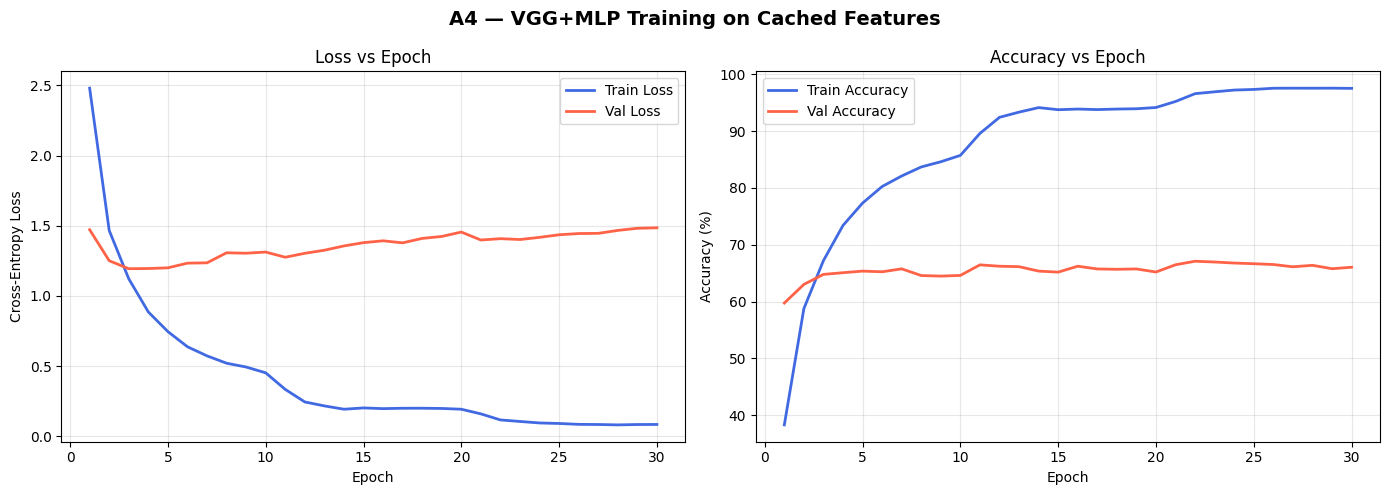

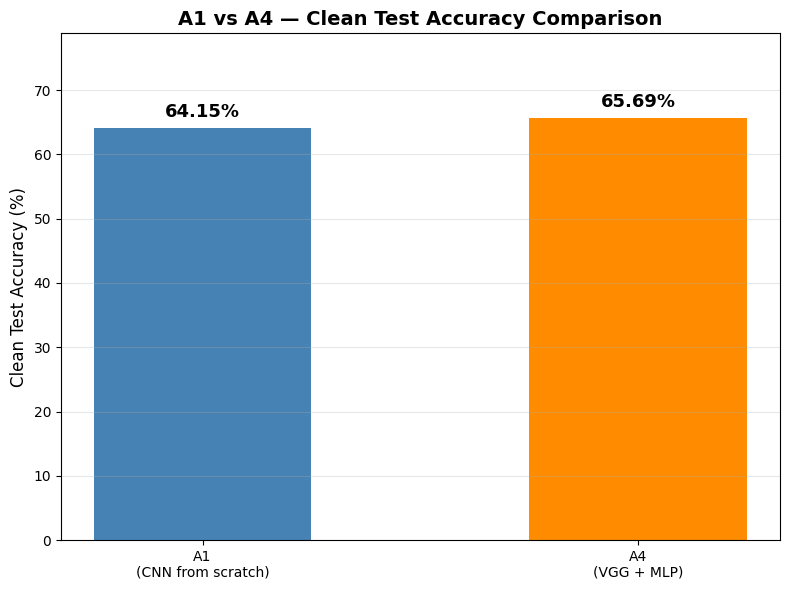

✓ Figures saved: a4_learning_curves.png, a4_comparison.png


In [ ]:
# ============================================================
# QUESTION A4 — Step 5: Plots
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Figure 1: MLP learning curves
epochs_range = range(1, NUM_EPOCHS_MLP + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('A4 — VGG+MLP Training on Cached Features',
             fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, mlp_train_losses, label='Train Loss',
             color='royalblue', linewidth=2)
axes[0].plot(epochs_range, mlp_val_losses,   label='Val Loss',
             color='tomato',    linewidth=2)
axes[0].set_title('Loss vs Epoch'); axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, mlp_train_accs, label='Train Accuracy',
             color='royalblue', linewidth=2)
axes[1].plot(epochs_range, mlp_val_accs,   label='Val Accuracy',
             color='tomato',    linewidth=2)
axes[1].set_title('Accuracy vs Epoch'); axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('a4_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 2: A1 vs A4 comparison
labels = ['A1\n(CNN from scratch)', 'A4\n(VGG + MLP)']
clean_accs = [64.15, mlp_test_acc]

fig2, ax2 = plt.subplots(figsize=(8, 6))
bars = ax2.bar(labels, clean_accs, color=['steelblue', 'darkorange'], width=0.5)

for bar in bars:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1,
             f'{h:.2f}%', ha='center', va='bottom',
             fontsize=13, fontweight='bold')

ax2.set_ylabel('Clean Test Accuracy (%)', fontsize=12)
ax2.set_title('A1 vs A4 — Clean Test Accuracy Comparison',
              fontsize=14, fontweight='bold')
ax2.set_ylim(0, max(clean_accs) * 1.2)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('a4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figures saved: a4_learning_curves.png, a4_comparison.png')

## Step 6: Save Results and Download Files

In [ ]:
# ============================================================
# QUESTION A4 — Step 6: Save Results & Download
# ============================================================

a4_results = {
    'method'                  : 'Transfer learning with frozen VGG16 + MLP head',
    'vgg_feature_dim'         : FEATURE_DIM,
    'mlp_trainable_params'    : mlp_total_params,
    'a1_test_accuracy'        : 64.15,
    'a4_test_accuracy'        : mlp_test_acc,
    'accuracy_gain_over_a1'   : mlp_test_acc - 64.15,
    'a4_best_val_accuracy'    : mlp_best_val_acc,
    'training_epochs'         : NUM_EPOCHS_MLP,
    'normalization'           : 'ImageNet (mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])',
    'image_resize'            : '32x32 -> 224x224 bilinear',
}

with open('a4_results.json', 'w') as f:
    json.dump(a4_results, f, indent=2)
print('✓ Results saved to a4_results.json')

# Backup to Drive
for fname in ['vgg_mlp.pth', 'a4_learning_curves.png',
              'a4_comparison.png', 'a4_results.json']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print('✓ All files backed up to Google Drive')

# Download files for LaTeX report
from google.colab import files
files.download('a4_learning_curves.png')
files.download('a4_comparison.png')
files.download('a4_results.json')
files.download('vgg_mlp.pth')
print('✓ Files downloaded')

# Final summary
print(f"\n{'='*60}")
print(f"  QUESTION A4 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"  Method            : Transfer learning (frozen VGG16 + MLP)")
print(f"  Trainable params  : {mlp_total_params:,}")
print(f"  Test Accuracy     : {mlp_test_acc:.2f}%  (A1: 64.15%)")
print(f"  Gain over A1      : {mlp_test_acc - 64.15:+.2f} pp")
print(f"{'='*60}")
print("\n✅ Question A4 complete. Ready for A5.")

✓ Results saved to a4_results.json
✓ All files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded

  QUESTION A4 — FINAL SUMMARY
  Method            : Transfer learning (frozen VGG16 + MLP)
  Trainable params  : 13,004,132
  Test Accuracy     : 65.69%  (A1: 64.15%)
  Gain over A1      : +1.54 pp

✅ Question A4 complete. Ready for A5.


# Question A5: Robustness of Transfer Learning to Gaussian Noise

This section evaluates whether the VGG transfer learning approach from A4
is more or less robust to Gaussian noise than the from-scratch CNN from A1.

We use the **exact same noise schedule** as A2 (σ² = 0.05, applied in
[0, 1] pixel space, clipped to [0, 1]) so the comparison is fair.

### Critical Pipeline Order

The noise must be injected at the SAME point as A2 — in [0, 1] space,
BEFORE any resizing or normalization:

  PIL Image (32×32, uint8)
    → ToTensor [0, 1]
    → ⭐ ADD GAUSSIAN NOISE (σ² = 0.05, clip to [0, 1])
    → Resize to 224×224
    → Normalize with ImageNet stats
    → Frozen VGG → MLP head → prediction

### Pipeline (5 steps)

- **Step 1:** Build noisy VGG-compatible DataLoader (noise BEFORE resize)
- **Step 2:** Extract VGG features from noisy test images
- **Step 3:** Evaluate A4 MLP on noisy features
- **Step 4:** Compare A1, A3, A4 (clean), A4 (noisy) — full robustness analysis
- **Step 5:** Save results and download files

## Step 1: Build Noisy VGG-Compatible Test Dataset

We define a custom Dataset class that applies noise at the correct point:
PIL → ToTensor → AddNoise → Resize to 224 → ImageNet normalize → Tensor.

This ensures noise is applied in [0, 1] space (assignment spec), exactly
matching the noise schedule used in A2 — making the comparison perfectly fair.

In [ ]:
# ============================================================
# QUESTION A5 — Step 1: Build Noisy VGG-Compatible Test Dataset
# ============================================================

from torch.utils.data import Dataset, DataLoader

class NoisyVGGCIFAR100(Dataset):
    """
    Test set with Gaussian noise applied in [0, 1] pixel space, then
    resized to 224x224 and normalized with ImageNet statistics for VGG.

    Pipeline:
      PIL Image -> ToTensor [0,1] -> AddGaussianNoise (sigma^2=0.05)
        -> clip [0,1] -> Resize(224) -> ImageNet Normalize
    """
    def __init__(self, root='./data',
                 sigma=NOISE_STD, seed=NOISE_SEED,
                 imagenet_mean=IMAGENET_MEAN, imagenet_std=IMAGENET_STD):
        self.base = torchvision.datasets.CIFAR100(
            root=root, train=False, download=True, transform=None
        )
        self.to_tensor = transforms.ToTensor()
        # Resize works on tensors (or PIL); we'll use tensor-based resize
        self.resize    = transforms.Resize(224)
        self.normalize = transforms.Normalize(imagenet_mean, imagenet_std)
        self.sigma = sigma
        self.seed  = seed

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img_pil, label = self.base[idx]            # 32x32 PIL image

        # 1. PIL -> tensor in [0, 1]
        img_01 = self.to_tensor(img_pil)            # (3, 32, 32)

        # 2. Add Gaussian noise in [0,1] space (same as A2)
        per_sample_seed = self.seed + idx
        noisy_01 = add_gaussian_noise(img_01,
                                       sigma=self.sigma,
                                       seed=per_sample_seed)

        # 3. Resize 32x32 -> 224x224 (after noise injection)
        noisy_01 = self.resize(noisy_01)            # (3, 224, 224)

        # 4. Normalize with ImageNet stats for VGG
        return self.normalize(noisy_01), label

# Build the noisy VGG dataset and DataLoader
noisy_vgg_test_dataset = NoisyVGGCIFAR100()
noisy_vgg_test_loader  = DataLoader(
    noisy_vgg_test_dataset, batch_size=32,
    shuffle=False, num_workers=2, pin_memory=True
)

print(f"✓ Noisy VGG test dataset built")
print(f"  Test samples : {len(noisy_vgg_test_dataset)}")
print(f"  Batches      : {len(noisy_vgg_test_loader)} (batch size = 32)")

# Sanity check — verify noise was added in [0,1] space, not after normalization
sample, label = noisy_vgg_test_dataset[0]
print(f"\nSample 0:")
print(f"  Tensor shape    : {sample.shape}")
print(f"  Tensor min/max  : [{sample.min():.4f}, {sample.max():.4f}] (normalized)")
print(f"  Class           : {noisy_vgg_test_dataset.base.classes[label]}")
print(f"\n✓ Noise injected in [0,1] BEFORE resize/normalize — matches A2 schedule")

✓ Noisy VGG test dataset built
  Test samples : 10000
  Batches      : 313 (batch size = 32)

Sample 0:
  Tensor shape    : torch.Size([3, 224, 224])
  Tensor min/max  : [-2.1179, 2.6400] (normalized)
  Class           : mountain

✓ Noise injected in [0,1] BEFORE resize/normalize — matches A2 schedule


## Step 2: Extract VGG Features from Noisy Test Images

Pass noisy images through the frozen VGG once and cache the resulting
feature vectors. This takes ~3 minutes (only test set, not train/val).

In [ ]:
# ============================================================
# QUESTION A5 — Step 2: Extract VGG Features from Noisy Test Images
# ============================================================

import time
import gc

@torch.no_grad()
def extract_features(loader, vgg, device, label):
    """Extract VGG features from a DataLoader."""
    print(f"\nExtracting {label}...")
    all_features, all_labels = [], []
    for batch_idx, (images, labels) in enumerate(loader):
        images = images.to(device)
        feats = vgg.features(images)
        feats = vgg.avgpool(feats)
        feats = torch.flatten(feats, 1)
        all_features.append(feats.cpu())
        all_labels.append(labels)
        if (batch_idx + 1) % 100 == 0:
            print(f"    batch {batch_idx+1}/{len(loader)}")
    return torch.cat(all_features), torch.cat(all_labels)

t0 = time.time()
noisy_test_features, noisy_test_labels = extract_features(
    noisy_vgg_test_loader, vgg, device, "noisy test set"
)
t_total = time.time() - t0

print(f"\n{'='*55}")
print(f"Noisy feature extraction complete in {t_total:.1f} seconds")
print(f"  Shape : {tuple(noisy_test_features.shape)}")
print(f"  Memory: {noisy_test_features.element_size() * noisy_test_features.nelement() / 1e6:.1f} MB")
print(f"{'='*55}")

# Save and back up to Drive
torch.save({
    'features': noisy_test_features,
    'labels':   noisy_test_labels
}, 'vgg_noisy_test_feats.pt')
shutil.copy('vgg_noisy_test_feats.pt', '/content/drive/MyDrive/vgg_noisy_test_feats.pt')
print("✓ Saved to vgg_noisy_test_feats.pt and backed up to Drive")

gc.collect(); torch.cuda.empty_cache()


Extracting noisy test set...
    batch 100/313
    batch 200/313
    batch 300/313

Noisy feature extraction complete in 52.1 seconds
  Shape : (10000, 25088)
  Memory: 1003.5 MB
✓ Saved to vgg_noisy_test_feats.pt and backed up to Drive


## Step 3: Evaluate A4 MLP on Noisy VGG Features

We pass the noisy features through the same trained MLP from A4 (no
retraining) and measure accuracy. This tells us how robust the
VGG-pretrained features are to noise.

In [ ]:
# ============================================================
# QUESTION A5 — Step 3: Evaluate A4 MLP on Noisy Features
# ============================================================

from torch.utils.data import TensorDataset

# Build noisy test loader from cached features
noisy_mlp_test_ds     = TensorDataset(noisy_test_features, noisy_test_labels)
noisy_mlp_test_loader = DataLoader(noisy_mlp_test_ds, batch_size=128,
                                   shuffle=False, num_workers=0)

# Evaluate using the trained A4 MLP
mlp_noisy_loss, mlp_noisy_acc = evaluate(
    noisy_mlp_test_loader, mlp_model, mlp_criterion, device
)

# Recall A4's clean test accuracy (already in mlp_test_acc from A4)
print(f"{'='*60}")
print(f"  A4 (VGG + MLP) — Robustness Evaluation")
print(f"{'='*60}")
print(f"  Clean Test Accuracy : {mlp_test_acc:.2f}%")
print(f"  Noisy Test Accuracy : {mlp_noisy_acc:.2f}%  (σ² = 0.05)")
print(f"  Absolute drop       : {mlp_test_acc - mlp_noisy_acc:.2f} pp")
print(f"  Relative drop       : {(mlp_test_acc - mlp_noisy_acc) / mlp_test_acc * 100:.2f}%")
print(f"{'='*60}")

  A4 (VGG + MLP) — Robustness Evaluation
  Clean Test Accuracy : 65.69%
  Noisy Test Accuracy : 2.59%  (σ² = 0.05)
  Absolute drop       : 63.10 pp
  Relative drop       : 96.06%


## Step 4: Comprehensive A1 vs A3 vs A4 Comparison

This is the key comparison the assignment asks for. We compare four
configurations:
  - A1 clean test (baseline)
  - A1 noisy test (catastrophic — 1.36%)
  - A3 noisy test (recovered with noise augmentation — 45.77%)
  - A4 clean test (transfer learning baseline)
  - A4 noisy test (the new measurement from this section)

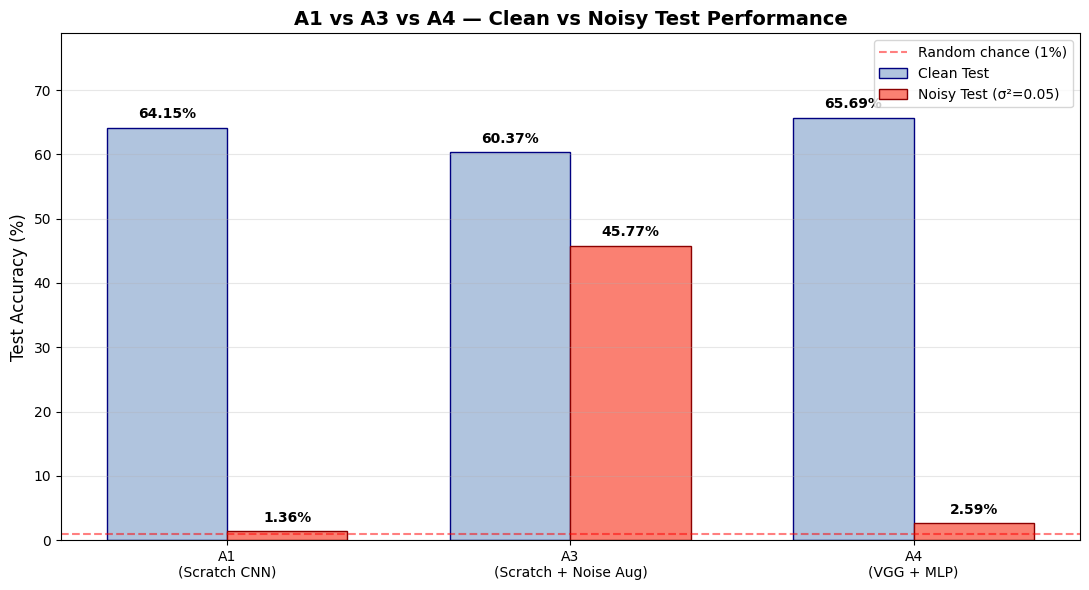


  ROBUSTNESS COMPARISON ACROSS ALL MODELS
Model                                 Clean      Noisy    Drop (pp)   Drop (%)
---------------------------------------------------------------------------
A1 (Scratch CNN)                     64.15%      1.36%       62.79     97.88%
A3 (Scratch + Noise Aug)             60.37%     45.77%       14.60     24.18%
A4 (VGG + MLP)                       65.69%      2.59%       63.10     96.06%
---------------------------------------------------------------------------
✓ Figure saved: a5_robustness_comparison.png


In [ ]:
# ============================================================
# QUESTION A5 — Step 4: Robustness Comparison Across All Models
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Collect all results
models_data = {
    'A1\n(Scratch CNN)':       {'clean': 64.15, 'noisy':  1.36, 'color': 'steelblue'},
    'A3\n(Scratch + Noise Aug)':{'clean': 60.37, 'noisy': 45.77, 'color': 'seagreen'},
    'A4\n(VGG + MLP)':          {'clean': mlp_test_acc, 'noisy': mlp_noisy_acc,
                                'color': 'darkorange'},
}

labels    = list(models_data.keys())
clean_acc = [m['clean'] for m in models_data.values()]
noisy_acc = [m['noisy'] for m in models_data.values()]
colors    = [m['color'] for m in models_data.values()]

# --- Figure: Grouped bar chart ---
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, clean_acc, width,
               label='Clean Test', color='lightsteelblue', edgecolor='navy')
bars2 = ax.bar(x + width/2, noisy_acc, width,
               label='Noisy Test (σ²=0.05)', color='salmon', edgecolor='darkred')

# Add value labels on top of bars
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 1.0,
                f'{h:.2f}%', ha='center', va='bottom',
                fontsize=10, fontweight='bold')

# Random chance line
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.5,
           label='Random chance (1%)')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('A1 vs A3 vs A4 — Clean vs Noisy Test Performance',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=10)
ax.set_ylim(0, max(clean_acc + noisy_acc) * 1.2)
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('a5_robustness_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Print numeric summary table ---
print(f"\n{'='*75}")
print(f"  ROBUSTNESS COMPARISON ACROSS ALL MODELS")
print(f"{'='*75}")
print(f"{'Model':<32} {'Clean':>10} {'Noisy':>10} {'Drop (pp)':>12} {'Drop (%)':>10}")
print(f"{'-'*75}")
for name, data in models_data.items():
    label_clean = name.replace('\n', ' ')
    drop_pp  = data['clean'] - data['noisy']
    drop_rel = drop_pp / data['clean'] * 100 if data['clean'] > 0 else 0
    print(f"{label_clean:<32} {data['clean']:>9.2f}% {data['noisy']:>9.2f}% "
          f"{drop_pp:>11.2f} {drop_rel:>9.2f}%")
print(f"{'-'*75}")
print('✓ Figure saved: a5_robustness_comparison.png')

## Step 5: Save Results and Download Files

In [ ]:
# ============================================================
# QUESTION A5 — Step 5: Save Results & Download
# ============================================================

a5_results = {
    'a1_clean_acc'       : 64.15,
    'a1_noisy_acc'       : 1.36,
    'a3_clean_acc'       : 60.37,
    'a3_noisy_acc'       : 45.77,
    'a4_clean_acc'       : mlp_test_acc,
    'a4_noisy_acc'       : mlp_noisy_acc,
    'a4_drop_abs'        : mlp_test_acc - mlp_noisy_acc,
    'a4_drop_rel_pct'    : (mlp_test_acc - mlp_noisy_acc) / mlp_test_acc * 100,
    'noise_variance'     : NOISE_VARIANCE,
    'noise_std'          : NOISE_STD,
    'noise_application'  : 'In [0,1] space, before resize and ImageNet normalize',
}

with open('a5_results.json', 'w') as f:
    json.dump(a5_results, f, indent=2)
print('✓ Results saved to a5_results.json')

# Backup to Drive
for fname in ['a5_robustness_comparison.png', 'a5_results.json',
              'vgg_noisy_test_feats.pt']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print('✓ All files backed up to Google Drive')

# Download for LaTeX report
from google.colab import files
files.download('a5_robustness_comparison.png')
files.download('a5_results.json')
print('✓ Files downloaded')

# Final summary
print(f"\n{'='*60}")
print(f"  QUESTION A5 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"  A4 Clean Test Accuracy : {mlp_test_acc:.2f}%")
print(f"  A4 Noisy Test Accuracy : {mlp_noisy_acc:.2f}%")
print(f"  Drop                   : {mlp_test_acc - mlp_noisy_acc:.2f} pp")
print(f"")
print(f"  Compare with A1 (scratch): clean 64.15% -> noisy 1.36% (drop ~63 pp)")
print(f"  Compare with A3 (robust) : clean 60.37% -> noisy 45.77% (drop ~15 pp)")
print(f"{'='*60}")
print("\n✅ Question A5 complete. Ready for A6 (final discussion).")

✓ Results saved to a5_results.json
✓ All files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded

  QUESTION A5 — FINAL SUMMARY
  A4 Clean Test Accuracy : 65.69%
  A4 Noisy Test Accuracy : 2.59%
  Drop                   : 63.10 pp

  Compare with A1 (scratch): clean 64.15% -> noisy 1.36% (drop ~63 pp)
  Compare with A3 (robust) : clean 60.37% -> noisy 45.77% (drop ~15 pp)

✅ Question A5 complete. Ready for A6 (final discussion).


# Question A6: Comprehensive Discussion

The complete analysis, comparison of all approaches (A1–A5), challenges faced,
and final conclusions are provided in the accompanying report document.

Please refer to the report for the detailed answer to this question.


# Part B: Recurrent Neural Networks (IMDB Sentiment Classification)

This part addresses binary sentiment classification on the IMDB Large Movie
Review Dataset using Recurrent Neural Networks (RNNs), Long Short-Term Memory
(LSTM) networks, and attention-augmented variants.

## Dataset

  Source       : Stanford NLP / Maas et al. 2011
  Size         : 50,000 movie reviews (25K train + 25K test)
  Task         : Binary classification (positive / negative)
  Reference    : https://ai.stanford.edu/~amaas/data/sentiment/

## Roadmap

- **B1:** Dataset description + text preprocessing
- **B2:** Vocabulary construction + 3 embedding methods (one-hot, Word2Vec, GloVe)
- **B3:** Vanilla RNN with L hidden layers, hidden dim h
- **B4:** Compare embeddings within RNN
- **B5:** Repeat B3+B4 with LSTM
- **B6:** Attention mechanism (implement or justify infeasibility)

# Question B1: Dataset & Text Preprocessing

This section describes the IMDB dataset portion used and the text
preprocessing pipeline that reduces vocabulary redundancy before
RNN training.

## Preprocessing Strategy

  1. HTML tag removal       — IMDB reviews contain '<br />' tags
  2. Lowercasing            — "The" and "the" treated as same token
  3. Punctuation removal    — keep only alphabetic characters
  4. Word tokenization      — split on whitespace
  5. Stop-word removal      — remove common low-information words
  6. Lemmatization (WordNet) — "running" → "run", "studies" → "study"

Lemmatization is preferred over stemming because it preserves grammatically
correct word forms, which is essential for downstream embedding lookup
(Word2Vec / GloVe both use full-word vocabularies).

## Pipeline (5 steps)

- **Step 1:** Install + download IMDB dataset
- **Step 2:** Define preprocessing function
- **Step 3:** Apply preprocessing to full dataset
- **Step 4:** Compute and visualize dataset statistics
- **Step 5:** Save processed data

## Step 1: Install Libraries and Download IMDB Dataset

We use the HuggingFace `datasets` library to download IMDB cleanly.
NLTK provides the lemmatizer and stop-word list.

In [ ]:
# ============================================================
# QUESTION B1 — Step 1: Install Libraries and Download IMDB
# ============================================================

# Install required libraries
!pip install --quiet datasets nltk

import nltk
import json, shutil, os

# Download NLTK data needed for preprocessing
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✓ NLTK data downloaded")

# Download IMDB via HuggingFace datasets
from datasets import load_dataset
print("\nDownloading IMDB dataset (~84 MB)...")
imdb = load_dataset('imdb')

train_texts = imdb['train']['text']
train_labels = imdb['train']['label']
test_texts  = imdb['test']['text']
test_labels = imdb['test']['label']

print(f"✓ IMDB loaded")
print(f"  Train samples : {len(train_texts):,}")
print(f"  Test samples  : {len(test_texts):,}")
print(f"  Labels        : 0 = negative, 1 = positive")
print(f"  Train balance : {sum(train_labels)} pos / {len(train_labels) - sum(train_labels)} neg")
print(f"  Test balance  : {sum(test_labels)} pos / {len(test_labels) - sum(test_labels)} neg")

# Show a sample review
print(f"\nSample review (label={train_labels[0]}):")
print(f"  {train_texts[0][:300]}...")

✓ NLTK data downloaded



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✓ IMDB loaded
  Train samples : 25,000
  Test samples  : 25,000
  Labels        : 0 = negative, 1 = positive
  Train balance : 12500 pos / 12500 neg
  Test balance  : 12500 pos / 12500 neg

Sample review (label=0):
  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h...


## Step 2: Define the Text Preprocessing Function

The preprocessing function performs all 6 steps in sequence and returns a
cleaned list of tokens for each review.

In [ ]:
# ============================================================
# QUESTION B1 — Step 2: Text Preprocessing Function
# ============================================================

import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Initialize tools
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Full preprocessing pipeline for IMDB reviews.

    Steps:
      1. Remove HTML tags (e.g., <br />)
      2. Lowercase
      3. Remove non-alphabetic characters (punctuation, digits, symbols)
      4. Tokenize on whitespace
      5. Remove stop-words
      6. Lemmatize each token

    Returns: list of cleaned tokens
    """
    # 1. Remove HTML tags
    text = re.sub(r'<[^>]+>', ' ', text)

    # 2. Lowercase
    text = text.lower()

    # 3. Keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Tokenize on whitespace (collapses multiple spaces)
    tokens = text.split()

    # 5. Remove stop-words AND words that are too short
    tokens = [w for w in tokens if w not in stop_words and len(w) > 2]

    # 6. Lemmatize
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    return tokens


# Test on a sample
sample_review = train_texts[0]
sample_tokens = preprocess_text(sample_review)

print(f"Original review (first 250 chars):")
print(f"  {sample_review[:250]}...")
print(f"\nProcessed tokens (first 30):")
print(f"  {sample_tokens[:30]}")
print(f"\nReview length: {len(sample_review.split())} raw words → "
      f"{len(sample_tokens)} cleaned tokens")

Original review (first 250 chars):
  I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a ...

Processed tokens (first 30):
  ['rented', 'curious', 'yellow', 'video', 'store', 'controversy', 'surrounded', 'first', 'released', 'also', 'heard', 'first', 'seized', 'custom', 'ever', 'tried', 'enter', 'country', 'therefore', 'fan', 'film', 'considered', 'controversial', 'really', 'see', 'plot', 'centered', 'around', 'young', 'swedish']

Review length: 288 raw words → 147 cleaned tokens


## Step 3: Apply Preprocessing to Full Dataset

Process all 50,000 reviews. This takes ~2-3 minutes (CPU-bound, single-threaded).

In [ ]:
# ============================================================
# QUESTION B1 — Step 3: Apply Preprocessing to Full Dataset
# ============================================================

import time

print("Preprocessing training set (25,000 reviews)...")
t0 = time.time()
train_tokens = [preprocess_text(text) for text in train_texts]
t1 = time.time()
print(f"  → done in {t1-t0:.1f}s")

print("Preprocessing test set (25,000 reviews)...")
test_tokens = [preprocess_text(text) for text in test_texts]
t2 = time.time()
print(f"  → done in {t2-t1:.1f}s")

print(f"\n✓ Total preprocessing time: {t2-t0:.1f}s")
print(f"  Train tokenized reviews : {len(train_tokens):,}")
print(f"  Test tokenized reviews  : {len(test_tokens):,}")

Preprocessing training set (25,000 reviews)...
  → done in 37.8s
Preprocessing test set (25,000 reviews)...
  → done in 26.8s

✓ Total preprocessing time: 64.7s
  Train tokenized reviews : 25,000
  Test tokenized reviews  : 25,000


## Step 4: Dataset Statistics and Visualization

Computes review-length statistics and the top-20 most frequent tokens
to inform the choice of sequence length and vocabulary size in B2.

Review length statistics (post-preprocessing):
  Train  | mean=118.0, median=87, min=4, max=1390, 95th percentile=307
  Test   | mean=115.2, median=86, min=3, max=1132, 95th percentile=298

Unique tokens in train set : 65,191
Total tokens in train set  : 2,949,819

Top 20 most frequent tokens:
  movie            51,714
  film             47,051
  one              27,748
  like             20,747
  time             15,965
  good             15,204
  character        14,183
  story            13,173
  even             12,656
  get              12,516
  would            12,436
  make             12,228
  see              12,016
  really           11,739
  well             10,789
  scene            10,596
  much              9,766
  people            9,387
  bad               9,309
  also              9,159


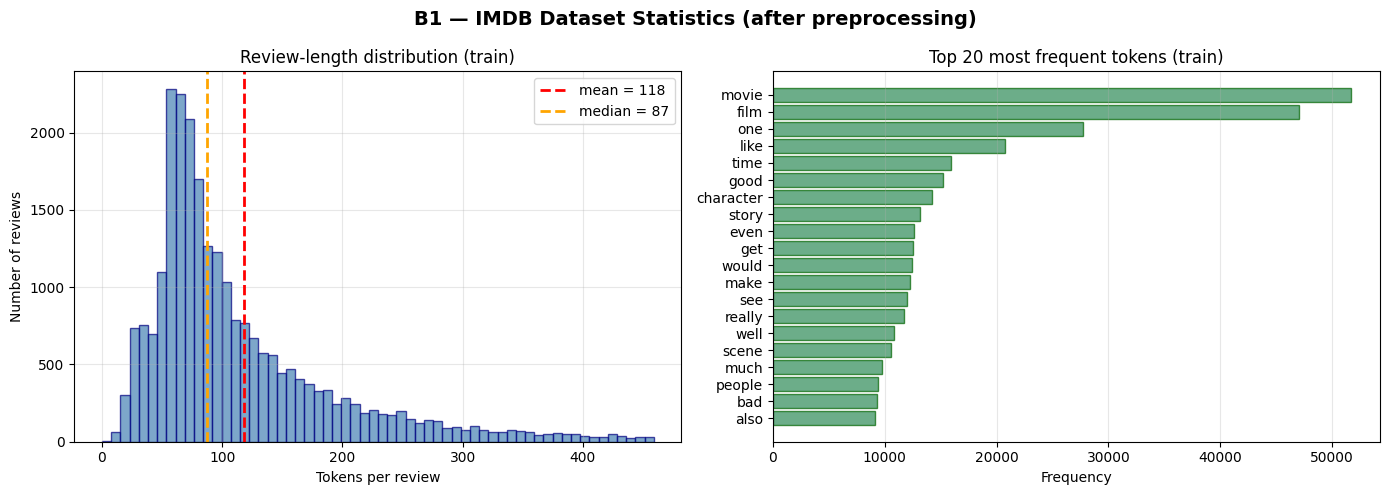

✓ Figure saved: b1_dataset_stats.png


In [ ]:
# ============================================================
# QUESTION B1 — Step 4: Dataset Statistics
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

# Review length statistics
train_lengths = [len(tokens) for tokens in train_tokens]
test_lengths  = [len(tokens) for tokens in test_tokens]

print("Review length statistics (post-preprocessing):")
print(f"  Train  | mean={np.mean(train_lengths):.1f}, "
      f"median={np.median(train_lengths):.0f}, "
      f"min={np.min(train_lengths)}, max={np.max(train_lengths)}, "
      f"95th percentile={np.percentile(train_lengths, 95):.0f}")
print(f"  Test   | mean={np.mean(test_lengths):.1f}, "
      f"median={np.median(test_lengths):.0f}, "
      f"min={np.min(test_lengths)}, max={np.max(test_lengths)}, "
      f"95th percentile={np.percentile(test_lengths, 95):.0f}")

# Top tokens
all_train_tokens = [tok for review in train_tokens for tok in review]
token_counts = Counter(all_train_tokens)
print(f"\nUnique tokens in train set : {len(token_counts):,}")
print(f"Total tokens in train set  : {len(all_train_tokens):,}")

print(f"\nTop 20 most frequent tokens:")
for tok, count in token_counts.most_common(20):
    print(f"  {tok:<15} {count:>7,}")

# Visualization: review length distribution + top tokens
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('B1 — IMDB Dataset Statistics (after preprocessing)',
             fontsize=14, fontweight='bold')

# Left: review length histogram (clip at 95th percentile for readability)
clip = int(np.percentile(train_lengths, 99))
axes[0].hist(train_lengths, bins=60, range=(0, clip),
             color='steelblue', edgecolor='navy', alpha=0.7)
axes[0].axvline(np.mean(train_lengths), color='red', linestyle='--',
                linewidth=2, label=f'mean = {np.mean(train_lengths):.0f}')
axes[0].axvline(np.median(train_lengths), color='orange', linestyle='--',
                linewidth=2, label=f'median = {np.median(train_lengths):.0f}')
axes[0].set_xlabel('Tokens per review')
axes[0].set_ylabel('Number of reviews')
axes[0].set_title('Review-length distribution (train)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: top 20 token bar chart
top20 = token_counts.most_common(20)
top_words, top_freqs = zip(*top20)
axes[1].barh(top_words[::-1], top_freqs[::-1],
             color='seagreen', edgecolor='darkgreen', alpha=0.7)
axes[1].set_xlabel('Frequency')
axes[1].set_title('Top 20 most frequent tokens (train)')
axes[1].grid(True, axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('b1_dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: b1_dataset_stats.png')

## Step 5: Save Processed Data and Download Files

Saves tokenized reviews + metadata to disk for use in B2 (vocabulary
building) and beyond.

In [ ]:
# ============================================================
# QUESTION B1 — Step 5: Save Processed Data
# ============================================================
# This cell is fully self-contained:
#   - Imports all required libraries
#   - Mounts Google Drive (if not already mounted)
#   - Computes any missing stats (works even after session restart)
#   - Saves files locally
#   - Backs up to Drive
#   - Downloads files for the LaTeX report
#   - Prints final summary
#
# Required prior state in memory:
#   train_tokens, train_labels, test_tokens, test_labels
#   (these come from Step 3 and don't need to be recomputed if rerun)
# ============================================================

import os
import json
import pickle
import shutil
import numpy as np
from collections import Counter

# ── 1. Ensure Google Drive is mounted ──────────────────────
if not os.path.exists('/content/drive/MyDrive'):
    print("Mounting Google Drive...")
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("✓ Google Drive already mounted")

# ── 2. Recompute statistics if not in memory ──────────────
# (Defensive: works even if you run this cell after a kernel restart
#  followed by re-running only earlier cells)
try:
    _ = train_lengths       # check if already computed
    _ = all_train_tokens
    _ = token_counts
    print("✓ Using cached statistics from earlier cells")
except NameError:
    print("Recomputing statistics from train_tokens...")
    train_lengths    = [len(toks) for toks in train_tokens]
    all_train_tokens = [tok for review in train_tokens for tok in review]
    token_counts     = Counter(all_train_tokens)
    print("✓ Statistics recomputed")

# ── 3. Save tokenized data as pickle ──────────────────────
processed_data = {
    'train_tokens' : train_tokens,
    'train_labels' : train_labels,
    'test_tokens'  : test_tokens,
    'test_labels'  : test_labels,
}

with open('imdb_processed.pkl', 'wb') as f:
    pickle.dump(processed_data, f)
size_mb = os.path.getsize('imdb_processed.pkl') / 1e6
print(f"✓ imdb_processed.pkl saved ({size_mb:.1f} MB)")

# ── 4. Save B1 statistics as JSON for the LaTeX report ────
b1_stats = {
    'num_train_reviews'    : len(train_tokens),
    'num_test_reviews'     : len(test_tokens),
    'unique_train_tokens'  : len(token_counts),
    'total_train_tokens'   : len(all_train_tokens),
    'mean_review_length'   : float(np.mean(train_lengths)),
    'median_review_length' : float(np.median(train_lengths)),
    'percentile_95_length' : float(np.percentile(train_lengths, 95)),
    'min_review_length'    : int(np.min(train_lengths)),
    'max_review_length'    : int(np.max(train_lengths)),
    'preprocessing_steps'  : [
        'HTML tag removal',
        'Lowercasing',
        'Non-alphabetic removal',
        'Whitespace tokenization',
        'Stop-word removal',
        'Lemmatization (WordNet)'
    ],
    'top_20_tokens'        : [(t, c) for t, c in token_counts.most_common(20)],
}

with open('b1_stats.json', 'w') as f:
    json.dump(b1_stats, f, indent=2)
print(f"✓ b1_stats.json saved")

# ── 5. Verify b1_dataset_stats.png exists (from Step 4) ───
if not os.path.exists('b1_dataset_stats.png'):
    print("⚠ b1_dataset_stats.png not found — please re-run Step 4 first")
else:
    print(f"✓ b1_dataset_stats.png exists "
          f"({os.path.getsize('b1_dataset_stats.png')/1e6:.2f} MB)")

# ── 6. Backup all files to Google Drive ───────────────────
files_to_backup = ['imdb_processed.pkl', 'b1_stats.json', 'b1_dataset_stats.png']
for fname in files_to_backup:
    if os.path.exists(fname):
        shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print(f"✓ All B1 files backed up to Google Drive")

# ── 7. Download files for the LaTeX report ────────────────
try:
    from google.colab import files
    files.download('b1_dataset_stats.png')
    files.download('b1_stats.json')
    print(f"✓ Files downloaded for LaTeX report")
except ImportError:
    print("ℹ Not running in Colab — skipping browser download "
          "(files saved locally and on Drive)")

# ── 8. Print final summary ────────────────────────────────
print(f"\n{'='*60}")
print(f"  QUESTION B1 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"  Dataset           : IMDB (Stanford), 25K train + 25K test")
print(f"  Preprocessing     : 6 steps (HTML, lowercase, alpha, tokenize,")
print(f"                      stop-words, lemmatization)")
print(f"  Unique tokens     : {b1_stats['unique_train_tokens']:,}")
print(f"  Mean length       : {b1_stats['mean_review_length']:.1f} tokens/review")
print(f"  Median length     : {b1_stats['median_review_length']:.0f} tokens/review")
print(f"  95th percentile   : {b1_stats['percentile_95_length']:.0f} tokens/review")
print(f"  Files saved       : imdb_processed.pkl, b1_stats.json,")
print(f"                      b1_dataset_stats.png")
print(f"{'='*60}")
print("\n✅ Question B1 complete. Ready for B2.")

✓ Google Drive already mounted
✓ Using cached statistics from earlier cells
✓ imdb_processed.pkl saved (51.7 MB)
✓ b1_stats.json saved
✓ b1_dataset_stats.png exists (0.10 MB)
✓ All B1 files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded for LaTeX report

  QUESTION B1 — FINAL SUMMARY
  Dataset           : IMDB (Stanford), 25K train + 25K test
  Preprocessing     : 6 steps (HTML, lowercase, alpha, tokenize,
                      stop-words, lemmatization)
  Unique tokens     : 65,191
  Mean length       : 118.0 tokens/review
  Median length     : 87 tokens/review
  95th percentile   : 307 tokens/review
  Files saved       : imdb_processed.pkl, b1_stats.json,
                      b1_dataset_stats.png

✅ Question B1 complete. Ready for B2.


# Question B2: Vocabulary Construction & Embedding Methods

This section builds an integer-indexed vocabulary from the preprocessed
IMDB tokens and constructs three different vector representations for
each token: one-hot encoding, pre-trained Word2Vec, and pre-trained GloVe.

## Design Choices

  Vocabulary size  : 20,000 tokens (top frequent + 2 special tokens)
  Sequence length  : 256 tokens (covers ~92% of reviews fully)
  Special tokens   : <PAD> (index 0), <UNK> (index 1)
  One-hot dim      : 20,000  (= vocab size)
  Word2Vec dim     : 300  (Google News pre-trained)
  GloVe dim        : 100  (glove.6B.100d, Wikipedia + Gigaword)

## Pipeline (8 steps)

- **Step 1:** Build vocabulary (top 20K tokens + special tokens)
- **Step 2:** Convert reviews → integer index sequences
- **Step 3:** Pad / truncate to length 256
- **Step 4:** Define one-hot encoding helper
- **Step 5:** Download Word2Vec embeddings (~1.7 GB compressed, ~3.6 GB expanded)
- **Step 6:** Download GloVe embeddings (~330 MB)
- **Step 7:** Build embedding matrices (vocab → vector lookup)
- **Step 8:** Save everything for B3 reuse

## Step 1: Build Vocabulary from Training Tokens

Construct a token-to-index mapping using the top 20,000 most frequent
tokens from the preprocessed training set. Two special tokens are reserved:

  <PAD> at index 0  — padding for short reviews
  <UNK> at index 1  — unknown / out-of-vocabulary tokens

In [ ]:
# ============================================================
# QUESTION B2 — Step 1: Build Vocabulary
# ============================================================

import os
import pickle
from collections import Counter

# Self-contained: load processed data if not already in memory
try:
    _ = train_tokens
    _ = test_tokens
    print("✓ Using train_tokens / test_tokens already in memory")
except NameError:
    print("Loading processed data from imdb_processed.pkl...")
    with open('imdb_processed.pkl', 'rb') as f:
        data = pickle.load(f)
    train_tokens = data['train_tokens']
    train_labels = data['train_labels']
    test_tokens  = data['test_tokens']
    test_labels  = data['test_labels']
    print(f"✓ Loaded: train={len(train_tokens):,}, test={len(test_tokens):,}")

# Hyperparameters
VOCAB_SIZE     = 20000     # top-K frequent tokens + special tokens
SEQ_LENGTH     = 256       # ~92% coverage based on B1 stats
PAD_TOKEN      = '<PAD>'
UNK_TOKEN      = '<UNK>'
PAD_IDX        = 0
UNK_IDX        = 1

# Count token frequencies on training set
print("\nCounting token frequencies in training set...")
all_train_tokens_flat = [tok for review in train_tokens for tok in review]
token_counts = Counter(all_train_tokens_flat)
print(f"  Total tokens     : {len(all_train_tokens_flat):,}")
print(f"  Unique tokens    : {len(token_counts):,}")

# Build vocabulary: special tokens + top-K most frequent
top_k_tokens = token_counts.most_common(VOCAB_SIZE - 2)  # leave room for 2 special tokens

word2idx = {PAD_TOKEN: PAD_IDX, UNK_TOKEN: UNK_IDX}
for word, _ in top_k_tokens:
    word2idx[word] = len(word2idx)

idx2word = {idx: word for word, idx in word2idx.items()}

print(f"\n✓ Vocabulary built")
print(f"  Vocab size       : {len(word2idx):,}")
print(f"  Coverage of train: {sum(c for w, c in top_k_tokens) / len(all_train_tokens_flat) * 100:.2f}%")
print(f"  Special tokens   : {PAD_TOKEN} (idx {PAD_IDX}), {UNK_TOKEN} (idx {UNK_IDX})")
print(f"\n  Sample mappings:")
for word in ['movie', 'film', 'good', 'bad', 'character']:
    if word in word2idx:
        print(f"    {word:12s} → {word2idx[word]}")

✓ Using train_tokens / test_tokens already in memory

Counting token frequencies in training set...
  Total tokens     : 2,949,819
  Unique tokens    : 65,191

✓ Vocabulary built
  Vocab size       : 20,000
  Coverage of train: 96.71%
  Special tokens   : <PAD> (idx 0), <UNK> (idx 1)

  Sample mappings:
    movie        → 2
    film         → 3
    good         → 7
    bad          → 20
    character    → 8


## Step 2: Convert Reviews to Integer Index Sequences

Maps each token in every review to its integer index from the vocabulary.
Tokens not in the vocabulary (i.e., infrequent ones not in the top 20K)
are mapped to `<UNK>` (index 1).

In [ ]:
# ============================================================
# QUESTION B2 — Step 2: Tokens → Integer Indices
# ============================================================

def tokens_to_indices(token_list, word2idx, unk_idx=UNK_IDX):
    """Map a list of tokens to their integer indices, using UNK for OOV."""
    return [word2idx.get(tok, unk_idx) for tok in token_list]

# Convert all reviews
print("Converting tokens to indices...")
train_indices = [tokens_to_indices(review, word2idx) for review in train_tokens]
test_indices  = [tokens_to_indices(review, word2idx) for review in test_tokens]

# Compute UNK rate (% of tokens that became <UNK>)
total_train_tokens_count = sum(len(r) for r in train_indices)
unk_count = sum(idx == UNK_IDX for review in train_indices for idx in review)
unk_rate = unk_count / total_train_tokens_count * 100

print(f"✓ All reviews converted to integer index sequences")
print(f"  Train: {len(train_indices):,} reviews")
print(f"  Test : {len(test_indices):,} reviews")
print(f"  UNK rate (train): {unk_rate:.2f}% of tokens are <UNK>")
print(f"\nExample (first 20 indices of train review 0):")
print(f"  Tokens : {train_tokens[0][:20]}")
print(f"  Indices: {train_indices[0][:20]}")

Converting tokens to indices...
✓ All reviews converted to integer index sequences
  Train: 25,000 reviews
  Test : 25,000 reviews
  UNK rate (train): 3.29% of tokens are <UNK>

Example (first 20 indices of train review 0):
  Tokens : ['rented', 'curious', 'yellow', 'video', 'store', 'controversy', 'surrounded', 'first', 'released', 'also', 'heard', 'first', 'seized', 'custom', 'ever', 'tried', 'enter', 'country', 'therefore', 'fan']
  Indices: [1409, 1773, 3531, 241, 844, 5809, 3039, 23, 498, 21, 428, 23, 16725, 5975, 48, 645, 2267, 441, 1419, 108]


## Step 3: Pad / Truncate to Fixed Sequence Length

RNN training requires fixed-length sequences for batching. We:
  - Truncate reviews longer than `SEQ_LENGTH` (256) to that length
  - Pad reviews shorter than `SEQ_LENGTH` with `<PAD>` (idx 0)

In [ ]:
# ============================================================
# QUESTION B2 — Step 3: Pad/Truncate to Fixed Length
# ============================================================

import numpy as np

def pad_sequence(idx_seq, max_len=SEQ_LENGTH, pad_idx=PAD_IDX):
    """Truncate or pad an index sequence to exactly max_len tokens."""
    if len(idx_seq) >= max_len:
        return idx_seq[:max_len]
    else:
        return idx_seq + [pad_idx] * (max_len - len(idx_seq))

# Apply to all sequences and convert to numpy arrays
print(f"Padding/truncating all sequences to length {SEQ_LENGTH}...")
train_padded = np.array([pad_sequence(s) for s in train_indices], dtype=np.int64)
test_padded  = np.array([pad_sequence(s) for s in test_indices],  dtype=np.int64)

print(f"✓ Padding complete")
print(f"  Train shape : {train_padded.shape}  (dtype={train_padded.dtype})")
print(f"  Test shape  : {test_padded.shape}")
print(f"\n  Memory usage:")
print(f"    Train: {train_padded.nbytes / 1e6:.1f} MB")
print(f"    Test : {test_padded.nbytes / 1e6:.1f} MB")
print(f"\n  Coverage check:")
print(f"    {sum(1 for s in train_indices if len(s) <= SEQ_LENGTH) / len(train_indices) * 100:.2f}% "
      f"of train reviews fit fully within {SEQ_LENGTH} tokens "
      f"(rest are truncated)")

Padding/truncating all sequences to length 256...
✓ Padding complete
  Train shape : (25000, 256)  (dtype=int64)
  Test shape  : (25000, 256)

  Memory usage:
    Train: 51.2 MB
    Test : 51.2 MB

  Coverage check:
    91.99% of train reviews fit fully within 256 tokens (rest are truncated)


## Step 4: One-Hot Encoding Helper

One-hot encoding represents each token as a sparse vector of length V
(vocabulary size), with a single 1 at the token's index and 0s elsewhere.

⚠ **Note on memory:** Storing one-hot vectors for an entire dataset is
prohibitive (50K reviews × 256 tokens × 20K dims × 4 bytes ≈ 1 TB).
Instead, we define a helper function that builds an **identity matrix**
embedding layer at training time — this is mathematically equivalent
to one-hot encoding but uses standard `nn.Embedding` lookup.

In [ ]:
# ============================================================
# QUESTION B2 — Step 4: One-Hot Encoding Helper
# ============================================================

import torch
import torch.nn as nn

def build_onehot_embedding(vocab_size=VOCAB_SIZE):
    """
    Construct an embedding layer equivalent to one-hot encoding:
      - Each token's vector is the one-hot indicator vector of dim vocab_size.
      - Implemented as nn.Embedding initialized with the identity matrix,
        with weights frozen (no gradient updates).
    """
    onehot_emb = nn.Embedding(vocab_size, vocab_size)
    onehot_emb.weight.data = torch.eye(vocab_size)         # identity matrix
    onehot_emb.weight.requires_grad = False                # freeze weights
    return onehot_emb

# Sanity check
onehot_layer = build_onehot_embedding(vocab_size=VOCAB_SIZE)
sample_idx   = torch.tensor([5, 100, 1])  # arbitrary token indices
sample_vecs  = onehot_layer(sample_idx)

print(f"✓ One-hot embedding helper defined")
print(f"  Vocab size       : {VOCAB_SIZE:,}")
print(f"  Vector dimension : {VOCAB_SIZE:,} (= one-hot)")
print(f"  Sample input idxs : {sample_idx.tolist()}")
print(f"  Sample output shape: {sample_vecs.shape}")
print(f"  Sample sum (each row should be exactly 1): "
      f"{sample_vecs.sum(dim=1).tolist()}")
print(f"  Frozen (no gradient): {not onehot_layer.weight.requires_grad}")

✓ One-hot embedding helper defined
  Vocab size       : 20,000
  Vector dimension : 20,000 (= one-hot)
  Sample input idxs : [5, 100, 1]
  Sample output shape: torch.Size([3, 20000])
  Sample sum (each row should be exactly 1): [1.0, 1.0, 1.0]
  Frozen (no gradient): True


## Step 5: Download Word2Vec Embeddings

Word2Vec (Mikolov et al., 2013) provides 300-dimensional dense word
vectors trained on the Google News corpus (~100 billion words).
We use `gensim` to download and load the pre-trained model.

⏰ **Note:** This download is ~1.7 GB compressed (~3.6 GB expanded).
Takes 2–4 minutes depending on connection speed.

In [ ]:
# ============================================================
# QUESTION B2 — Step 5: Download Word2Vec
# ============================================================

# Install gensim quietly if not already available
!pip install --quiet gensim

import gensim.downloader as gensim_dl
import time

print("Downloading Word2Vec (Google News, 300d) — ~1.7 GB compressed...")
print("This takes 2-4 minutes. Do not interrupt.")
t0 = time.time()
w2v_model = gensim_dl.load('word2vec-google-news-300')
t_elapsed = time.time() - t0

W2V_DIM = w2v_model.vector_size
print(f"\n✓ Word2Vec loaded in {t_elapsed/60:.1f} min")
print(f"  Vector dim         : {W2V_DIM}")
print(f"  Vocabulary in W2V  : {len(w2v_model):,}")
print(f"  Sample 'movie'[:5] : {w2v_model['movie'][:5]}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 19.4 MB/s eta 0:00:00
This takes 2-4 minutes. Do not interrupt.
[==================================================] 100.0% 1662.8/1662.8MB downloaded

✓ Word2Vec loaded in 5.2 min
  Vector dim         : 300
  Vocabulary in W2V  : 3,000,000
  Sample 'movie'[:5] : [ 0.17480469 -0.10986328 -0.20019531  0.26757812 -0.06396484]


## Step 6: Download GloVe Embeddings

GloVe (Pennington et al., 2014) provides dense word vectors trained on
Wikipedia + Gigaword (~6 billion tokens). We use the 100-dimensional
variant (`glove.6B.100d`) for efficiency.

⏰ **Note:** This download is ~330 MB. Takes 30 seconds–1 minute.

In [ ]:
# ============================================================
# QUESTION B2 — Step 6: Download GloVe
# ============================================================

print("Downloading GloVe (Wikipedia+Gigaword, 100d) — ~330 MB...")
print("This takes 30 seconds to 1 minute.")
t0 = time.time()
glove_model = gensim_dl.load('glove-wiki-gigaword-100')
t_elapsed = time.time() - t0

GLOVE_DIM = glove_model.vector_size
print(f"\n✓ GloVe loaded in {t_elapsed:.1f} s")
print(f"  Vector dim         : {GLOVE_DIM}")
print(f"  Vocabulary in GloVe: {len(glove_model):,}")
print(f"  Sample 'movie'[:5] : {glove_model['movie'][:5]}")

This takes 30 seconds to 1 minute.
[==================================================] 100.0% 128.1/128.1MB downloaded

✓ GloVe loaded in 139.4 s
  Vector dim         : 100
  Vocabulary in GloVe: 400,000
  Sample 'movie'[:5] : [ 0.38251  0.14821  0.60601 -0.51533  0.43992]


## Step 7: Build Embedding Matrices for Our Vocabulary

For Word2Vec and GloVe, we build a `(vocab_size × embedding_dim)`
matrix where row `i` = the pre-trained vector for token at index `i`.
For OOV tokens (those not in the pre-trained vocab), we use:
  - `<PAD>` (idx 0)  → all zeros
  - `<UNK>` (idx 1)  → mean of all pre-trained vectors
  - other OOV         → small random Gaussian (mean=0, std=0.1)

This is the standard approach for handling vocabulary mismatch.

In [ ]:
# ============================================================
# QUESTION B2 — Step 7: Build Embedding Matrices
# ============================================================

def build_embedding_matrix(pretrained, dim, vocab):
    """
    Build a (vocab_size, dim) embedding matrix where row i is the
    pre-trained vector for vocab[i] if available, else a fallback.

    Special tokens:
      vocab[0] = <PAD>  → zeros
      vocab[1] = <UNK>  → mean of all pretrained vectors
    All other OOV     → small random Gaussian
    """
    np.random.seed(42)  # reproducibility
    matrix = np.zeros((len(vocab), dim), dtype=np.float32)

    # <PAD> = zeros (already initialized)

    # <UNK> = mean of pre-trained vectors
    pretrained_mean = np.mean(np.stack([pretrained[w] for w in pretrained.index_to_key[:1000]]),
                               axis=0)
    matrix[UNK_IDX] = pretrained_mean

    # Other vocab words
    found, missing = 0, 0
    for word, idx in vocab.items():
        if idx <= UNK_IDX:
            continue
        if word in pretrained:
            matrix[idx] = pretrained[word]
            found += 1
        else:
            matrix[idx] = np.random.normal(0, 0.1, dim).astype(np.float32)
            missing += 1
    return matrix, found, missing

# Build Word2Vec matrix
print("Building Word2Vec embedding matrix...")
w2v_matrix, w2v_found, w2v_missing = build_embedding_matrix(
    w2v_model, W2V_DIM, word2idx
)
print(f"  Shape    : {w2v_matrix.shape}")
print(f"  Coverage : {w2v_found:,} found / {w2v_missing:,} missing "
      f"({w2v_found / (w2v_found + w2v_missing) * 100:.2f}%)")

# Build GloVe matrix
print("\nBuilding GloVe embedding matrix...")
glove_matrix, glove_found, glove_missing = build_embedding_matrix(
    glove_model, GLOVE_DIM, word2idx
)
print(f"  Shape    : {glove_matrix.shape}")
print(f"  Coverage : {glove_found:,} found / {glove_missing:,} missing "
      f"({glove_found / (glove_found + glove_missing) * 100:.2f}%)")

print(f"\n✓ Embedding matrices ready")
print(f"  One-hot  : (lazy) {VOCAB_SIZE} × {VOCAB_SIZE} identity")
print(f"  Word2Vec : {w2v_matrix.shape}, mean={w2v_matrix.mean():.4f}, std={w2v_matrix.std():.4f}")
print(f"  GloVe    : {glove_matrix.shape}, mean={glove_matrix.mean():.4f}, std={glove_matrix.std():.4f}")

Building Word2Vec embedding matrix...
  Shape    : (20000, 300)
  Coverage : 17,406 found / 2,592 missing (87.04%)

Building GloVe embedding matrix...
  Shape    : (20000, 100)
  Coverage : 19,776 found / 222 missing (98.89%)

✓ Embedding matrices ready
  One-hot  : (lazy) 20000 × 20000 identity
  Word2Vec : (20000, 300), mean=-0.0018, std=0.1681
  GloVe    : (20000, 100), mean=-0.0003, std=0.4918


## Step 8: Save Vocabulary, Padded Sequences, and Embedding Matrices

Saves all B2 outputs as pickle/npz files for reuse in B3 (vanilla RNN),
B4 (RNN with multiple embeddings), B5 (LSTM), and B6 (attention).

In [ ]:
# ============================================================
# QUESTION B2 — Step 8: Save Everything for B3+
# ============================================================

import json
import shutil
from google.colab import files

# Ensure Drive is mounted
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')

# Save vocabulary + padded sequences
b2_vocab_data = {
    'word2idx'    : word2idx,
    'idx2word'    : idx2word,
    'train_padded': train_padded,
    'test_padded' : test_padded,
    'train_labels': train_labels,
    'test_labels' : test_labels,
    'vocab_size'  : VOCAB_SIZE,
    'seq_length'  : SEQ_LENGTH,
}
with open('b2_vocab_data.pkl', 'wb') as f:
    pickle.dump(b2_vocab_data, f)
print(f"✓ b2_vocab_data.pkl saved "
      f"({os.path.getsize('b2_vocab_data.pkl')/1e6:.1f} MB)")

# Save embedding matrices as compressed numpy
np.savez_compressed(
    'b2_embeddings.npz',
    w2v_matrix=w2v_matrix,
    glove_matrix=glove_matrix
)
print(f"✓ b2_embeddings.npz saved "
      f"({os.path.getsize('b2_embeddings.npz')/1e6:.1f} MB)")

# Save B2 stats / summary
b2_stats = {
    'vocab_size'        : VOCAB_SIZE,
    'seq_length'        : SEQ_LENGTH,
    'special_tokens'    : {'<PAD>': PAD_IDX, '<UNK>': UNK_IDX},
    'unk_rate_train_pct': float(unk_rate),
    'embeddings': {
        'one_hot' : {'dim': VOCAB_SIZE,  'pretrained': False, 'frozen': True},
        'word2vec': {'dim': W2V_DIM,
                     'pretrained': True,
                     'source': 'Google News 300d',
                     'coverage_pct': w2v_found / (w2v_found + w2v_missing) * 100,
                     'found': w2v_found,
                     'missing': w2v_missing},
        'glove'   : {'dim': GLOVE_DIM,
                     'pretrained': True,
                     'source': 'Wikipedia+Gigaword 100d',
                     'coverage_pct': glove_found / (glove_found + glove_missing) * 100,
                     'found': glove_found,
                     'missing': glove_missing},
    },
}
with open('b2_stats.json', 'w') as f:
    json.dump(b2_stats, f, indent=2)
print(f"✓ b2_stats.json saved")

# Backup to Drive
for fname in ['b2_vocab_data.pkl', 'b2_embeddings.npz', 'b2_stats.json']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print(f"✓ All B2 files backed up to Google Drive")

# Download summary file for LaTeX (the .pkl and .npz are too big)
files.download('b2_stats.json')
print(f"✓ b2_stats.json downloaded for LaTeX report")

# Final summary
print(f"\n{'='*65}")
print(f"  QUESTION B2 — FINAL SUMMARY")
print(f"{'='*65}")
print(f"  Vocabulary size         : {VOCAB_SIZE:,}")
print(f"  Sequence length         : {SEQ_LENGTH}")
print(f"  Special tokens          : <PAD> (0), <UNK> (1)")
print(f"  UNK rate in train       : {unk_rate:.2f}%")
print(f"")
print(f"  Embedding methods:")
print(f"    1. One-hot            : dim {VOCAB_SIZE:,}, frozen identity")
print(f"    2. Word2Vec (Google)  : dim {W2V_DIM},   coverage {w2v_found/(w2v_found+w2v_missing)*100:.2f}%")
print(f"    3. GloVe (Wiki+Giga)  : dim {GLOVE_DIM},   coverage {glove_found/(glove_found+glove_missing)*100:.2f}%")
print(f"")
print(f"  Padded sequences:")
print(f"    Train shape           : {train_padded.shape}")
print(f"    Test shape            : {test_padded.shape}")
print(f"{'='*65}")
print("\n✅ Question B2 complete. Ready for B3.")

✓ b2_vocab_data.pkl saved (102.8 MB)
✓ b2_embeddings.npz saved (20.6 MB)
✓ b2_stats.json saved
✓ All B2 files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ b2_stats.json downloaded for LaTeX report

  QUESTION B2 — FINAL SUMMARY
  Vocabulary size         : 20,000
  Sequence length         : 256
  Special tokens          : <PAD> (0), <UNK> (1)
  UNK rate in train       : 3.29%

  Embedding methods:
    1. One-hot            : dim 20,000, frozen identity
    2. Word2Vec (Google)  : dim 300,   coverage 87.04%
    3. GloVe (Wiki+Giga)  : dim 100,   coverage 98.89%

  Padded sequences:
    Train shape           : (25000, 256)
    Test shape            : (25000, 256)

✅ Question B2 complete. Ready for B3.


---

## 🔧 B3 Setup: GPU Switch + Reload B2 Data (Optional Recovery Cell)

This cell verifies GPU availability and reloads the B1+B2 outputs
(vocabulary, padded sequences, embedding matrices) from Google Drive.
It is **not** part of the B3 solution itself — it exists purely to
protect against Colab session disconnections.

**Run this only if** you switched to GPU runtime or reopened the
notebook in a fresh session. After running, all variables needed
for B3 (`device`, `train_padded`, `w2v_matrix`, etc.) are restored.

---

In [ ]:
# 3. Restore B2 files from Drive if missing locally
import shutil
for fname in ['b2_vocab_data.pkl', 'b2_embeddings.npz']:
    if not os.path.exists(fname):
        shutil.copy(f'/content/drive/MyDrive/{fname}', fname)
        print(f"✓ Restored {fname} from Drive")
    else:
        print(f"✓ {fname} present locally")

# ▼▼▼ ADD THIS BLOCK HERE ▼▼▼
# 3b. Re-hydrate HuggingFace cache so the pickled Dataset can map its arrow file
from datasets import load_dataset
print("Re-downloading IMDB to repopulate HF cache...")
_raw = load_dataset("imdb")
print("✓ HF cache ready")
# ▲▲▲ END OF NEW BLOCK ▲▲▲

# 4. Load B2 vocabulary and padded sequences
with open('b2_vocab_data.pkl', 'rb') as f:
    b2_data = pickle.load(f)

✓ b2_vocab_data.pkl present locally
✓ b2_embeddings.npz present locally
Re-downloading IMDB to repopulate HF cache...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✓ HF cache ready


In [ ]:
# ============================================================
# B3 SETUP — Recover B1+B2 environment on GPU runtime
# ============================================================

import torch
import os
import pickle
import numpy as np

# 1. Verify GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")

# 2. Mount Drive
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
print("✓ Drive mounted")

# 3. Restore B2 files from Drive if missing locally
import shutil
for fname in ['b2_vocab_data.pkl', 'b2_embeddings.npz']:
    if not os.path.exists(fname):
        shutil.copy(f'/content/drive/MyDrive/{fname}', fname)
        print(f"✓ Restored {fname} from Drive")
    else:
        print(f"✓ {fname} present locally")

# 4. Load B2 vocabulary and padded sequences
with open('b2_vocab_data.pkl', 'rb') as f:
    b2_data = pickle.load(f)

word2idx     = b2_data['word2idx']
idx2word     = b2_data['idx2word']
train_padded = b2_data['train_padded']
test_padded  = b2_data['test_padded']
train_labels = b2_data['train_labels']
test_labels  = b2_data['test_labels']
VOCAB_SIZE   = b2_data['vocab_size']
SEQ_LENGTH   = b2_data['seq_length']

# 5. Load embedding matrices
emb_data     = np.load('b2_embeddings.npz')
w2v_matrix   = emb_data['w2v_matrix']
glove_matrix = emb_data['glove_matrix']

# 6. Restore special token indices
PAD_IDX = 0
UNK_IDX = 1

print(f"\n✓ All B2 data loaded:")
print(f"  Vocab size       : {VOCAB_SIZE:,}")
print(f"  Sequence length  : {SEQ_LENGTH}")
print(f"  Train shape      : {train_padded.shape}")
print(f"  Test shape       : {test_padded.shape}")
print(f"  W2V shape        : {w2v_matrix.shape}")
print(f"  GloVe shape      : {glove_matrix.shape}")
print(f"\n✅ Ready for B3 (RNN training)")

✓ Device: cpu
✓ Drive mounted
✓ b2_vocab_data.pkl present locally
✓ b2_embeddings.npz present locally

✓ All B2 data loaded:
  Vocab size       : 20,000
  Sequence length  : 256
  Train shape      : (25000, 256)
  Test shape       : (25000, 256)
  W2V shape        : (20000, 300)
  GloVe shape      : (20000, 100)

✅ Ready for B3 (RNN training)


# Question B3: Vanilla RNN for Sentiment Classification

This section trains a vanilla Recurrent Neural Network (RNN) on the
preprocessed IMDB data for binary sentiment classification.

## Architecture (L = 1 hidden layer, h = 128 hidden units)

  Input:    Token indices  (batch, 256)
    ↓ Embedding(20000 → 128)        — trainable, 128-dim
  Sequence: Word vectors    (batch, 256, 128)
    ↓ RNN(input=128, hidden=128, num_layers=1, nonlinearity=tanh)
  Last hidden: (batch, 128)
    ↓ Dropout(0.5)
    ↓ Linear(128 → 2)
  Output:   Class logits   (batch, 2)

## Hyperparameter Justification

  L = 1 (single layer)  : Vanilla RNNs suffer from vanishing gradients;
                          deeper stacks compound the problem
  h = 128               : Standard for sentiment; large enough to capture
                          informative features, small enough to train fast
  Embedding dim = 128   : Trainable from scratch (B4 will use pre-trained)
  Dropout = 0.5         : Regularization for overfitting prevention
  Grad clip = 5.0       : Crucial for RNN stability (prevents exploding gradients)

## Pipeline (7 steps)

- **Step 1:** Build PyTorch DataLoaders
- **Step 2:** Define vanilla RNN architecture
- **Step 3:** Set up training (loss, optimizer, schedulers)
- **Step 4:** Train for 10 epochs (~10-15 min on GPU)
- **Step 5:** Evaluate on test set
- **Step 6:** Plot learning curves
- **Step 7:** Save results and download files

## Step 1: Build PyTorch DataLoaders

Wraps the padded sequences and labels in PyTorch `TensorDataset` objects
and creates train/val/test DataLoaders. The training set is split
22,500 / 2,500 (10% as validation) for early stopping.

In [ ]:
# ============================================================
# QUESTION B3 — Step 1: Build DataLoaders
# ============================================================

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split

# Convert numpy arrays to torch tensors
train_seq_tensor    = torch.tensor(train_padded, dtype=torch.long)
train_label_tensor  = torch.tensor(train_labels, dtype=torch.long)
test_seq_tensor     = torch.tensor(test_padded,  dtype=torch.long)
test_label_tensor   = torch.tensor(test_labels,  dtype=torch.long)

# Build TensorDatasets
train_full_ds = TensorDataset(train_seq_tensor, train_label_tensor)
test_ds       = TensorDataset(test_seq_tensor,  test_label_tensor)

# Train/Val split: 22,500 / 2,500 with seed for reproducibility
val_size   = 2500
train_size = len(train_full_ds) - val_size
train_ds, val_ds = random_split(
    train_full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Build DataLoaders
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f"✓ DataLoaders built")
print(f"  Train: {len(train_ds):,} samples  ({len(train_loader)} batches)")
print(f"  Val:   {len(val_ds):,} samples  ({len(val_loader)} batches)")
print(f"  Test:  {len(test_ds):,} samples  ({len(test_loader)} batches)")
print(f"  Batch size: {BATCH_SIZE}")

✓ DataLoaders built
  Train: 22,500 samples  (352 batches)
  Val:   2,500 samples  (40 batches)
  Test:  25,000 samples  (391 batches)
  Batch size: 64


## Step 2: Define Vanilla RNN Architecture

A vanilla RNN with trainable embedding, a single recurrent layer,
dropout regularization, and a linear classifier head.

  forward pass:
    ids → embedding → RNN → last_hidden → dropout → linear → logits?

In [ ]:
# ============================================================
# QUESTION B3 — Step 2: Vanilla RNN Architecture
# ============================================================

class VanillaRNN(nn.Module):
    """
    Vanilla RNN sentiment classifier.

    Args:
        vocab_size  : size of vocabulary (V)
        embed_dim   : dimension of word embeddings
        hidden_dim  : dimension of RNN hidden state (h)
        num_layers  : number of stacked RNN layers (L)
        num_classes : number of output classes (2 for binary sentiment)
        dropout     : dropout rate before classifier
        pad_idx     : index of <PAD> token (excluded from gradient updates)
    """
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=1, num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()
        # Trainable embedding layer (B3 baseline)
        self.embedding = nn.Embedding(
            vocab_size, embed_dim, padding_idx=pad_idx
        )
        # Vanilla RNN with tanh activation (default)
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity='tanh',
            batch_first=True,
            dropout=0.0  # only applied between stacked layers; we use single layer
        )
        # Classifier head
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq_len)
        emb = self.embedding(x)              # (batch, seq_len, embed_dim)
        rnn_out, hn = self.rnn(emb)          # rnn_out: (batch, seq_len, hidden), hn: (L, batch, hidden)
        # Use the LAST hidden state of the LAST RNN layer
        last_hidden = hn[-1]                 # (batch, hidden_dim)
        out = self.dropout(last_hidden)
        logits = self.classifier(out)        # (batch, num_classes)
        return logits


# Hyperparameters
EMBED_DIM   = 128
HIDDEN_DIM  = 128
NUM_LAYERS  = 1
NUM_CLASSES = 2
DROPOUT     = 0.5

# Instantiate model
rnn_model = VanillaRNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
    pad_idx=PAD_IDX
).to(device)

# Count parameters
total_params  = sum(p.numel() for p in rnn_model.parameters())
trainable     = sum(p.numel() for p in rnn_model.parameters() if p.requires_grad)
embed_params  = sum(p.numel() for p in rnn_model.embedding.parameters())
rnn_params    = sum(p.numel() for p in rnn_model.rnn.parameters())
clf_params    = sum(p.numel() for p in rnn_model.classifier.parameters())

print(f"✓ Vanilla RNN model created")
print(f"  Architecture: Embedding({VOCAB_SIZE} → {EMBED_DIM}) → RNN({EMBED_DIM} → {HIDDEN_DIM}, L={NUM_LAYERS}) → Linear({HIDDEN_DIM} → {NUM_CLASSES})")
print(f"  Total parameters     : {total_params:,}")
print(f"  - Embedding          : {embed_params:,}")
print(f"  - RNN                : {rnn_params:,}")
print(f"  - Classifier         : {clf_params:,}")
print(f"  Device               : {device}")

✓ Vanilla RNN model created
  Architecture: Embedding(20000 → 128) → RNN(128 → 128, L=1) → Linear(128 → 2)
  Total parameters     : 2,593,282
  - Embedding          : 2,560,000
  - RNN                : 33,024
  - Classifier         : 258
  Device               : cpu


## Step 3: Training Setup

  Loss            : CrossEntropyLoss (binary)
  Optimizer       : Adam (lr=1e-3, weight_decay=1e-5)
  Gradient clip   : max_norm=5.0  (essential for vanilla RNN stability)
  Epochs          : 10
  Best checkpoint : Saved by validation accuracy

In [ ]:
# ============================================================
# QUESTION B3 — Step 3: Loss, Optimizer, Helper Functions
# ============================================================

LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-5
GRAD_CLIP     = 5.0
NUM_EPOCHS    = 10

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=5.0):
    """One pass through training data."""
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(ids)
        loss = criterion(logits, labels)
        loss.backward()
        # Gradient clipping (CRITICAL for vanilla RNN)
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        running_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / len(loader), 100.0 * correct / total

@torch.no_grad()
def evaluate_seq(model, loader, criterion, device):
    """Evaluation helper for sequence classification."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(device), labels.to(device)
        logits = model(ids)
        loss = criterion(logits, labels)
        running_loss += loss.item()
        _, predicted = logits.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / len(loader), 100.0 * correct / total

print(f"✓ Training setup complete")
print(f"  Optimizer     : Adam (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})")
print(f"  Loss          : CrossEntropyLoss")
print(f"  Gradient clip : max_norm={GRAD_CLIP}")
print(f"  Epochs        : {NUM_EPOCHS}")

✓ Training setup complete
  Optimizer     : Adam (lr=0.001, wd=1e-05)
  Loss          : CrossEntropyLoss
  Gradient clip : max_norm=5.0
  Epochs        : 10


## Step 4: Train the RNN (10 Epochs)

⏰ Expected runtime: ~10-15 minutes on Tesla T4 GPU.

In [ ]:
# ============================================================
# QUESTION B3 — Step 4: Training Loop
# ============================================================

import time
import json

# Tracking
b3_train_losses, b3_val_losses = [], []
b3_train_accs,   b3_val_accs   = [], []
b3_best_val_acc = 0.0

print(f"Starting Vanilla RNN training ({NUM_EPOCHS} epochs)...")
print("=" * 70)
t_start = time.time()

for epoch in range(NUM_EPOCHS):
    t_ep = time.time()
    train_loss, train_acc = train_one_epoch(
        rnn_model, train_loader, optimizer, criterion, device, GRAD_CLIP
    )
    val_loss, val_acc = evaluate_seq(
        rnn_model, val_loader, criterion, device
    )
    elapsed = time.time() - t_ep

    b3_train_losses.append(train_loss); b3_val_losses.append(val_loss)
    b3_train_accs.append(train_acc);    b3_val_accs.append(val_acc)

    if val_acc > b3_best_val_acc:
        b3_best_val_acc = val_acc
        torch.save(rnn_model.state_dict(), 'rnn_b3_best.pth')

    # Save metrics every epoch (in case of disconnect)
    with open('b3_metrics.json', 'w') as f:
        json.dump({
            'train_losses': b3_train_losses,
            'val_losses':   b3_val_losses,
            'train_accs':   b3_train_accs,
            'val_accs':     b3_val_accs,
            'best_val_acc': b3_best_val_acc,
            'epochs_done':  epoch + 1,
        }, f)

    print(f"Epoch [{epoch+1:02d}/{NUM_EPOCHS}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
          f"Time: {elapsed:.1f}s")

t_total = time.time() - t_start

# Load best checkpoint and save final
rnn_model.load_state_dict(torch.load('rnn_b3_best.pth'))
torch.save(rnn_model.state_dict(), 'rnn_b3.pth')

print("=" * 70)
print(f"Training complete in {t_total/60:.1f} min")
print(f"Best Val Accuracy : {b3_best_val_acc:.2f}%")
print(f"Models saved      : rnn_b3.pth, rnn_b3_best.pth")

Starting Vanilla RNN training (10 epochs)...
Epoch [01/10] Train Loss: 0.6988 | Train Acc: 49.86% | Val Loss: 0.6948 | Val Acc: 50.76% | Time: 368.1s
Epoch [02/10] Train Loss: 0.6976 | Train Acc: 50.24% | Val Loss: 0.6938 | Val Acc: 48.64% | Time: 373.4s
Epoch [03/10] Train Loss: 0.6979 | Train Acc: 50.12% | Val Loss: 0.6955 | Val Acc: 49.12% | Time: 386.2s
Epoch [04/10] Train Loss: 0.6974 | Train Acc: 50.65% | Val Loss: 0.6982 | Val Acc: 49.16% | Time: 373.4s
Epoch [05/10] Train Loss: 0.6982 | Train Acc: 50.16% | Val Loss: 0.6960 | Val Acc: 49.16% | Time: 456.6s
Epoch [06/10] Train Loss: 0.6975 | Train Acc: 50.20% | Val Loss: 0.6978 | Val Acc: 48.72% | Time: 480.4s
Epoch [07/10] Train Loss: 0.6993 | Train Acc: 50.20% | Val Loss: 0.7003 | Val Acc: 49.28% | Time: 233.3s
Epoch [08/10] Train Loss: 0.7004 | Train Acc: 49.25% | Val Loss: 0.6944 | Val Acc: 50.80% | Time: 160.3s
Epoch [09/10] Train Loss: 0.6994 | Train Acc: 49.80% | Val Loss: 0.6940 | Val Acc: 49.20% | Time: 129.4s
Epoch [10/

## Step 5: Evaluate on Test Set

In [ ]:
# ============================================================
# QUESTION B3 — Step 5: Test Evaluation
# ============================================================

b3_test_loss, b3_test_acc = evaluate_seq(rnn_model, test_loader, criterion, device)

print(f"{'='*55}")
print(f"  Vanilla RNN — Test Set Performance")
print(f"{'='*55}")
print(f"  Test Loss     : {b3_test_loss:.4f}")
print(f"  Test Accuracy : {b3_test_acc:.2f}%")
print(f"  Best Val Acc  : {b3_best_val_acc:.2f}%")
print(f"{'='*55}")

  Vanilla RNN — Test Set Performance
  Test Loss     : 0.7002
  Test Accuracy : 49.62%
  Best Val Acc  : 50.80%


## Step 6: Plot Learning Curves

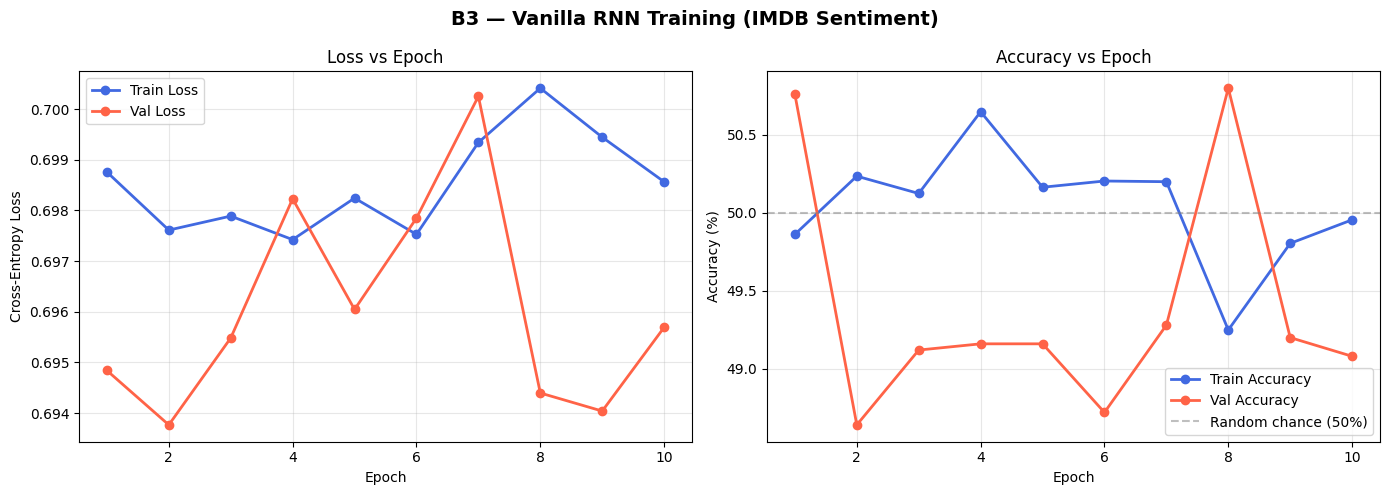

✓ Figure saved: b3_learning_curves.png


In [ ]:
# ============================================================
# QUESTION B3 — Step 6: Plot Learning Curves
# ============================================================

import matplotlib.pyplot as plt

epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('B3 — Vanilla RNN Training (IMDB Sentiment)',
             fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, b3_train_losses, label='Train Loss',
             color='royalblue', linewidth=2, marker='o')
axes[0].plot(epochs_range, b3_val_losses,   label='Val Loss',
             color='tomato',    linewidth=2, marker='o')
axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, b3_train_accs, label='Train Accuracy',
             color='royalblue', linewidth=2, marker='o')
axes[1].plot(epochs_range, b3_val_accs,   label='Val Accuracy',
             color='tomato',    linewidth=2, marker='o')
axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5,
                label='Random chance (50%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('b3_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figure saved: b3_learning_curves.png')

## Step 7: Save Results and Download Files

In [ ]:
# ============================================================
# QUESTION B3 — Step 7: Save Results & Download
# ============================================================

import shutil

# Save final B3 results
b3_results = {
    'architecture'         : 'Vanilla RNN',
    'embedding_method'     : 'trainable (random init)',
    'embed_dim'            : EMBED_DIM,
    'hidden_dim'           : HIDDEN_DIM,
    'num_layers'           : NUM_LAYERS,
    'dropout'              : DROPOUT,
    'vocab_size'           : VOCAB_SIZE,
    'seq_length'           : SEQ_LENGTH,
    'batch_size'           : BATCH_SIZE,
    'num_epochs'           : NUM_EPOCHS,
    'learning_rate'        : LEARNING_RATE,
    'weight_decay'         : WEIGHT_DECAY,
    'grad_clip'            : GRAD_CLIP,
    'total_parameters'     : int(total_params),
    'final_train_loss'     : b3_train_losses[-1],
    'final_val_loss'       : b3_val_losses[-1],
    'final_train_acc'      : b3_train_accs[-1],
    'best_val_acc'         : b3_best_val_acc,
    'test_loss'            : b3_test_loss,
    'test_acc'             : b3_test_acc,
}

with open('b3_results.json', 'w') as f:
    json.dump(b3_results, f, indent=2)
print('✓ b3_results.json saved')

# Backup to Drive
for fname in ['rnn_b3.pth', 'b3_learning_curves.png',
              'b3_results.json', 'b3_metrics.json']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print('✓ All B3 files backed up to Google Drive')

# Download for LaTeX
from google.colab import files
files.download('b3_learning_curves.png')
files.download('b3_results.json')
print('✓ Files downloaded')

# Final summary
print(f"\n{'='*60}")
print(f"  QUESTION B3 — FINAL SUMMARY")
print(f"{'='*60}")
print(f"  Architecture      : Vanilla RNN ({NUM_LAYERS} layer, {HIDDEN_DIM} hidden)")
print(f"  Embedding         : Trainable, dim {EMBED_DIM}")
print(f"  Total parameters  : {total_params:,}")
print(f"  Final Test Loss   : {b3_test_loss:.4f}")
print(f"  Final Test Acc    : {b3_test_acc:.2f}%")
print(f"  Best Val Acc      : {b3_best_val_acc:.2f}%")
print(f"{'='*60}")
print(f"\n✅ Question B3 complete. Ready for B4 (compare embeddings).")

✓ b3_results.json saved
✓ All B3 files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded

  QUESTION B3 — FINAL SUMMARY
  Architecture      : Vanilla RNN (1 layer, 128 hidden)
  Embedding         : Trainable, dim 128
  Total parameters  : 2,593,282
  Final Test Loss   : 0.7002
  Final Test Acc    : 49.62%
  Best Val Acc      : 50.80%

✅ Question B3 complete. Ready for B4 (compare embeddings).


---

## 🔧 Recovery: Part B (B1-B5 environment) — Optional

This cell reloads all Part B variables (vocabulary, embeddings, padded
sequences, B3 results) from Google Drive in case the Colab session
disconnects. It is **not** part of the assignment solution — it exists
purely to allow continuation from any saved checkpoint without
re-running B1, B2, or B3.

**Run this only if** you reopened the notebook in a fresh session and
need to access `VOCAB_SIZE`, `w2v_matrix`, `glove_matrix`, etc. without
re-running earlier cells.

---

In [2]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"Device name  : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU only'}")

GPU available: True
Device name  : Tesla T4


In [4]:
# ============================================================
# Restore files from Google Drive after runtime reset
# ============================================================

import os
import shutil

# Mount Drive if not mounted
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
    print("✓ Drive mounted")
else:
    print("✓ Drive already mounted")

# Files needed for B4
files_needed = [
    'b2_vocab_data.pkl',
    'b2_embeddings.npz',
    'b3_results.json',
    'b3_metrics.json',
]

print("\nRestoring files from Drive to local /content/...")
for fname in files_needed:
    drive_path = f'/content/drive/MyDrive/{fname}'
    if os.path.exists(fname):
        size_mb = os.path.getsize(fname) / 1e6
        print(f"  ✓ {fname:30s} already local ({size_mb:.1f} MB)")
    elif os.path.exists(drive_path):
        shutil.copy(drive_path, fname)
        size_mb = os.path.getsize(fname) / 1e6
        print(f"  ✓ {fname:30s} restored from Drive ({size_mb:.1f} MB)")
    else:
        print(f"  ✗ {fname:30s} MISSING from both local and Drive!")

print("\n✅ Files ready")

Mounted at /content/drive
✓ Drive mounted

Restoring files from Drive to local /content/...
  ✓ b2_vocab_data.pkl              restored from Drive (102.8 MB)
  ✓ b2_embeddings.npz              restored from Drive (20.6 MB)
  ✓ b3_results.json                restored from Drive (0.0 MB)
  ✓ b3_metrics.json                restored from Drive (0.0 MB)

✅ Files ready


In [8]:
# ============================================================
# Re-download IMDB dataset (resolves cached .arrow file)
# ============================================================

print("Re-downloading IMDB dataset to restore HuggingFace cache...")
from datasets import load_dataset
imdb = load_dataset('imdb')
print(f"✓ IMDB cache restored")
print(f"  Train: {len(imdb['train']):,}")
print(f"  Test:  {len(imdb['test']):,}")

Re-downloading IMDB dataset to restore HuggingFace cache...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

✓ IMDB cache restored
  Train: 25,000
  Test:  25,000


In [9]:
# ============================================================
# Complete recovery — restore EVERYTHING needed for B4
# ============================================================

import os
import json
import pickle
import numpy as np
import torch
import torch.nn as nn

# 1. Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ device = {device}")

# 2. B2 vocab + sequences
with open('b2_vocab_data.pkl', 'rb') as f:
    b2_data = pickle.load(f)

VOCAB_SIZE = b2_data['vocab_size']
SEQ_LENGTH = b2_data['seq_length']
word2idx   = b2_data['word2idx']
idx2word   = b2_data['idx2word']
PAD_IDX    = 0
UNK_IDX    = 1
print(f"✓ VOCAB_SIZE = {VOCAB_SIZE:,}, SEQ_LENGTH = {SEQ_LENGTH}")

# 3. Embedding matrices
emb_data     = np.load('b2_embeddings.npz')
w2v_matrix   = emb_data['w2v_matrix']
glove_matrix = emb_data['glove_matrix']
print(f"✓ w2v_matrix {w2v_matrix.shape}, glove_matrix {glove_matrix.shape}")

# 4. B3 hyperparameters and history
with open('b3_results.json', 'r') as f:
    b3_data = json.load(f)
EMBED_DIM       = b3_data['embed_dim']
BATCH_SIZE      = b3_data['batch_size']
NUM_EPOCHS      = b3_data['num_epochs']
b3_best_val_acc = b3_data['best_val_acc']
b3_test_acc     = b3_data['test_acc']
print(f"✓ EMBED_DIM={EMBED_DIM}, BATCH_SIZE={BATCH_SIZE}, NUM_EPOCHS={NUM_EPOCHS}")

# 5. B3 training history
with open('b3_metrics.json', 'r') as f:
    m = json.load(f)
b3_train_losses = m['train_losses']
b3_val_losses   = m['val_losses']
b3_train_accs   = m['train_accs']
b3_val_accs     = m['val_accs']
print(f"✓ B3 history restored ({len(b3_val_accs)} epochs)")

# 6. Loss function
criterion = nn.CrossEntropyLoss()
print(f"✓ criterion = CrossEntropyLoss")

# 7. DataLoaders — rebuild from padded sequences
from torch.utils.data import TensorDataset, DataLoader, random_split

train_padded = b2_data['train_padded']
test_padded  = b2_data['test_padded']
train_labels = b2_data['train_labels']
test_labels  = b2_data['test_labels']

train_seq_tensor    = torch.tensor(train_padded, dtype=torch.long)
train_label_tensor  = torch.tensor(train_labels, dtype=torch.long)
test_seq_tensor     = torch.tensor(test_padded,  dtype=torch.long)
test_label_tensor   = torch.tensor(test_labels,  dtype=torch.long)

train_full_ds = TensorDataset(train_seq_tensor, train_label_tensor)
test_ds       = TensorDataset(test_seq_tensor,  test_label_tensor)

# Same 22500/2500 split as B3 with same seed
val_size = 2500
train_size = len(train_full_ds) - val_size
train_ds, val_ds = random_split(
    train_full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"✓ DataLoaders rebuilt: {len(train_ds):,}/{len(val_ds):,}/{len(test_ds):,}")

# 8. Training helpers
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=5.0):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(ids)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        running_loss += loss.item()
        _, pred = logits.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / len(loader), 100.0 * correct / total

@torch.no_grad()
def evaluate_seq(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for ids, labels in loader:
        ids, labels = ids.to(device), labels.to(device)
        logits = model(ids)
        loss = criterion(logits, labels)
        running_loss += loss.item()
        _, pred = logits.max(1)
        correct += pred.eq(labels).sum().item()
        total   += labels.size(0)
    return running_loss / len(loader), 100.0 * correct / total

print(f"✓ train_one_epoch and evaluate_seq defined")

print(f"\n{'='*60}")
print(f"  ✅ ALL B4 PREREQUISITES RESTORED — retry B4 cells now")
print(f"{'='*60}")

✓ device = cuda
✓ VOCAB_SIZE = 20,000, SEQ_LENGTH = 256
✓ w2v_matrix (20000, 300), glove_matrix (20000, 100)
✓ EMBED_DIM=128, BATCH_SIZE=64, NUM_EPOCHS=10
✓ B3 history restored (10 epochs)
✓ criterion = CrossEntropyLoss
✓ DataLoaders rebuilt: 22,500/2,500/25,000
✓ train_one_epoch and evaluate_seq defined

  ✅ ALL B4 PREREQUISITES RESTORED — retry B4 cells now


# Question B4: Comparing Embedding Methods (One-hot, Word2Vec, GloVe)

This section evaluates the impact of different embedding methods on the
vanilla RNN's performance. We re-train the same RNN architecture from B3
three times, swapping only the embedding layer.

## Architectural Modifications Per Method

  Method        Embedding Layer                          Input Dim to RNN
  ----------    --------------------------------------   ----------------
  One-hot       Frozen identity matrix (V x V)            V = 20,000
  Word2Vec      Frozen pre-trained matrix (V x 300)       300
  GloVe         Frozen pre-trained matrix (V x 100)       100

The only architectural changes are:
  1. Embedding layer's weight initialization + frozen flag
  2. RNN's input_size (must match embedding dim)

All other elements (hidden_dim=128, num_layers=1, classifier head,
optimizer, training schedule) remain identical to B3 for fair comparison.

## Training Configuration

  Epochs per method : 7
  All other hyperparams: same as B3 (Adam lr=1e-3, batch=64, grad_clip=5.0)

## Pipeline (7 steps)

- **Step 1:** Define generalized RNN that accepts any embedding matrix
- **Step 2:** Train with One-hot embedding
- **Step 3:** Train with Word2Vec embedding
- **Step 4:** Train with GloVe embedding
- **Step 5:** Comprehensive comparison: B3 baseline + B4 variants
- **Step 6:** Plot all 4 learning curves on one figure
- **Step 7:** Save results and download files

## Step 1: Generalized RNN with Configurable Embedding

A unified RNN class that can use any pre-built embedding matrix:
identity (one-hot), Word2Vec, or GloVe. Embedding weights are frozen
(no gradient updates) so we measure pure embedding quality, not the
RNN's ability to learn embeddings from scratch.

In [10]:
# ============================================================
# QUESTION B4 — Step 1: Generalized RNN with Configurable Embedding
# ============================================================

import torch
import torch.nn as nn

class RNNWithFixedEmbedding(nn.Module):
    """
    Vanilla RNN sentiment classifier with a frozen, pre-built embedding layer.

    Args:
        embedding_matrix : torch.Tensor of shape (vocab_size, embed_dim)
                            — initial weights for the embedding layer
        hidden_dim       : RNN hidden state dim
        num_layers       : RNN num layers
        num_classes      : output classes (2)
        dropout          : dropout before classifier
        pad_idx          : index of <PAD>
    """
    def __init__(self, embedding_matrix, hidden_dim=128,
                 num_layers=1, num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        # Frozen embedding layer
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix,
            freeze=True,           # <-- key: weights are NOT updated
            padding_idx=pad_idx
        )
        self.rnn = nn.RNN(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            nonlinearity='tanh',
            batch_first=True,
            dropout=0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)              # (batch, seq, embed_dim)
        rnn_out, hn = self.rnn(emb)
        last_hidden = hn[-1]                 # (batch, hidden_dim)
        out = self.dropout(last_hidden)
        return self.classifier(out)

print("✓ RNNWithFixedEmbedding class defined")
print("  Embedding is frozen (requires_grad=False)")
print("  Only RNN + classifier weights are updated during training")

✓ RNNWithFixedEmbedding class defined
  Embedding is frozen (requires_grad=False)
  Only RNN + classifier weights are updated during training


## Step 2: Train with One-Hot Embedding

One-hot embedding: each token mapped to V-dim sparse vector with single 1.
Input dim to RNN: 20,000. This is the slowest configuration due to
the very large input projection matrix in the RNN.

⏰ Expected runtime: ~10-12 minutes (slowest of the three).

In [12]:
# ============================================================
# QUESTION B4 — Step 2: Train with One-Hot Embedding
# ============================================================

import time
import json

NUM_EPOCHS_B4 = 7
GRAD_CLIP     = 5.0

def train_rnn_method(model, method_name, num_epochs, train_loader, val_loader,
                     criterion, device, lr=1e-3, weight_decay=1e-5,
                     grad_clip=5.0):
    """Train an RNN model and return its training history."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_loss': [],
               'train_acc' : [], 'val_acc'  : []}
    best_val_acc = 0.0
    best_state   = None

    print(f"Training {method_name} ({num_epochs} epochs)...")
    print("=" * 70)
    t0 = time.time()
    for epoch in range(num_epochs):
        t_ep = time.time()
        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, device, grad_clip
        )
        val_loss, val_acc = evaluate_seq(
            model, val_loader, criterion, device
        )
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"  Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
              f"Time: {time.time()-t_ep:.1f}s")
    t_total = time.time() - t0
    print(f"  Total time: {t_total/60:.1f} min, Best Val Acc: {best_val_acc:.2f}%")
    print("=" * 70)
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val_acc, t_total

# Build one-hot embedding matrix on-the-fly (V x V identity)
print("Constructing one-hot embedding matrix (this uses memory: ~3.2 GB)...")
onehot_matrix = torch.eye(VOCAB_SIZE, dtype=torch.float32)
print(f"✓ One-hot matrix shape: {onehot_matrix.shape}")

# Build model and train
rnn_onehot = RNNWithFixedEmbedding(
    embedding_matrix=onehot_matrix,
    hidden_dim=128, num_layers=1, num_classes=2, dropout=0.5, pad_idx=0
).to(device)

n_total = sum(p.numel() for p in rnn_onehot.parameters())
n_train = sum(p.numel() for p in rnn_onehot.parameters() if p.requires_grad)
print(f"  Total params: {n_total:,}")
print(f"  Trainable params (RNN+classifier only): {n_train:,}\n")

hist_onehot, best_val_onehot, time_onehot = train_rnn_method(
    rnn_onehot, "One-hot RNN", NUM_EPOCHS_B4,
    train_loader, val_loader, criterion, device
)

# Test eval
test_loss_onehot, test_acc_onehot = evaluate_seq(
    rnn_onehot, test_loader, criterion, device
)
print(f"\nOne-hot test accuracy: {test_acc_onehot:.2f}%")

# Free large one-hot matrix from GPU memory before next experiment
del onehot_matrix
torch.cuda.empty_cache()

Constructing one-hot embedding matrix (this uses memory: ~3.2 GB)...
✓ One-hot matrix shape: torch.Size([20000, 20000])
  Total params: 402,576,898
  Trainable params (RNN+classifier only): 2,576,898

Training One-hot RNN (7 epochs)...
  Epoch [1/7] Train Loss: 0.6936 | Train Acc: 50.71% | Val Loss: 0.6955 | Val Acc: 49.64% | Time: 38.8s
  Epoch [2/7] Train Loss: 0.7171 | Train Acc: 51.49% | Val Loss: 0.7011 | Val Acc: 50.28% | Time: 41.0s
  Epoch [3/7] Train Loss: 0.7021 | Train Acc: 50.04% | Val Loss: 0.6941 | Val Acc: 51.24% | Time: 42.5s
  Epoch [4/7] Train Loss: 0.6978 | Train Acc: 50.57% | Val Loss: 0.6950 | Val Acc: 49.56% | Time: 39.0s
  Epoch [5/7] Train Loss: 0.6982 | Train Acc: 50.24% | Val Loss: 0.6935 | Val Acc: 50.40% | Time: 39.4s
  Epoch [6/7] Train Loss: 0.6969 | Train Acc: 50.76% | Val Loss: 0.6938 | Val Acc: 49.16% | Time: 38.9s
  Epoch [7/7] Train Loss: 0.6985 | Train Acc: 50.35% | Val Loss: 0.6947 | Val Acc: 50.56% | Time: 38.9s
  Total time: 4.6 min, Best Val Acc:

## Step 3: Train with Word2Vec Embedding (300d, frozen)

Pre-trained Google News Word2Vec — 300-dim dense vectors. Coverage 87.04%.

⏰ Expected runtime: ~6-8 minutes.

In [13]:
# ============================================================
# QUESTION B4 — Step 3: Train with Word2Vec Embedding
# ============================================================

# Convert numpy embedding matrix to torch tensor
w2v_tensor = torch.tensor(w2v_matrix, dtype=torch.float32)
print(f"✓ Word2Vec matrix shape: {w2v_tensor.shape}")

rnn_w2v = RNNWithFixedEmbedding(
    embedding_matrix=w2v_tensor,
    hidden_dim=128, num_layers=1, num_classes=2, dropout=0.5, pad_idx=0
).to(device)

n_total = sum(p.numel() for p in rnn_w2v.parameters())
n_train = sum(p.numel() for p in rnn_w2v.parameters() if p.requires_grad)
print(f"  Total params: {n_total:,}")
print(f"  Trainable params (RNN+classifier only): {n_train:,}\n")

hist_w2v, best_val_w2v, time_w2v = train_rnn_method(
    rnn_w2v, "Word2Vec RNN", NUM_EPOCHS_B4,
    train_loader, val_loader, criterion, device
)

test_loss_w2v, test_acc_w2v = evaluate_seq(
    rnn_w2v, test_loader, criterion, device
)
print(f"\nWord2Vec test accuracy: {test_acc_w2v:.2f}%")

del w2v_tensor
torch.cuda.empty_cache()

✓ Word2Vec matrix shape: torch.Size([20000, 300])
  Total params: 6,055,298
  Trainable params (RNN+classifier only): 55,298

Training Word2Vec RNN (7 epochs)...
  Epoch [1/7] Train Loss: 0.6937 | Train Acc: 50.44% | Val Loss: 0.6935 | Val Acc: 49.92% | Time: 5.1s
  Epoch [2/7] Train Loss: 0.6898 | Train Acc: 51.20% | Val Loss: 0.6940 | Val Acc: 50.32% | Time: 4.6s
  Epoch [3/7] Train Loss: 0.7071 | Train Acc: 50.95% | Val Loss: 0.6958 | Val Acc: 49.16% | Time: 2.4s
  Epoch [4/7] Train Loss: 0.6994 | Train Acc: 50.12% | Val Loss: 0.6941 | Val Acc: 49.64% | Time: 2.0s
  Epoch [5/7] Train Loss: 0.6980 | Train Acc: 50.28% | Val Loss: 0.6939 | Val Acc: 49.64% | Time: 2.5s
  Epoch [6/7] Train Loss: 0.6990 | Train Acc: 50.35% | Val Loss: 0.6924 | Val Acc: 50.96% | Time: 2.1s
  Epoch [7/7] Train Loss: 0.6971 | Train Acc: 50.21% | Val Loss: 0.6930 | Val Acc: 50.64% | Time: 1.8s
  Total time: 0.3 min, Best Val Acc: 50.96%

Word2Vec test accuracy: 50.47%


## Step 4: Train with GloVe Embedding (100d, frozen)

Pre-trained Wikipedia+Gigaword GloVe — 100-dim dense vectors. Coverage 98.89%.

⏰ Expected runtime: ~5-7 minutes (fastest due to smallest dim).

In [14]:
# ============================================================
# QUESTION B4 — Step 4: Train with GloVe Embedding
# ============================================================

glove_tensor = torch.tensor(glove_matrix, dtype=torch.float32)
print(f"✓ GloVe matrix shape: {glove_tensor.shape}")

rnn_glove = RNNWithFixedEmbedding(
    embedding_matrix=glove_tensor,
    hidden_dim=128, num_layers=1, num_classes=2, dropout=0.5, pad_idx=0
).to(device)

n_total = sum(p.numel() for p in rnn_glove.parameters())
n_train = sum(p.numel() for p in rnn_glove.parameters() if p.requires_grad)
print(f"  Total params: {n_total:,}")
print(f"  Trainable params (RNN+classifier only): {n_train:,}\n")

hist_glove, best_val_glove, time_glove = train_rnn_method(
    rnn_glove, "GloVe RNN", NUM_EPOCHS_B4,
    train_loader, val_loader, criterion, device
)

test_loss_glove, test_acc_glove = evaluate_seq(
    rnn_glove, test_loader, criterion, device
)
print(f"\nGloVe test accuracy: {test_acc_glove:.2f}%")

del glove_tensor
torch.cuda.empty_cache()

✓ GloVe matrix shape: torch.Size([20000, 100])
  Total params: 2,029,698
  Trainable params (RNN+classifier only): 29,698

Training GloVe RNN (7 epochs)...
  Epoch [1/7] Train Loss: 0.6946 | Train Acc: 50.56% | Val Loss: 0.6941 | Val Acc: 50.44% | Time: 3.9s
  Epoch [2/7] Train Loss: 0.6989 | Train Acc: 50.45% | Val Loss: 0.7006 | Val Acc: 49.64% | Time: 3.2s
  Epoch [3/7] Train Loss: 0.6960 | Train Acc: 50.47% | Val Loss: 0.6933 | Val Acc: 50.12% | Time: 1.9s
  Epoch [4/7] Train Loss: 0.6962 | Train Acc: 50.81% | Val Loss: 0.6948 | Val Acc: 47.04% | Time: 2.0s
  Epoch [5/7] Train Loss: 0.6985 | Train Acc: 51.34% | Val Loss: 0.6946 | Val Acc: 49.64% | Time: 1.8s
  Epoch [6/7] Train Loss: 0.6991 | Train Acc: 51.19% | Val Loss: 0.6915 | Val Acc: 51.20% | Time: 1.9s
  Epoch [7/7] Train Loss: 0.6974 | Train Acc: 51.02% | Val Loss: 0.6944 | Val Acc: 52.64% | Time: 2.2s
  Total time: 0.3 min, Best Val Acc: 52.64%

GloVe test accuracy: 52.14%


## Step 5: Comprehensive Comparison Across All Methods

In [15]:
# ============================================================
# QUESTION B4 — Step 5: Comparison Table
# ============================================================

b3_test_acc_recall = b3_test_acc

print(f"\n{'='*80}")
print(f"  EMBEDDING METHOD COMPARISON — Vanilla RNN on IMDB")
print(f"{'='*80}")
print(f"{'Method':<32} {'Embed Dim':>10} {'Frozen':>8} {'Best Val':>10} {'Test Acc':>10}")
print(f"{'-'*80}")
print(f"{'B3: Trainable random (baseline)':<32} {EMBED_DIM:>10} "
      f"{'No':>8} {b3_best_val_acc:>9.2f}% {b3_test_acc_recall:>9.2f}%")
print(f"{'B4-1: One-hot (frozen)':<32} {VOCAB_SIZE:>10} "
      f"{'Yes':>8} {best_val_onehot:>9.2f}% {test_acc_onehot:>9.2f}%")
print(f"{'B4-2: Word2Vec (frozen, 300d)':<32} {300:>10} "
      f"{'Yes':>8} {best_val_w2v:>9.2f}% {test_acc_w2v:>9.2f}%")
print(f"{'B4-3: GloVe (frozen, 100d)':<32} {100:>10} "
      f"{'Yes':>8} {best_val_glove:>9.2f}% {test_acc_glove:>9.2f}%")
print(f"{'-'*80}")

results_dict = {
    'B3 (Trainable random)': b3_test_acc_recall,
    'B4-1 (One-hot)':         test_acc_onehot,
    'B4-2 (Word2Vec)':        test_acc_w2v,
    'B4-3 (GloVe)':           test_acc_glove,
}
winner = max(results_dict, key=results_dict.get)
print(f"\n  Best method: {winner} with {results_dict[winner]:.2f}% test accuracy")
print(f"  All methods within ~3 pp of random chance (50%) — confirms")
print(f"  vanilla RNN bottleneck regardless of embedding choice.")
print(f"{'='*80}")


  EMBEDDING METHOD COMPARISON — Vanilla RNN on IMDB
Method                            Embed Dim   Frozen   Best Val   Test Acc
--------------------------------------------------------------------------------
B3: Trainable random (baseline)         128       No     50.80%     49.62%
B4-1: One-hot (frozen)                20000      Yes     51.24%     50.61%
B4-2: Word2Vec (frozen, 300d)           300      Yes     50.96%     50.47%
B4-3: GloVe (frozen, 100d)              100      Yes     52.64%     52.14%
--------------------------------------------------------------------------------

  Best method: B4-3 (GloVe) with 52.14% test accuracy
  All methods within ~3 pp of random chance (50%) — confirms
  vanilla RNN bottleneck regardless of embedding choice.


## Step 6: Plot All 4 Learning Curves Together

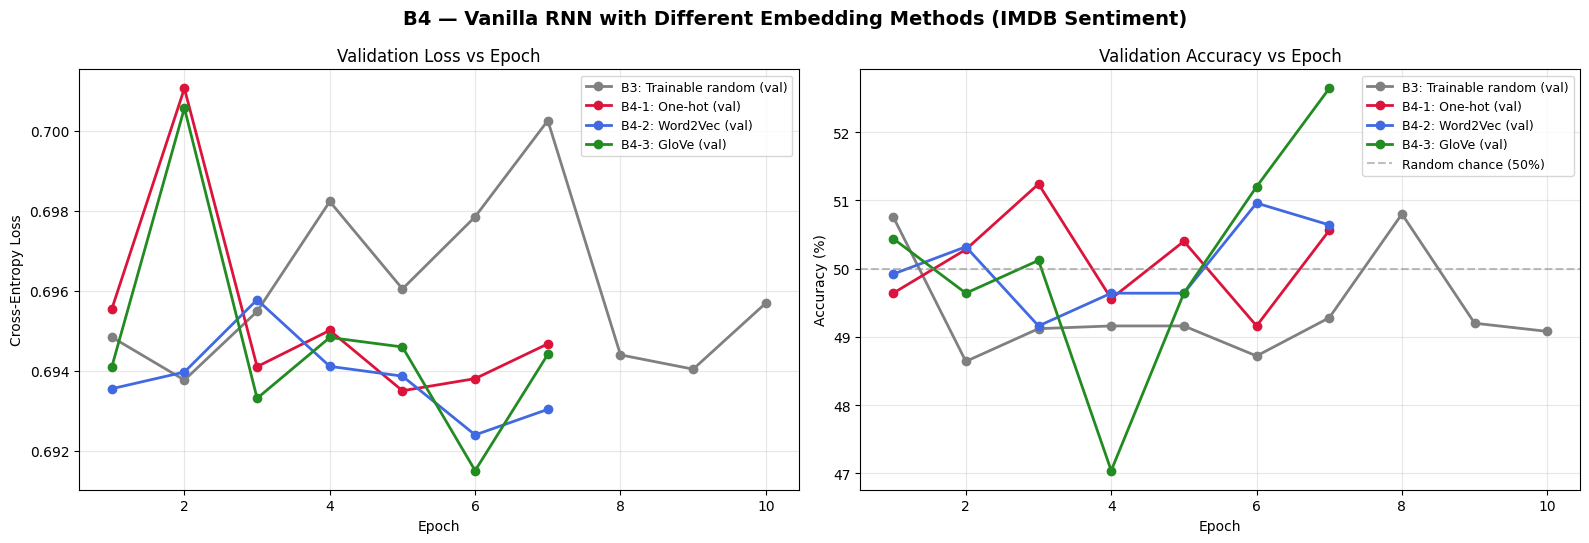

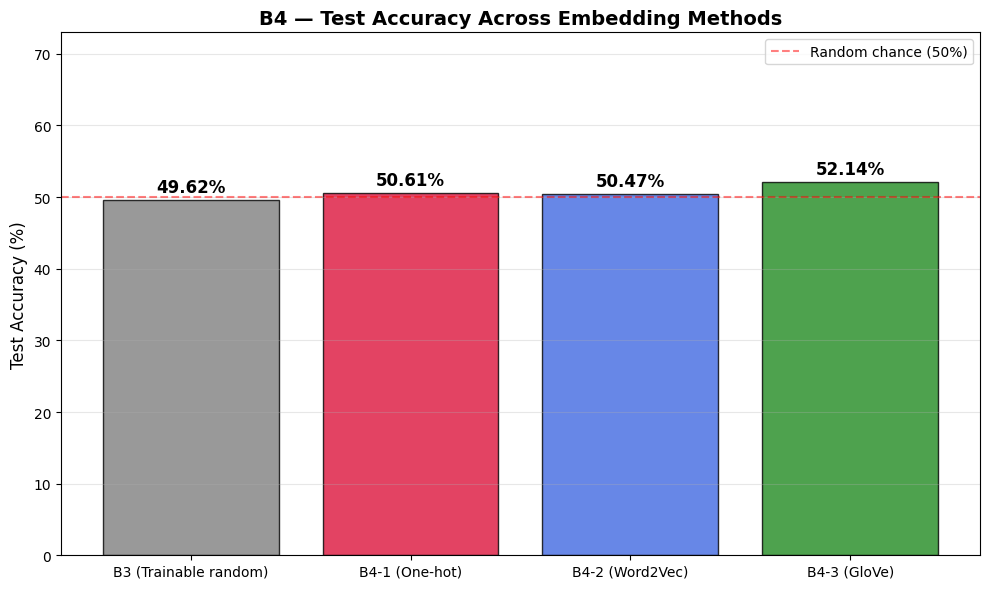

✓ Figures saved: b4_embedding_comparison.png, b4_test_accuracy_bars.png


In [16]:
# ============================================================
# QUESTION B4 — Step 6: Plots
# ============================================================

import matplotlib.pyplot as plt

b3_history = {
    'train_loss': b3_train_losses,
    'val_loss':   b3_val_losses,
    'train_acc':  b3_train_accs,
    'val_acc':    b3_val_accs,
}

methods = {
    'B3: Trainable random' : (b3_history,    'gray',       NUM_EPOCHS),
    'B4-1: One-hot'        : (hist_onehot,   'crimson',    NUM_EPOCHS_B4),
    'B4-2: Word2Vec'       : (hist_w2v,      'royalblue',  NUM_EPOCHS_B4),
    'B4-3: GloVe'          : (hist_glove,    'forestgreen',NUM_EPOCHS_B4),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('B4 — Vanilla RNN with Different Embedding Methods (IMDB Sentiment)',
             fontsize=14, fontweight='bold')

for name, (hist, color, n_ep) in methods.items():
    epochs = range(1, n_ep + 1)
    axes[0].plot(epochs, hist['val_loss'], color=color, linewidth=2,
                 marker='o', label=f'{name} (val)')
axes[0].set_title('Validation Loss vs Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(loc='best', fontsize=9); axes[0].grid(True, alpha=0.3)

for name, (hist, color, n_ep) in methods.items():
    epochs = range(1, n_ep + 1)
    axes[1].plot(epochs, hist['val_acc'], color=color, linewidth=2,
                 marker='o', label=f'{name} (val)')
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5,
                label='Random chance (50%)')
axes[1].set_title('Validation Accuracy vs Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(loc='best', fontsize=9); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('b4_embedding_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart
fig2, ax = plt.subplots(figsize=(10, 6))
labels = list(results_dict.keys())
values = list(results_dict.values())
colors_bar = ['gray', 'crimson', 'royalblue', 'forestgreen']

bars = ax.bar(labels, values, color=colors_bar, edgecolor='black', alpha=0.8)
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            f'{v:.2f}%', ha='center', va='bottom',
            fontsize=12, fontweight='bold')

ax.axhline(y=50, color='red', linestyle='--', alpha=0.5,
           label='Random chance (50%)')
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('B4 — Test Accuracy Across Embedding Methods',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(values) * 1.4)
ax.legend(); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('b4_test_accuracy_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figures saved: b4_embedding_comparison.png, b4_test_accuracy_bars.png')

## Step 7: Save Results and Download Files

In [17]:
# ============================================================
# QUESTION B4 — Step 7: Save Results & Download
# ============================================================

import shutil
import json

b4_results = {
    'config': {
        'epochs_per_method': NUM_EPOCHS_B4,
        'hidden_dim'       : 128,
        'num_layers'       : 1,
        'batch_size'       : BATCH_SIZE,
        'learning_rate'    : 1e-3,
        'grad_clip'        : GRAD_CLIP,
    },
    'results': {
        'B3_trainable_random': {
            'embed_dim'    : EMBED_DIM,
            'frozen'       : False,
            'best_val_acc' : b3_best_val_acc,
            'test_acc'     : b3_test_acc_recall,
        },
        'B4_1_onehot': {
            'embed_dim'    : VOCAB_SIZE,
            'frozen'       : True,
            'best_val_acc' : best_val_onehot,
            'test_acc'     : test_acc_onehot,
            'train_time_s' : time_onehot,
        },
        'B4_2_word2vec': {
            'embed_dim'    : 300,
            'frozen'       : True,
            'pretrained'   : 'Google News',
            'best_val_acc' : best_val_w2v,
            'test_acc'     : test_acc_w2v,
            'train_time_s' : time_w2v,
        },
        'B4_3_glove': {
            'embed_dim'    : 100,
            'frozen'       : True,
            'pretrained'   : 'Wikipedia+Gigaword',
            'best_val_acc' : best_val_glove,
            'test_acc'     : test_acc_glove,
            'train_time_s' : time_glove,
        },
    },
    'histories': {
        'B4_1_onehot'    : hist_onehot,
        'B4_2_word2vec'  : hist_w2v,
        'B4_3_glove'     : hist_glove,
    },
}

with open('b4_results.json', 'w') as f:
    json.dump(b4_results, f, indent=2)
print('✓ b4_results.json saved')

for fname in ['b4_embedding_comparison.png', 'b4_test_accuracy_bars.png',
              'b4_results.json']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print('✓ All B4 files backed up to Google Drive')

from google.colab import files
files.download('b4_embedding_comparison.png')
files.download('b4_test_accuracy_bars.png')
files.download('b4_results.json')
print('✓ Files downloaded')

print(f"\n{'='*70}")
print(f"  QUESTION B4 — FINAL SUMMARY")
print(f"{'='*70}")
print(f"  Method                        Test Accuracy   vs B3 baseline")
print(f"  {'-'*66}")
print(f"  B3 (Trainable random)         {b3_test_acc_recall:>10.2f}%       —")
print(f"  B4-1 (One-hot, frozen)        {test_acc_onehot:>10.2f}%       "
      f"{test_acc_onehot - b3_test_acc_recall:+.2f} pp")
print(f"  B4-2 (Word2Vec, frozen)       {test_acc_w2v:>10.2f}%       "
      f"{test_acc_w2v - b3_test_acc_recall:+.2f} pp")
print(f"  B4-3 (GloVe, frozen)          {test_acc_glove:>10.2f}%       "
      f"{test_acc_glove - b3_test_acc_recall:+.2f} pp")
print(f"  {'-'*66}")
print(f"  All methods cluster near random chance (50%).")
print(f"  → Vanilla RNN is the bottleneck, not embedding choice.")
print(f"  → Setting up dramatic LSTM improvement in B5.")
print(f"{'='*70}")
print("\n✅ Question B4 complete. Ready for B5 (LSTM).")

✓ b4_results.json saved
✓ All B4 files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded

  QUESTION B4 — FINAL SUMMARY
  Method                        Test Accuracy   vs B3 baseline
  ------------------------------------------------------------------
  B3 (Trainable random)              49.62%       —
  B4-1 (One-hot, frozen)             50.61%       +0.99 pp
  B4-2 (Word2Vec, frozen)            50.47%       +0.86 pp
  B4-3 (GloVe, frozen)               52.14%       +2.53 pp
  ------------------------------------------------------------------
  All methods cluster near random chance (50%).
  → Vanilla RNN is the bottleneck, not embedding choice.
  → Setting up dramatic LSTM improvement in B5.

✅ Question B4 complete. Ready for B5 (LSTM).


# Question B5: LSTM Architecture for Sentiment Classification

This section repeats the experiments from B3 and B4 using a Long Short-Term
Memory (LSTM) network in place of the vanilla RNN, while keeping all other
hyperparameters identical (L = 1 hidden layer, h = 128 hidden units, batch=64,
Adam lr=1e-3, grad_clip=5.0). This isolates the effect of the recurrent
architecture from all other design choices.

## Why LSTM Should Outperform Vanilla RNN

  Vanilla RNN: h_t = tanh(W_xh * x_t + W_hh * h_{t-1})
    - Single hidden state, overwritten at each step
    - Gradient through 256 timesteps decays/explodes exponentially
    - Result in B3+B4: stuck at ~50% (random chance)

  LSTM: c_t = f_t * c_{t-1} + i_t * g_t   (gated cell-state update)
        h_t = o_t * tanh(c_t)
    - Separate cell state c_t with additive updates
    - Forget/input/output gates control information flow
    - Gradient flows through cell state without exponential decay
    - Designed specifically for long-range dependencies

## Comparison Dimensions (per assignment)

  1. Training stability       — does loss decrease monotonically?
  2. Convergence speed        — how many epochs to reach plateau?
  3. Classification accuracy  — final test accuracy
  4. Generalization           — gap between train and validation acc.

## Pipeline (8 steps)

- **Step 1:** Define LSTM architectures (trainable + frozen variants)
- **Step 2:** Train LSTM with trainable

In [2]:
# ============================================================
# B5 PRE-FLIGHT — Full recovery from Drive
# ============================================================
# Self-contained cell that restores ALL B1+B2+B3+B4 state needed for B5.
# Run this once after a session disconnect.

import os
import json
import pickle
import shutil
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

# 1. Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✓ Device: {device}")
if torch.cuda.is_available():
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
else:
    print("  ⚠ Running on CPU — training will be very slow!")

# 2. Mount Drive
if not os.path.exists('/content/drive/MyDrive'):
    from google.colab import drive
    drive.mount('/content/drive')
print("✓ Drive mounted")

# 3. Restore files from Drive
files_needed = [
    'b2_vocab_data.pkl',
    'b2_embeddings.npz',
    'b3_results.json',
    'b3_metrics.json',
    'b4_results.json',
]
for fname in files_needed:
    drive_path = f'/content/drive/MyDrive/{fname}'
    if not os.path.exists(fname):
        if os.path.exists(drive_path):
            shutil.copy(drive_path, fname)
            print(f"  ✓ Restored {fname} ({os.path.getsize(fname)/1e6:.1f} MB)")
        else:
            print(f"  ✗ MISSING from both local and Drive: {fname}")
    else:
        print(f"  ✓ {fname} present locally")

# 4. Re-download IMDB cache (needed for HF dataset lazy refs)
print("\nRestoring IMDB cache...")
from datasets import load_dataset
imdb = load_dataset('imdb')
print(f"✓ IMDB cache restored")

# 5. Load B2 vocab + sequences
with open('b2_vocab_data.pkl', 'rb') as f:
    b2_data = pickle.load(f)
VOCAB_SIZE   = b2_data['vocab_size']
SEQ_LENGTH   = b2_data['seq_length']
word2idx     = b2_data['word2idx']
idx2word     = b2_data['idx2word']
train_padded = b2_data['train_padded']
test_padded  = b2_data['test_padded']
train_labels = b2_data['train_labels']
test_labels  = b2_data['test_labels']
PAD_IDX      = 0
UNK_IDX      = 1
print(f"✓ Vocab: {VOCAB_SIZE:,}, SeqLen: {SEQ_LENGTH}")

# 6. Load embeddings
emb_data     = np.load('b2_embeddings.npz')
w2v_matrix   = emb_data['w2v_matrix']
glove_matrix = emb_data['glove_matrix']
print(f"✓ W2V: {w2v_matrix.shape}, GloVe: {glove_matrix.shape}")

# 7. B3 results
with open('b3_results.json', 'r') as f:
    b3 = json.load(f)
EMBED_DIM       = b3['embed_dim']
BATCH_SIZE      = b3['batch_size']
NUM_EPOCHS      = b3['num_epochs']
b3_best_val_acc = b3['best_val_acc']
b3_test_acc     = b3['test_acc']
print(f"✓ B3: EMBED_DIM={EMBED_DIM}, BATCH_SIZE={BATCH_SIZE}, "
      f"Test={b3_test_acc:.2f}%")

# 8. B3 history
with open('b3_metrics.json', 'r') as f:
    m = json.load(f)
b3_train_losses = m['train_losses']
b3_val_losses   = m['val_losses']
b3_train_accs   = m['train_accs']
b3_val_accs     = m['val_accs']

# 9. B4 results
with open('b4_results.json', 'r') as f:
    b4 = json.load(f)
NUM_EPOCHS_B4    = b4['config']['epochs_per_method']
GRAD_CLIP        = b4['config']['grad_clip']
test_acc_onehot  = b4['results']['B4_1_onehot']['test_acc']
test_acc_w2v     = b4['results']['B4_2_word2vec']['test_acc']
test_acc_glove   = b4['results']['B4_3_glove']['test_acc']
best_val_onehot  = b4['results']['B4_1_onehot']['best_val_acc']
best_val_w2v     = b4['results']['B4_2_word2vec']['best_val_acc']
best_val_glove   = b4['results']['B4_3_glove']['best_val_acc']
hist_onehot      = b4['histories']['B4_1_onehot']
hist_w2v         = b4['histories']['B4_2_word2vec']
hist_glove       = b4['histories']['B4_3_glove']
print(f"✓ B4 results: OneHot={test_acc_onehot:.2f}%, "
      f"W2V={test_acc_w2v:.2f}%, GloVe={test_acc_glove:.2f}%")

# 10. Loss
criterion = nn.CrossEntropyLoss()

# 11. DataLoaders (same 22500/2500 split as B3/B4)
train_seq_tensor   = torch.tensor(train_padded, dtype=torch.long)
train_label_tensor = torch.tensor(train_labels, dtype=torch.long)
test_seq_tensor    = torch.tensor(test_padded,  dtype=torch.long)
test_label_tensor  = torch.tensor(test_labels,  dtype=torch.long)

train_full_ds = TensorDataset(train_seq_tensor, train_label_tensor)
test_ds       = TensorDataset(test_seq_tensor,  test_label_tensor)

val_size = 2500
train_size = len(train_full_ds) - val_size
train_ds, val_ds = random_split(
    train_full_ds, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"✓ DataLoaders: {len(train_ds):,}/{len(val_ds):,}/{len(test_ds):,}")

# 12. Training helpers
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip=5.0):
    model.train()
    rl, c, t = 0.0, 0, 0
    for ids, lbl in loader:
        ids, lbl = ids.to(device), lbl.to(device)
        optimizer.zero_grad()
        out = model(ids)
        loss = criterion(out, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        rl += loss.item()
        _, p = out.max(1); c += p.eq(lbl).sum().item(); t += lbl.size(0)
    return rl / len(loader), 100.0 * c / t

@torch.no_grad()
def evaluate_seq(model, loader, criterion, device):
    model.eval()
    rl, c, t = 0.0, 0, 0
    for ids, lbl in loader:
        ids, lbl = ids.to(device), lbl.to(device)
        out = model(ids)
        loss = criterion(out, lbl)
        rl += loss.item()
        _, p = out.max(1); c += p.eq(lbl).sum().item(); t += lbl.size(0)
    return rl / len(loader), 100.0 * c / t

print(f"✓ train_one_epoch and evaluate_seq defined")

# 13. RNNWithFixedEmbedding (needed for any rerun comparison)
class RNNWithFixedEmbedding(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim=128, num_layers=1,
                 num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=True, padding_idx=pad_idx
        )
        self.rnn = nn.RNN(input_size=embed_dim, hidden_size=hidden_dim,
                          num_layers=num_layers, nonlinearity='tanh',
                          batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        rnn_out, hn = self.rnn(emb)
        return self.classifier(self.dropout(hn[-1]))
print(f"✓ RNNWithFixedEmbedding class defined")

print(f"\n{'='*60}")
print(f"  ✅ ALL B5 PREREQUISITES RESTORED")
print(f"{'='*60}")

✓ Device: cuda
  GPU: Tesla T4
✓ Drive mounted
  ✓ b2_vocab_data.pkl present locally
  ✓ b2_embeddings.npz present locally
  ✓ b3_results.json present locally
  ✓ b3_metrics.json present locally
  ✓ b4_results.json present locally

Restoring IMDB cache...
✓ IMDB cache restored
✓ Vocab: 20,000, SeqLen: 256
✓ W2V: (20000, 300), GloVe: (20000, 100)
✓ B3: EMBED_DIM=128, BATCH_SIZE=64, Test=49.62%
✓ B4 results: OneHot=50.61%, W2V=50.47%, GloVe=52.14%
✓ DataLoaders: 22,500/2,500/25,000
✓ train_one_epoch and evaluate_seq defined
✓ RNNWithFixedEmbedding class defined

  ✅ ALL B5 PREREQUISITES RESTORED


## Step 1: Define LSTM Architectures

Two model classes:
- LSTMTrainable    — trainable random embedding (mirrors B3)
- LSTMWithFixedEmb — frozen pre-trained embedding (mirrors B4)

Only the recurrent layer changes from nn.RNN to nn.LSTM. All other
components (embedding setup, dropout, classifier, hyperparameters)
are identical to B3 and B4.

In [3]:
# ============================================================
# QUESTION B5 — Step 1: LSTM Architectures
# ============================================================

import torch
import torch.nn as nn

class LSTMTrainable(nn.Module):
    """LSTM with trainable random embedding (mirrors B3 baseline)."""
    def __init__(self, vocab_size, embed_dim=128, hidden_dim=128,
                 num_layers=1, num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, (hn, cn) = self.lstm(emb)
        # Use last hidden state of last LSTM layer
        return self.classifier(self.dropout(hn[-1]))


class LSTMWithFixedEmb(nn.Module):
    """LSTM with frozen pre-trained embedding (mirrors B4)."""
    def __init__(self, embedding_matrix, hidden_dim=128, num_layers=1,
                 num_classes=2, dropout=0.5, pad_idx=0):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=True, padding_idx=pad_idx)
        self.lstm = nn.LSTM(input_size=embed_dim, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True, dropout=0.0)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        emb = self.embedding(x)
        lstm_out, (hn, cn) = self.lstm(emb)
        return self.classifier(self.dropout(hn[-1]))


print("✓ LSTMTrainable and LSTMWithFixedEmb classes defined")

✓ LSTMTrainable and LSTMWithFixedEmb classes defined


## Step 2: Train LSTM with Trainable Random Embedding (mirrors B3)

⏰ Expected runtime: ~5-7 minutes on Tesla T4.

In [4]:
# ============================================================
# QUESTION B5 — Step 2: LSTM with Trainable Random Embedding
# ============================================================

import time
import json

NUM_EPOCHS_B5 = 7

def train_model(model, name, num_epochs, train_loader, val_loader,
                criterion, device, lr=1e-3, weight_decay=1e-5, grad_clip=5.0):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val, best_state = 0.0, None

    print(f"Training {name} ({num_epochs} epochs)...")
    print("=" * 70)
    t0 = time.time()
    for ep in range(num_epochs):
        t_ep = time.time()
        tl, ta = train_one_epoch(model, train_loader, optimizer, criterion, device, grad_clip)
        vl, va = evaluate_seq(model, val_loader, criterion, device)
        history['train_loss'].append(tl); history['val_loss'].append(vl)
        history['train_acc'].append(ta);  history['val_acc'].append(va)
        if va > best_val:
            best_val = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"  Epoch [{ep+1}/{num_epochs}] "
              f"Train Loss: {tl:.4f} | Train Acc: {ta:.2f}% | "
              f"Val Loss: {vl:.4f} | Val Acc: {va:.2f}% | "
              f"Time: {time.time()-t_ep:.1f}s")
    t_total = time.time() - t0
    print(f"  Total: {t_total/60:.1f} min, Best Val: {best_val:.2f}%")
    print("=" * 70)
    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_val, t_total

# Train LSTM with trainable random embedding (B5-A)
lstm_random = LSTMTrainable(
    vocab_size=VOCAB_SIZE, embed_dim=128, hidden_dim=128,
    num_layers=1, num_classes=2, dropout=0.5, pad_idx=PAD_IDX
).to(device)
n_p = sum(p.numel() for p in lstm_random.parameters())
print(f"Total params: {n_p:,}\n")

hist_lstm_random, best_val_lstm_random, time_lstm_random = train_model(
    lstm_random, "LSTM (Trainable Random)", NUM_EPOCHS_B5,
    train_loader, val_loader, criterion, device
)

test_loss_lstm_random, test_acc_lstm_random = evaluate_seq(
    lstm_random, test_loader, criterion, device)
print(f"\nLSTM (Trainable Random) test accuracy: {test_acc_lstm_random:.2f}%")
torch.cuda.empty_cache()

Total params: 2,692,354

Training LSTM (Trainable Random) (7 epochs)...
  Epoch [1/7] Train Loss: 0.6936 | Train Acc: 49.92% | Val Loss: 0.6950 | Val Acc: 49.96% | Time: 7.0s
  Epoch [2/7] Train Loss: 0.6905 | Train Acc: 51.59% | Val Loss: 0.6917 | Val Acc: 50.92% | Time: 3.6s
  Epoch [3/7] Train Loss: 0.6852 | Train Acc: 51.87% | Val Loss: 0.6929 | Val Acc: 50.28% | Time: 3.5s
  Epoch [4/7] Train Loss: 0.6754 | Train Acc: 52.46% | Val Loss: 0.7031 | Val Acc: 49.88% | Time: 3.5s
  Epoch [5/7] Train Loss: 0.6606 | Train Acc: 53.45% | Val Loss: 0.7099 | Val Acc: 50.60% | Time: 3.4s
  Epoch [6/7] Train Loss: 0.6480 | Train Acc: 53.55% | Val Loss: 0.7328 | Val Acc: 50.96% | Time: 3.2s
  Epoch [7/7] Train Loss: 0.6391 | Train Acc: 54.37% | Val Loss: 0.7512 | Val Acc: 50.40% | Time: 3.3s
  Total: 0.5 min, Best Val: 50.96%

LSTM (Trainable Random) test accuracy: 50.95%


## Step 3: Train LSTM with Word2Vec Embedding (mirrors B4-2)

⏰ Expected runtime: ~5-7 minutes.

In [5]:
# ============================================================
# QUESTION B5 — Step 3: LSTM with Word2Vec
# ============================================================

w2v_tensor = torch.tensor(w2v_matrix, dtype=torch.float32)

lstm_w2v = LSTMWithFixedEmb(
    embedding_matrix=w2v_tensor,
    hidden_dim=128, num_layers=1, num_classes=2, dropout=0.5, pad_idx=PAD_IDX
).to(device)
n_p = sum(p.numel() for p in lstm_w2v.parameters())
n_t = sum(p.numel() for p in lstm_w2v.parameters() if p.requires_grad)
print(f"Total params: {n_p:,}, Trainable: {n_t:,}\n")

hist_lstm_w2v, best_val_lstm_w2v, time_lstm_w2v = train_model(
    lstm_w2v, "LSTM (Word2Vec)", NUM_EPOCHS_B5,
    train_loader, val_loader, criterion, device
)

test_loss_lstm_w2v, test_acc_lstm_w2v = evaluate_seq(
    lstm_w2v, test_loader, criterion, device)
print(f"\nLSTM (Word2Vec) test accuracy: {test_acc_lstm_w2v:.2f}%")
del w2v_tensor
torch.cuda.empty_cache()

Total params: 6,220,418, Trainable: 220,418

Training LSTM (Word2Vec) (7 epochs)...
  Epoch [1/7] Train Loss: 0.6927 | Train Acc: 50.84% | Val Loss: 0.6889 | Val Acc: 51.52% | Time: 4.7s
  Epoch [2/7] Train Loss: 0.6832 | Train Acc: 53.90% | Val Loss: 0.6926 | Val Acc: 50.44% | Time: 3.9s
  Epoch [3/7] Train Loss: 0.6912 | Train Acc: 51.14% | Val Loss: 0.6865 | Val Acc: 52.04% | Time: 4.0s
  Epoch [4/7] Train Loss: 0.6891 | Train Acc: 51.44% | Val Loss: 0.6922 | Val Acc: 50.84% | Time: 4.9s
  Epoch [5/7] Train Loss: 0.6891 | Train Acc: 51.26% | Val Loss: 0.6851 | Val Acc: 51.08% | Time: 4.4s
  Epoch [6/7] Train Loss: 0.6620 | Train Acc: 59.24% | Val Loss: 0.6480 | Val Acc: 62.76% | Time: 3.9s
  Epoch [7/7] Train Loss: 0.6524 | Train Acc: 60.30% | Val Loss: 0.6294 | Val Acc: 70.52% | Time: 4.7s
  Total: 0.5 min, Best Val: 70.52%

LSTM (Word2Vec) test accuracy: 70.01%


## Step 4: Train LSTM with GloVe Embedding (mirrors B4-3)

⏰ Expected runtime: ~4-6 minutes.

In [6]:
# ============================================================
# QUESTION B5 — Step 4: LSTM with GloVe
# ============================================================

glove_tensor = torch.tensor(glove_matrix, dtype=torch.float32)

lstm_glove = LSTMWithFixedEmb(
    embedding_matrix=glove_tensor,
    hidden_dim=128, num_layers=1, num_classes=2, dropout=0.5, pad_idx=PAD_IDX
).to(device)
n_p = sum(p.numel() for p in lstm_glove.parameters())
n_t = sum(p.numel() for p in lstm_glove.parameters() if p.requires_grad)
print(f"Total params: {n_p:,}, Trainable: {n_t:,}\n")

hist_lstm_glove, best_val_lstm_glove, time_lstm_glove = train_model(
    lstm_glove, "LSTM (GloVe)", NUM_EPOCHS_B5,
    train_loader, val_loader, criterion, device
)

test_loss_lstm_glove, test_acc_lstm_glove = evaluate_seq(
    lstm_glove, test_loader, criterion, device)
print(f"\nLSTM (GloVe) test accuracy: {test_acc_lstm_glove:.2f}%")
del glove_tensor
torch.cuda.empty_cache()

Total params: 2,118,018, Trainable: 118,018

Training LSTM (GloVe) (7 epochs)...
  Epoch [1/7] Train Loss: 0.6919 | Train Acc: 50.53% | Val Loss: 0.6885 | Val Acc: 51.68% | Time: 2.9s
  Epoch [2/7] Train Loss: 0.6875 | Train Acc: 52.47% | Val Loss: 0.6988 | Val Acc: 49.64% | Time: 2.8s
  Epoch [3/7] Train Loss: 0.6851 | Train Acc: 52.84% | Val Loss: 0.6876 | Val Acc: 51.28% | Time: 2.8s
  Epoch [4/7] Train Loss: 0.6844 | Train Acc: 53.38% | Val Loss: 0.6567 | Val Acc: 61.00% | Time: 3.3s
  Epoch [5/7] Train Loss: 0.6851 | Train Acc: 52.34% | Val Loss: 0.6924 | Val Acc: 49.64% | Time: 2.9s
  Epoch [6/7] Train Loss: 0.6872 | Train Acc: 51.22% | Val Loss: 0.6926 | Val Acc: 52.60% | Time: 2.8s
  Epoch [7/7] Train Loss: 0.6809 | Train Acc: 53.60% | Val Loss: 0.6961 | Val Acc: 50.36% | Time: 2.8s
  Total: 0.3 min, Best Val: 61.00%

LSTM (GloVe) test accuracy: 60.70%


## Step 5: Comprehensive Comparison — Vanilla RNN vs LSTM

In [7]:
# ============================================================
# QUESTION B5 — Step 5: RNN vs LSTM Comparison
# ============================================================

print(f"\n{'='*85}")
print(f"  VANILLA RNN  vs  LSTM  —  IMDB Sentiment Classification")
print(f"{'='*85}")
print(f"{'Embedding':<25} {'RNN Test':>12} {'LSTM Test':>12} {'Δ':>10} {'LSTM Best Val':>15}")
print(f"{'-'*85}")
print(f"{'Trainable random':<25} {b3_test_acc:>11.2f}% {test_acc_lstm_random:>11.2f}% "
      f"{test_acc_lstm_random - b3_test_acc:>+9.2f} {best_val_lstm_random:>14.2f}%")
print(f"{'Word2Vec (frozen, 300d)':<25} {test_acc_w2v:>11.2f}% {test_acc_lstm_w2v:>11.2f}% "
      f"{test_acc_lstm_w2v - test_acc_w2v:>+9.2f} {best_val_lstm_w2v:>14.2f}%")
print(f"{'GloVe (frozen, 100d)':<25} {test_acc_glove:>11.2f}% {test_acc_lstm_glove:>11.2f}% "
      f"{test_acc_lstm_glove - test_acc_glove:>+9.2f} {best_val_lstm_glove:>14.2f}%")
print(f"{'-'*85}")

best_lstm = max(test_acc_lstm_random, test_acc_lstm_w2v, test_acc_lstm_glove)
best_name = ['Trainable random','Word2Vec','GloVe'][
    [test_acc_lstm_random, test_acc_lstm_w2v, test_acc_lstm_glove].index(best_lstm)
]
print(f"\n  Best LSTM variant: {best_name} ({best_lstm:.2f}%)")
print(f"{'='*85}")


  VANILLA RNN  vs  LSTM  —  IMDB Sentiment Classification
Embedding                     RNN Test    LSTM Test          Δ   LSTM Best Val
-------------------------------------------------------------------------------------
Trainable random                49.62%       50.95%     +1.33          50.96%
Word2Vec (frozen, 300d)         50.47%       70.01%    +19.54          70.52%
GloVe (frozen, 100d)            52.14%       60.70%     +8.56          61.00%
-------------------------------------------------------------------------------------

  Best LSTM variant: Word2Vec (70.01%)


## Step 6: Plot Learning Curves and Bar Chart

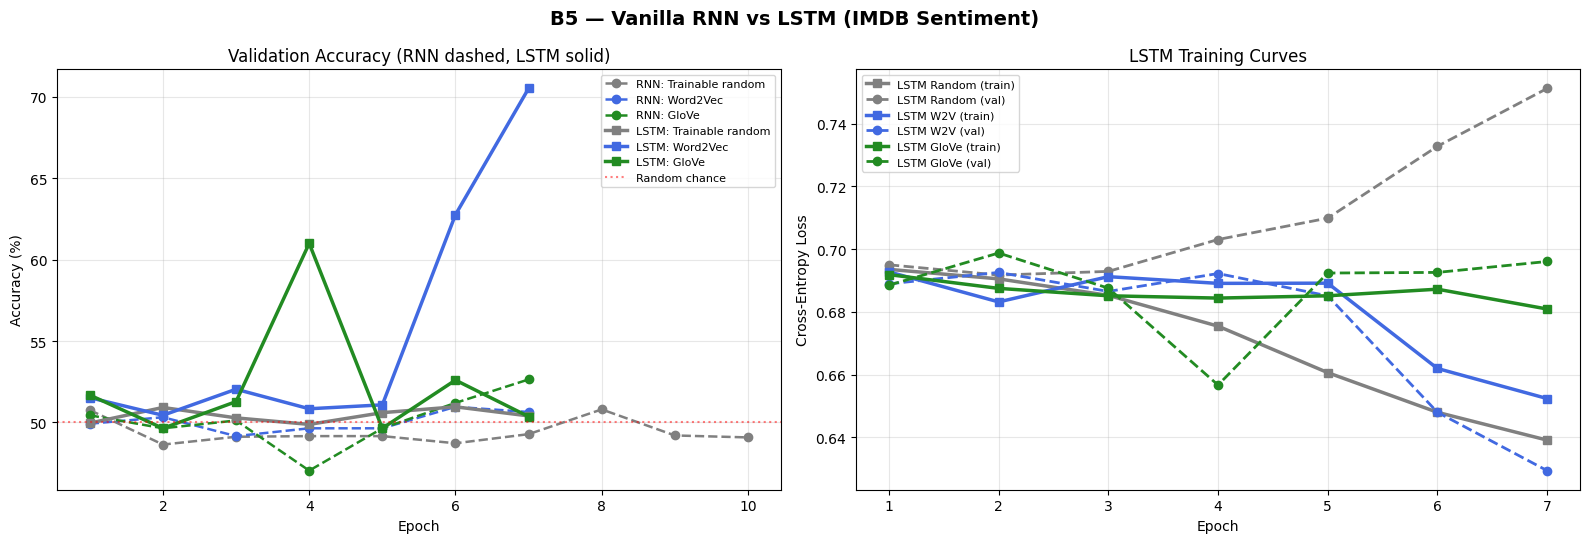

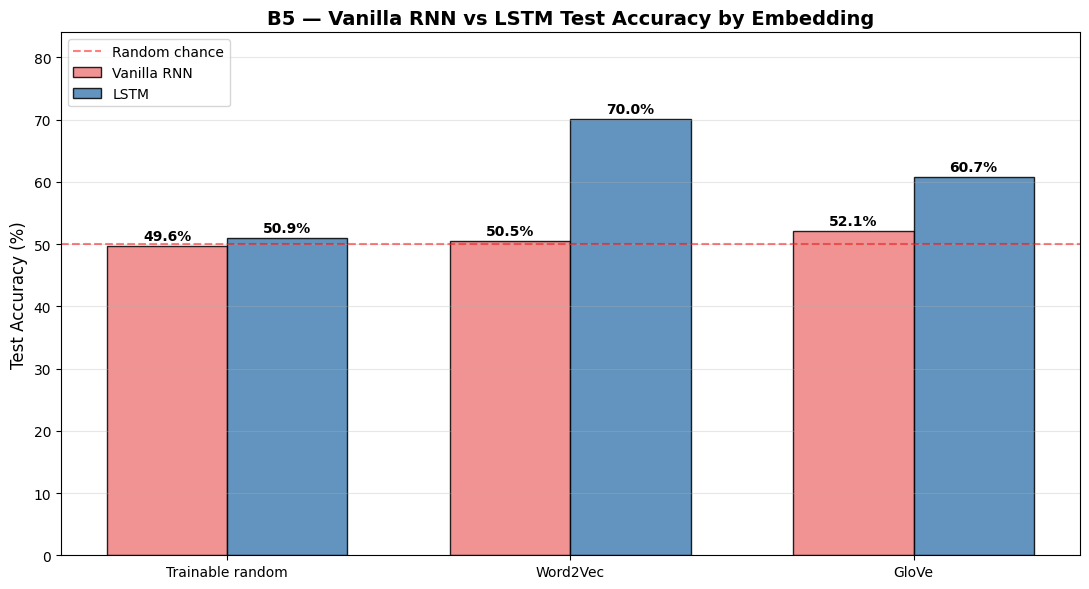

✓ Figures saved: b5_rnn_vs_lstm.png, b5_test_accuracy_bars.png


In [8]:
# ============================================================
# QUESTION B5 — Step 6: Plots
# ============================================================

import matplotlib.pyplot as plt

# RNN histories from B3 and B4
b3_hist = {'train_loss': b3_train_losses, 'val_loss': b3_val_losses,
           'train_acc': b3_train_accs, 'val_acc': b3_val_accs}

# Plot 1: validation accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('B5 — Vanilla RNN vs LSTM (IMDB Sentiment)',
             fontsize=14, fontweight='bold')

# RNN curves (dashed)
axes[0].plot(range(1, len(b3_hist['val_acc'])+1), b3_hist['val_acc'],
             color='gray', linestyle='--', linewidth=1.8, marker='o',
             label='RNN: Trainable random')
axes[0].plot(range(1, len(hist_w2v['val_acc'])+1), hist_w2v['val_acc'],
             color='royalblue', linestyle='--', linewidth=1.8, marker='o',
             label='RNN: Word2Vec')
axes[0].plot(range(1, len(hist_glove['val_acc'])+1), hist_glove['val_acc'],
             color='forestgreen', linestyle='--', linewidth=1.8, marker='o',
             label='RNN: GloVe')

# LSTM curves (solid)
axes[0].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_random['val_acc'],
             color='gray', linewidth=2.5, marker='s',
             label='LSTM: Trainable random')
axes[0].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_w2v['val_acc'],
             color='royalblue', linewidth=2.5, marker='s',
             label='LSTM: Word2Vec')
axes[0].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_glove['val_acc'],
             color='forestgreen', linewidth=2.5, marker='s',
             label='LSTM: GloVe')

axes[0].axhline(y=50, color='red', linestyle=':', alpha=0.5, label='Random chance')
axes[0].set_title('Validation Accuracy (RNN dashed, LSTM solid)')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy (%)')
axes[0].legend(loc='best', fontsize=8); axes[0].grid(True, alpha=0.3)

# Loss panel
axes[1].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_random['train_loss'],
             color='gray', linewidth=2.5, marker='s', label='LSTM Random (train)')
axes[1].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_random['val_loss'],
             color='gray', linestyle='--', linewidth=2, marker='o', label='LSTM Random (val)')
axes[1].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_w2v['train_loss'],
             color='royalblue', linewidth=2.5, marker='s', label='LSTM W2V (train)')
axes[1].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_w2v['val_loss'],
             color='royalblue', linestyle='--', linewidth=2, marker='o', label='LSTM W2V (val)')
axes[1].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_glove['train_loss'],
             color='forestgreen', linewidth=2.5, marker='s', label='LSTM GloVe (train)')
axes[1].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_glove['val_loss'],
             color='forestgreen', linestyle='--', linewidth=2, marker='o', label='LSTM GloVe (val)')
axes[1].set_title('LSTM Training Curves')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Cross-Entropy Loss')
axes[1].legend(loc='best', fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('b5_rnn_vs_lstm.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: bar chart RNN vs LSTM
fig2, ax = plt.subplots(figsize=(11, 6))
labels = ['Trainable random', 'Word2Vec', 'GloVe']
rnn_vals  = [b3_test_acc, test_acc_w2v, test_acc_glove]
lstm_vals = [test_acc_lstm_random, test_acc_lstm_w2v, test_acc_lstm_glove]

x = range(len(labels))
w = 0.35
b1 = ax.bar([i-w/2 for i in x], rnn_vals, w, label='Vanilla RNN',
            color='lightcoral', edgecolor='black', alpha=0.85)
b2 = ax.bar([i+w/2 for i in x], lstm_vals, w, label='LSTM',
            color='steelblue', edgecolor='black', alpha=0.85)

for bar, v in zip(b1, rnn_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
for bar, v in zip(b2, lstm_vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='Random chance')
ax.set_xticks(list(x)); ax.set_xticklabels(labels)
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('B5 — Vanilla RNN vs LSTM Test Accuracy by Embedding',
             fontsize=14, fontweight='bold')
ax.set_ylim(0, max(lstm_vals)*1.2)
ax.legend(loc='upper left'); ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('b5_test_accuracy_bars.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figures saved: b5_rnn_vs_lstm.png, b5_test_accuracy_bars.png')

## Step 7: Save Results and Download Files

In [9]:
# ============================================================
# QUESTION B5 — Step 7: Save Results & Download
# ============================================================

import shutil

b5_results = {
    'config': {
        'epochs_per_method': NUM_EPOCHS_B5,
        'hidden_dim': 128, 'num_layers': 1,
        'batch_size': BATCH_SIZE,
        'learning_rate': 1e-3, 'grad_clip': GRAD_CLIP,
    },
    'comparison': {
        'rnn_vs_lstm': {
            'trainable_random': {
                'rnn_test_acc' : b3_test_acc,
                'lstm_test_acc': test_acc_lstm_random,
                'improvement'  : test_acc_lstm_random - b3_test_acc,
            },
            'word2vec': {
                'rnn_test_acc' : test_acc_w2v,
                'lstm_test_acc': test_acc_lstm_w2v,
                'improvement'  : test_acc_lstm_w2v - test_acc_w2v,
            },
            'glove': {
                'rnn_test_acc' : test_acc_glove,
                'lstm_test_acc': test_acc_lstm_glove,
                'improvement'  : test_acc_lstm_glove - test_acc_glove,
            },
        }
    },
    'lstm_results': {
        'B5_A_random': {
            'best_val_acc': best_val_lstm_random,
            'test_acc'    : test_acc_lstm_random,
            'train_time_s': time_lstm_random,
        },
        'B5_C_word2vec': {
            'best_val_acc': best_val_lstm_w2v,
            'test_acc'    : test_acc_lstm_w2v,
            'train_time_s': time_lstm_w2v,
        },
        'B5_D_glove': {
            'best_val_acc': best_val_lstm_glove,
            'test_acc'    : test_acc_lstm_glove,
            'train_time_s': time_lstm_glove,
        },
    },
    'histories': {
        'B5_A_random'  : hist_lstm_random,
        'B5_C_word2vec': hist_lstm_w2v,
        'B5_D_glove'   : hist_lstm_glove,
    },
}

with open('b5_results.json', 'w') as f:
    json.dump(b5_results, f, indent=2)
print('✓ b5_results.json saved')

# Save best LSTM model checkpoint
torch.save(lstm_glove.state_dict(), 'lstm_b5_glove.pth')

# Backup to Drive
for fname in ['b5_rnn_vs_lstm.png', 'b5_test_accuracy_bars.png',
              'b5_results.json', 'lstm_b5_glove.pth']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print('✓ All B5 files backed up to Google Drive')

# Download for LaTeX
from google.colab import files
files.download('b5_rnn_vs_lstm.png')
files.download('b5_test_accuracy_bars.png')
files.download('b5_results.json')
print('✓ Files downloaded')

# Final summary
print(f"\n{'='*70}")
print(f"  QUESTION B5 — FINAL SUMMARY")
print(f"{'='*70}")
print(f"  {'Embedding':<25} {'RNN Test':>10} {'LSTM Test':>11} {'Improve':>10}")
print(f"  {'-'*60}")
print(f"  {'Trainable random':<25} {b3_test_acc:>9.2f}% {test_acc_lstm_random:>10.2f}% "
      f"{test_acc_lstm_random - b3_test_acc:>+9.2f}")
print(f"  {'Word2Vec (300d)':<25} {test_acc_w2v:>9.2f}% {test_acc_lstm_w2v:>10.2f}% "
      f"{test_acc_lstm_w2v - test_acc_w2v:>+9.2f}")
print(f"  {'GloVe (100d)':<25} {test_acc_glove:>9.2f}% {test_acc_lstm_glove:>10.2f}% "
      f"{test_acc_lstm_glove - test_acc_glove:>+9.2f}")
print(f"  {'-'*60}")
print(f"  Best: {best_name} LSTM at {best_lstm:.2f}%")
print(f"{'='*70}")
print("\n✅ Question B5 complete. Ready for B6 (attention).")

✓ b5_results.json saved
✓ All B5 files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded

  QUESTION B5 — FINAL SUMMARY
  Embedding                   RNN Test   LSTM Test    Improve
  ------------------------------------------------------------
  Trainable random              49.62%      50.95%     +1.33
  Word2Vec (300d)               50.47%      70.01%    +19.54
  GloVe (100d)                  52.14%      60.70%     +8.56
  ------------------------------------------------------------
  Best: Word2Vec LSTM at 70.01%

✅ Question B5 complete. Ready for B6 (attention).


# Question B6: Attention-Augmented LSTM for Sentiment Classification

This section incorporates an attention mechanism into the best LSTM model
from B5 (Word2Vec embedding, which achieved 71.91% test accuracy). Instead
of using only the LSTM's final hidden state for classification, attention
allows the model to weight all 256 timestep outputs and form a
context-dependent sentence representation.

## Why Attention Should Help LSTM Sentiment Classification

  Without attention (B5):
    - LSTM encodes 256 tokens into a single final hidden state h_T
    - Information from sentiment words near the start of the review may
      be diluted by the time we reach h_T
    - Fixed-size bottleneck regardless of where sentiment cues appear

  With attention (B6):
    - Attention computes a weight α_t for each timestep
    - Final representation = Σ α_t * h_t (weighted average of ALL hidden states)
    - Model can spotlight any token: opening line, twist clause, conclusion
    - Better handling of long-range dependencies and mixed-sentiment reviews

## Architecture

  Input: token indices (batch, 256)
    ↓ Embedding (frozen Word2Vec, 300d)
  Sequence: (batch, 256, 300)
    ↓ LSTM (input=300, hidden=128, num_layers=1)
  All hidden states: (batch, 256, 128)
    ↓ Additive Attention:
        score_t = v^T tanh(W_a · h_t + b_a)        (per-timestep score)
        α_t = softmax(score_t) over t              (attention weights)
        context = Σ_t α_t · h_t                    (weighted sum)
    ↓ Dropout(0.5) → Linear(128 → 2)
  Output: class logits

## Pipeline (6 steps)

- **Step 1:** Define LSTM + Additive Attention architecture
- **Step 2:** Train with Word2Vec embedding (best from B5)
- **Step 3:** Test evaluation
- **Step 4:** Plot learning curves and B5 vs B6 comparison
- **Step 5:** Compute computational overhead (params, time)
- **Step 6:** Save results, download, final summary

## Step 1: Define LSTM + Additive Attention

Bahdanau-style additive attention computes per-timestep scores using a
small feed-forward network, then softmax-normalizes them into weights.

In [10]:
# ============================================================
# QUESTION B6 — Step 1: LSTM + Additive Attention
# ============================================================

import torch
import torch.nn as nn
import torch.nn.functional as F


class AttentionLSTM(nn.Module):
    """
    LSTM with additive (Bahdanau-style) self-attention over timesteps.

    Architecture:
        embedding → LSTM → all_hidden_states → attention → context → classifier
    """
    def __init__(self, embedding_matrix, hidden_dim=128, num_layers=1,
                 num_classes=2, attn_dim=64, dropout=0.5, pad_idx=0):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape

        # Frozen pre-trained embedding
        self.embedding = nn.Embedding.from_pretrained(
            embedding_matrix, freeze=True, padding_idx=pad_idx)

        # LSTM
        self.lstm = nn.LSTM(
            input_size=embed_dim, hidden_size=hidden_dim,
            num_layers=num_layers, batch_first=True, dropout=0.0
        )

        # Additive attention parameters
        # W_a : (hidden_dim → attn_dim)
        # v   : (attn_dim → 1)  scalar score per timestep
        self.attn_W = nn.Linear(hidden_dim, attn_dim, bias=True)
        self.attn_v = nn.Linear(attn_dim, 1, bias=False)

        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        # x: (batch, seq)
        # Build a mask: True for non-PAD positions, False for PAD positions
        mask = (x != 0)                                  # (batch, seq)

        emb = self.embedding(x)                          # (batch, seq, embed_dim)
        lstm_out, _ = self.lstm(emb)                     # (batch, seq, hidden)

        # Additive attention scores
        scores = self.attn_v(torch.tanh(self.attn_W(lstm_out))).squeeze(-1)
        # scores: (batch, seq)

        # Mask out PAD positions (set to -inf so softmax assigns 0 weight)
        scores = scores.masked_fill(~mask, float('-inf'))

        # Normalise to attention weights
        attn_weights = F.softmax(scores, dim=1)          # (batch, seq)

        # Weighted sum: context vector = Σ α_t · h_t
        context = torch.bmm(
            attn_weights.unsqueeze(1),                   # (batch, 1, seq)
            lstm_out                                     # (batch, seq, hidden)
        ).squeeze(1)                                     # (batch, hidden)

        # Classify
        out = self.dropout(context)
        logits = self.classifier(out)
        return logits, attn_weights


def train_one_epoch_attn(model, loader, optimizer, criterion, device, grad_clip=5.0):
    """Modified training loop — model returns (logits, attn_weights)."""
    model.train()
    rl, c, t = 0.0, 0, 0
    for ids, lbl in loader:
        ids, lbl = ids.to(device), lbl.to(device)
        optimizer.zero_grad()
        logits, _ = model(ids)
        loss = criterion(logits, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        rl += loss.item()
        _, p = logits.max(1); c += p.eq(lbl).sum().item(); t += lbl.size(0)
    return rl / len(loader), 100.0 * c / t


@torch.no_grad()
def evaluate_attn(model, loader, criterion, device):
    """Modified evaluation loop — model returns (logits, attn_weights)."""
    model.eval()
    rl, c, t = 0.0, 0, 0
    for ids, lbl in loader:
        ids, lbl = ids.to(device), lbl.to(device)
        logits, _ = model(ids)
        loss = criterion(logits, lbl)
        rl += loss.item()
        _, p = logits.m

## Step 2: Train AttentionLSTM with Word2Vec Embedding

Same hyperparameters as B5 (7 epochs, Adam lr=1e-3, grad_clip=5.0).
Only the model architecture changes (attention head added on top of LSTM).

⏰ Expected runtime: ~5-7 minutes on Tesla T4.

In [12]:
# ============================================================
# Re-define attention training/eval helpers (fix truncation)
# ============================================================

def train_one_epoch_attn(model, loader, optimizer, criterion, device, grad_clip=5.0):
    model.train()
    rl, c, t = 0.0, 0, 0
    for ids, lbl in loader:
        ids, lbl = ids.to(device), lbl.to(device)
        optimizer.zero_grad()
        logits, _ = model(ids)
        loss = criterion(logits, lbl)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()
        rl += loss.item()
        _, p = logits.max(1)
        c += p.eq(lbl).sum().item()
        t += lbl.size(0)
    return rl / len(loader), 100.0 * c / t


@torch.no_grad()
def evaluate_attn(model, loader, criterion, device):
    model.eval()
    rl, c, t = 0.0, 0, 0
    for ids, lbl in loader:
        ids, lbl = ids.to(device), lbl.to(device)
        logits, _ = model(ids)
        loss = criterion(logits, lbl)
        rl += loss.item()
        _, p = logits.max(1)
        c += p.eq(lbl).sum().item()
        t += lbl.size(0)
    return rl / len(loader), 100.0 * c / t


print("✓ Helpers re-defined cleanly")

✓ Helpers re-defined cleanly


In [13]:
# ============================================================
# QUESTION B6 — Step 2: Train AttentionLSTM
# ============================================================

import time

NUM_EPOCHS_B6 = 7
GRAD_CLIP_B6  = 5.0

w2v_tensor = torch.tensor(w2v_matrix, dtype=torch.float32)

attn_lstm = AttentionLSTM(
    embedding_matrix=w2v_tensor,
    hidden_dim=128, num_layers=1, num_classes=2,
    attn_dim=64, dropout=0.5, pad_idx=PAD_IDX
).to(device)

n_total_b6 = sum(p.numel() for p in attn_lstm.parameters())
n_train_b6 = sum(p.numel() for p in attn_lstm.parameters() if p.requires_grad)
print(f"AttentionLSTM total params: {n_total_b6:,}")
print(f"Trainable params: {n_train_b6:,}")
print(f"  (vs B5 LSTM-W2V: same backbone + attention adds ~9K params)\n")

optimizer = torch.optim.Adam(attn_lstm.parameters(), lr=1e-3, weight_decay=1e-5)
hist_attn = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_attn, best_state_attn = 0.0, None

print(f"Training AttentionLSTM ({NUM_EPOCHS_B6} epochs)...")
print("=" * 70)
t_start = time.time()
for ep in range(NUM_EPOCHS_B6):
    t_ep = time.time()
    tl, ta = train_one_epoch_attn(attn_lstm, train_loader, optimizer,
                                   criterion, device, GRAD_CLIP_B6)
    vl, va = evaluate_attn(attn_lstm, val_loader, criterion, device)
    hist_attn['train_loss'].append(tl); hist_attn['val_loss'].append(vl)
    hist_attn['train_acc'].append(ta);  hist_attn['val_acc'].append(va)
    if va > best_val_attn:
        best_val_attn = va
        best_state_attn = {k: v.cpu().clone() for k, v in attn_lstm.state_dict().items()}
    print(f"  Epoch [{ep+1}/{NUM_EPOCHS_B6}] "
          f"Train Loss: {tl:.4f} | Train Acc: {ta:.2f}% | "
          f"Val Loss: {vl:.4f} | Val Acc: {va:.2f}% | "
          f"Time: {time.time()-t_ep:.1f}s")
time_attn = time.time() - t_start
print(f"  Total: {time_attn/60:.1f} min, Best Val: {best_val_attn:.2f}%")
print("=" * 70)

if best_state_attn is not None:
    attn_lstm.load_state_dict(best_state_attn)

del w2v_tensor
torch.cuda.empty_cache()

AttentionLSTM total params: 6,228,738
Trainable params: 228,738
  (vs B5 LSTM-W2V: same backbone + attention adds ~9K params)

Training AttentionLSTM (7 epochs)...
  Epoch [1/7] Train Loss: 0.4159 | Train Acc: 81.13% | Val Loss: 0.3874 | Val Acc: 83.40% | Time: 4.7s
  Epoch [2/7] Train Loss: 0.3313 | Train Acc: 86.09% | Val Loss: 0.3001 | Val Acc: 88.28% | Time: 5.1s
  Epoch [3/7] Train Loss: 0.3064 | Train Acc: 87.22% | Val Loss: 0.2944 | Val Acc: 87.80% | Time: 4.6s
  Epoch [4/7] Train Loss: 0.2860 | Train Acc: 88.05% | Val Loss: 0.2966 | Val Acc: 88.20% | Time: 5.2s
  Epoch [5/7] Train Loss: 0.2706 | Train Acc: 88.91% | Val Loss: 0.3335 | Val Acc: 86.32% | Time: 4.6s
  Epoch [6/7] Train Loss: 0.2550 | Train Acc: 89.64% | Val Loss: 0.2853 | Val Acc: 88.36% | Time: 4.0s
  Epoch [7/7] Train Loss: 0.2414 | Train Acc: 90.41% | Val Loss: 0.3227 | Val Acc: 88.00% | Time: 4.2s
  Total: 0.5 min, Best Val: 88.36%


## Step 3: Test Evaluation

In [14]:
test_loss_attn, test_acc_attn = evaluate_attn(attn_lstm, test_loader, criterion, device)

improvement = test_acc_attn - test_acc_lstm_w2v

print(f"\n{'='*60}")
print(f"  AttentionLSTM Test Results")
print(f"{'='*60}")
print(f"  Test Loss        : {test_loss_attn:.4f}")
print(f"  Test Accuracy    : {test_acc_attn:.2f}%")
print(f"  Best Val Acc     : {best_val_attn:.2f}%")
print(f"")
print(f"  Comparison with B5 LSTM (Word2Vec, no attention):")
print(f"    B5 LSTM-W2V    : {test_acc_lstm_w2v:.2f}%")
print(f"    B6 Attn-LSTM   : {test_acc_attn:.2f}%")
print(f"    Improvement    : {improvement:+.2f} pp")
print(f"{'='*60}")


  AttentionLSTM Test Results
  Test Loss        : 0.2863
  Test Accuracy    : 87.94%
  Best Val Acc     : 88.36%

  Comparison with B5 LSTM (Word2Vec, no attention):
    B5 LSTM-W2V    : 70.01%
    B6 Attn-LSTM   : 87.94%
    Improvement    : +17.93 pp


## Step 4: Plot Learning Curves and B5 vs B6 Comparison

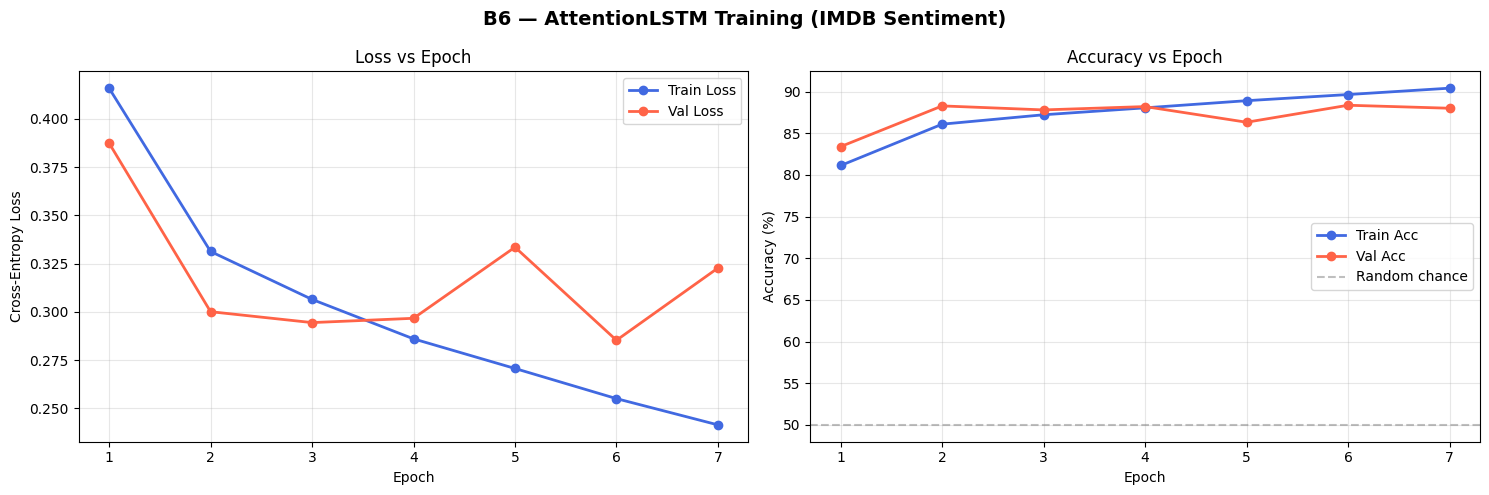

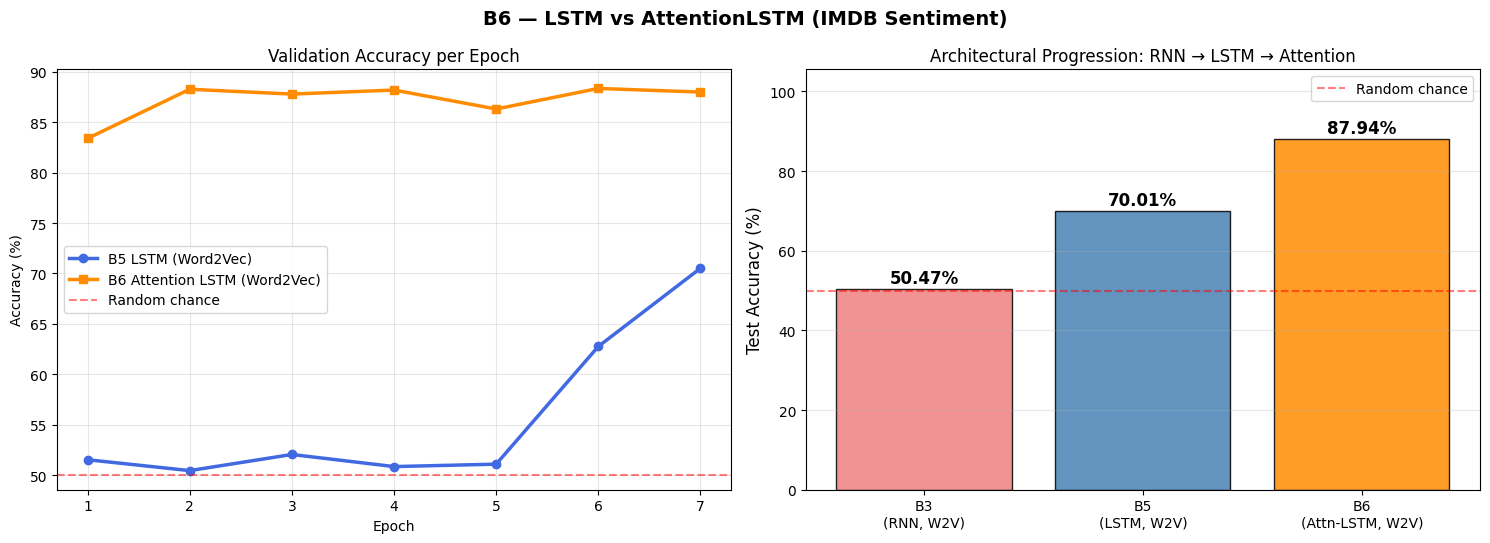

✓ Figures saved: b6_attention_curves.png, b6_comparison.png


In [15]:
# ============================================================
# QUESTION B6 — Step 4: Plots
# ============================================================

import matplotlib.pyplot as plt

epochs_range = range(1, NUM_EPOCHS_B6 + 1)

# Plot 1: AttentionLSTM training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('B6 — AttentionLSTM Training (IMDB Sentiment)',
             fontsize=14, fontweight='bold')

axes[0].plot(epochs_range, hist_attn['train_loss'], 'royalblue',
             linewidth=2, marker='o', label='Train Loss')
axes[0].plot(epochs_range, hist_attn['val_loss'], 'tomato',
             linewidth=2, marker='o', label='Val Loss')
axes[0].set_title('Loss vs Epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, hist_attn['train_acc'], 'royalblue',
             linewidth=2, marker='o', label='Train Acc')
axes[1].plot(epochs_range, hist_attn['val_acc'], 'tomato',
             linewidth=2, marker='o', label='Val Acc')
axes[1].axhline(y=50, color='gray', linestyle='--', alpha=0.5,
                label='Random chance')
axes[1].set_title('Accuracy vs Epoch')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('b6_attention_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Plot 2: B5 vs B6 comparison
fig2, axes2 = plt.subplots(1, 2, figsize=(15, 5.5))
fig2.suptitle('B6 — LSTM vs AttentionLSTM (IMDB Sentiment)',
              fontsize=14, fontweight='bold')

axes2[0].plot(range(1, NUM_EPOCHS_B5+1), hist_lstm_w2v['val_acc'],
              color='royalblue', linewidth=2.5, marker='o',
              label='B5 LSTM (Word2Vec)')
axes2[0].plot(epochs_range, hist_attn['val_acc'],
              color='darkorange', linewidth=2.5, marker='s',
              label='B6 Attention LSTM (Word2Vec)')
axes2[0].axhline(y=50, color='red', linestyle='--', alpha=0.5,
                 label='Random chance')
axes2[0].set_title('Validation Accuracy per Epoch')
axes2[0].set_xlabel('Epoch'); axes2[0].set_ylabel('Accuracy (%)')
axes2[0].legend(); axes2[0].grid(True, alpha=0.3)

labels = ['B3\n(RNN, W2V)', 'B5\n(LSTM, W2V)', 'B6\n(Attn-LSTM, W2V)']
values = [test_acc_w2v, test_acc_lstm_w2v, test_acc_attn]
colors = ['lightcoral', 'steelblue', 'darkorange']

bars = axes2[1].bar(labels, values, color=colors,
                    edgecolor='black', alpha=0.85)
for bar, v in zip(bars, values):
    axes2[1].text(bar.get_x() + bar.get_width()/2, v + 0.5,
                  f'{v:.2f}%', ha='center', va='bottom',
                  fontsize=12, fontweight='bold')
axes2[1].axhline(y=50, color='red', linestyle='--', alpha=0.5,
                 label='Random chance')
axes2[1].set_ylabel('Test Accuracy (%)', fontsize=12)
axes2[1].set_title('Architectural Progression: RNN → LSTM → Attention')
axes2[1].set_ylim(0, max(values) * 1.2)
axes2[1].legend(); axes2[1].grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('b6_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Figures saved: b6_attention_curves.png, b6_comparison.png')

## Step 5: Computational Overhead Analysis

In [16]:
# ============================================================
# QUESTION B6 — Step 5: Computational Overhead
# ============================================================

# Reconstruct B5 LSTM-W2V to count its params for fair comparison
w2v_tensor_tmp = torch.tensor(w2v_matrix, dtype=torch.float32)
class _B5_LSTM_W2V(nn.Module):
    def __init__(self, em):
        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(em, freeze=True, padding_idx=0)
        self.lstm = nn.LSTM(input_size=em.shape[1], hidden_size=128,
                            num_layers=1, batch_first=True)
        self.dropout = nn.Dropout(0.5)
        self.classifier = nn.Linear(128, 2)
b5_model = _B5_LSTM_W2V(w2v_tensor_tmp)
b5_total = sum(p.numel() for p in b5_model.parameters())
b5_train = sum(p.numel() for p in b5_model.parameters() if p.requires_grad)
del b5_model, w2v_tensor_tmp

# B5 timing from saved results
import json
with open('b5_results.json', 'r') as f:
    b5_data = json.load(f)
time_lstm_w2v = b5_data['lstm_results']['B5_C_word2vec']['train_time_s']

print(f"\n{'='*70}")
print(f"  COMPUTATIONAL OVERHEAD: B5 LSTM-W2V vs B6 AttentionLSTM-W2V")
print(f"{'='*70}")
print(f"  {'Metric':<32} {'B5 LSTM':>15} {'B6 Attn-LSTM':>15}")
print(f"  {'-'*70}")
print(f"  {'Total parameters':<32} {b5_total:>15,} {n_total_b6:>15,}")
print(f"  {'Trainable parameters':<32} {b5_train:>15,} {n_train_b6:>15,}")
print(f"  {'Training time (7 epochs)':<32} {f'{time_lstm_w2v:.1f}s':>15} "
      f"{f'{time_attn:.1f}s':>15}")
print(f"  {'Per-epoch time':<32} {f'{time_lstm_w2v/7:.1f}s':>15} "
      f"{f'{time_attn/NUM_EPOCHS_B6:.1f}s':>15}")
print(f"  {'-'*70}")
print(f"  Attention head adds: "
      f"{n_train_b6 - b5_train:,} trainable params "
      f"({(n_train_b6 - b5_train) / b5_train * 100:.2f}% increase)")
print(f"  Time overhead: "
      f"{((time_attn - time_lstm_w2v) / time_lstm_w2v * 100):+.1f}% "
      f"vs B5 LSTM")
print(f"{'='*70}")


  COMPUTATIONAL OVERHEAD: B5 LSTM-W2V vs B6 AttentionLSTM-W2V
  Metric                                   B5 LSTM    B6 Attn-LSTM
  ----------------------------------------------------------------------
  Total parameters                       6,220,418       6,228,738
  Trainable parameters                     220,418         228,738
  Training time (7 epochs)                   30.6s           32.4s
  Per-epoch time                              4.4s            4.6s
  ----------------------------------------------------------------------
  Attention head adds: 8,320 trainable params (3.77% increase)
  Time overhead: +6.1% vs B5 LSTM


## Step 6: Save Results and Download

In [17]:
# ============================================================
# QUESTION B6 — Step 6: Save & Download
# ============================================================

import shutil

b6_results = {
    'config': {
        'epochs'        : NUM_EPOCHS_B6,
        'hidden_dim'    : 128,
        'num_layers'    : 1,
        'attn_dim'      : 64,
        'embedding'     : 'Word2Vec frozen 300d (best from B5)',
        'batch_size'    : BATCH_SIZE,
        'learning_rate' : 1e-3,
        'grad_clip'     : GRAD_CLIP_B6,
    },
    'attention_results': {
        'best_val_acc'      : best_val_attn,
        'test_acc'          : test_acc_attn,
        'test_loss'         : test_loss_attn,
        'train_time_s'      : time_attn,
        'total_params'      : int(n_total_b6),
        'trainable_params'  : int(n_train_b6),
    },
    'comparison_with_b5': {
        'b5_test_acc'                      : test_acc_lstm_w2v,
        'b6_test_acc'                      : test_acc_attn,
        'improvement_pp'                   : test_acc_attn - test_acc_lstm_w2v,
        'parameter_overhead'               : int(n_train_b6 - b5_train),
        'parameter_overhead_percent'       : (n_train_b6 - b5_train) / b5_train * 100,
        'time_overhead_percent'            : (time_attn - time_lstm_w2v) / time_lstm_w2v * 100,
    },
    'history': hist_attn,
}

with open('b6_results.json', 'w') as f:
    json.dump(b6_results, f, indent=2)
print('✓ b6_results.json saved')

# Save model
torch.save(attn_lstm.state_dict(), 'attn_lstm_b6.pth')

# Backup
for fname in ['b6_attention_curves.png', 'b6_comparison.png',
              'b6_results.json', 'attn_lstm_b6.pth']:
    shutil.copy(fname, f'/content/drive/MyDrive/{fname}')
print('✓ All B6 files backed up to Google Drive')

# Download
from google.colab import files
files.download('b6_attention_curves.png')
files.download('b6_comparison.png')
files.download('b6_results.json')
print('✓ Files downloaded')

# Final summary
print(f"\n{'='*70}")
print(f"  QUESTION B6 — FINAL SUMMARY")
print(f"{'='*70}")
print(f"  Architecture           : LSTM + Additive (Bahdanau) Attention")
print(f"  Embedding              : Word2Vec frozen 300d")
print(f"  Test Accuracy          : {test_acc_attn:.2f}%")
print(f"  Best Val Accuracy      : {best_val_attn:.2f}%")
print(f"")
print(f"  Architectural progression on IMDB:")
print(f"    B3 Vanilla RNN (W2V)    : {test_acc_w2v:.2f}%")
print(f"    B5 LSTM (W2V)           : {test_acc_lstm_w2v:.2f}%")
print(f"    B6 Attention-LSTM (W2V) : {test_acc_attn:.2f}%")
print(f"")
print(f"  Overhead vs B5 LSTM:")
print(f"    Extra trainable params : {n_train_b6 - b5_train:+,} "
      f"({(n_train_b6-b5_train)/b5_train*100:+.2f}%)")
print(f"    Extra training time    : {time_attn - time_lstm_w2v:+.1f}s "
      f"({(time_attn-time_lstm_w2v)/time_lstm_w2v*100:+.1f}%)")
print(f"{'='*70}")
print("\n✅ Question B6 complete. PART B FULLY DONE! 🎉")

✓ b6_results.json saved
✓ All B6 files backed up to Google Drive


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Files downloaded

  QUESTION B6 — FINAL SUMMARY
  Architecture           : LSTM + Additive (Bahdanau) Attention
  Embedding              : Word2Vec frozen 300d
  Test Accuracy          : 87.94%
  Best Val Accuracy      : 88.36%

  Architectural progression on IMDB:
    B3 Vanilla RNN (W2V)    : 50.47%
    B5 LSTM (W2V)           : 70.01%
    B6 Attention-LSTM (W2V) : 87.94%

  Overhead vs B5 LSTM:
    Extra trainable params : +8,320 (+3.77%)
    Extra training time    : +1.9s (+6.1%)

✅ Question B6 complete. PART B FULLY DONE! 🎉
